(mmm_funnel_mueffect_advanced)=
# Advanced Funnel-Aware MMM: Geo-Level Mediation Through Lower-Funnel Spend

The {ref}`mmm_funnel_mueffect` notebook introduced the core idea: upper-funnel
activity creates demand that shows up later in lower-funnel channels, and we can
encode that mediation directly in `pymc-marketing` through a custom
{class}`~pymc_marketing.mmm.additive_effect.MuEffect` carrying its own likelihood.
That example kept the funnel deliberately minimal -- one upper channel, one
mediator, one national time series.

Real engagements are not that tidy. This notebook scales the same idea up to a
setup that looks much more like production work:

1. **Several upper-funnel channels** feed the same latent demand pool, each with
   its own carryover and saturation.
2. **A geo panel**: the model is fit across regions at once, with some parameters
   pooled across geos and others estimated per geo.
3. **A mediator that is itself media.** Lower-funnel spend is not a passive
   symptom of demand -- it is paid search, and it converts. It sits *on* the causal
   path, driven partly by the demand that upper-funnel activity creates and partly
   by an exogenous budget of its own.
4. **A second, purely observational proxy.** Branded search volume measures the
   same latent demand but causes nothing. Keeping a *cause* and an *indicator*
   distinct is most of the modeling problem.
5. **Confounded media plans**: category demand and the media plans share an
   annual seasonal cycle, a growth trend -- for one channel -- and a small
   amount of correlated noise. The seasonal leg is absorbed by every model's
   Fourier basis; the trend leg is just as observable but carried by none of
   the standard specifications; the noise leg is observable by nobody. That
   split, and what fixing each part does and does not buy, is what the causal
   analysis below is organised around.

Along the way we use two pieces of the library that make this much less painful
than hand-rolling everything:

- {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which reads the
  effect's data straight out of the training `xarray` dataset, so we only write
  the part of the effect that is genuinely custom.
- `pymc.dims` **xtensors**, whose named broadcasting lets a `("geo",)` parameter,
  a `("channel",)` parameter and a `("date", "geo", "channel")` data array combine
  without a single `reshape` or `None`-index.

And before fitting anything, we interrogate the causal graph itself with
`networkx`'s d-separation tools: for every model specification we *compute* --
rather than assert -- whether it identifies the effect it claims to, using the
backdoor criterion. The empirical comparisons are then read against those
verdicts, which is the right order to do causal work in -- including at the one
point where the graph's ranking of two specifications and the data disagree,
which is the sort of thing only doing both can show you.

```{note}
This is a self-contained methodological example built on fully synthetic data. It
does not reference any specific client or engagement.
```

## The funnel structure

We model a weekly geo panel. Within every geo $g$ and week $t$:

- `tv_spend`, `social_spend` ($U_{t,g,c}$): two **upper-funnel** channels.
- `category_demand` ($C_{t,g}$): an exogenous, seasonal index of how much the
  whole category is in-market (think a category-level search-trend index). It
  drives lower-funnel demand but does **not** act on the target directly -- an
  **exclusion restriction** on the mediator equation.
- `lf_budget` ($B_{t,g}$): an exogenous lower-funnel budget -- always-on spend plus
  promotional pushes, set by the search team on its own calendar rather than in
  response to demand.
- $D_{t,g}$: **latent demand**. Never observed.
- $M^{*}_{t,g}$: **structural lower-funnel spend**, the quantity that actually buys
  conversions. `lower_spend` is this observed with reporting noise.
- `search_volume` ($S_{t,g}$): branded search volume, an **indicator** of $D$.
- `y` ($Y_{t,g}$): the target.

Upper-funnel activity and the category cycle create demand:

$$
D_{t,g} = \text{baseline}_g + \gamma_g\, C_{t,g}
          + \sum_{c} \text{sat}^{uf}\!\left(\text{adstock}^{uf}(U_{t,g,c})\right).
$$

That demand is one of two things the search team's spend responds to; the other is
its own budget. Both parts are real money and both convert:

$$
M^{*}_{t,g} = D_{t,g} + \lambda_g B_{t,g},
\qquad
\texttt{lower\_spend}_{t,g} \sim
  \text{TruncatedNormal}(M^{*}_{t,g},\, \sigma^M_g,\, \text{lower}=0).
$$

Branded search, by contrast, buys nothing. It is a **pure indicator** -- people
search for the brand *because* they are in-market:

$$
S_{t,g} \sim \text{Normal}(\kappa\, D_{t,g},\, \sigma^S_g).
$$

Finally the target responds to lower-funnel spend, plus the direct effect of each
upper channel and its own seasonality:

$$
Y_{t,g} = \text{intercept}_g
        + \sum_c \text{sat}\!\left(\text{adstock}(U_{t,g,c})\right)
        + \text{Fourier}(t)\cdot\gamma^{F}_g
        + \text{sat}^{lf}\!\left(\text{adstock}^{lf}(M^{*}_{t,g})\right)
        + \varepsilon_{t,g}.
$$

Every upper channel therefore reaches the target along **two paths**: directly, and
indirectly along $U \to D \to M^{*} \to Y$.

### Why only one of the two downstream variables points at the target

This asymmetry is the heart of the example, so it is worth stating bluntly.

**Lower-funnel spend belongs in the target equation.** It is paid media. Money goes
in, conversions come out, and a model that leaves it out is missing a real driver.
What makes it a *mediator* rather than an ordinary channel is that its level is not
chosen freely: part of it is a response to demand that upper-funnel activity
created. Credit for that part belongs upstream.

**Branded search volume does not.** Nobody buys search volume; it is a symptom of
being in-market. Drawing $S \to Y$ would invent a causal channel that does not
exist, and -- as `Naive C` below demonstrates -- putting it into an MMM as if it
were a channel silently blocks the very path we are trying to measure.

The practical test is not "is this variable predictive of sales?" Both are, very.
It is "if I doubled it, would sales move?" That question separates a spend line
from a tracking metric, and no amount of model fit will answer it for you.

```{note}
**What anchors the latent scale.** $D$ is latent, so something has to fix its
units. Here it is the coefficient on $D$ in the $M^{*}$ equation, which is pinned
at exactly one: latent demand is measured *in units of the lower-funnel spend it
induces*. Everything else is then relative to that -- $\kappa$ is free, and
$\lambda$ converts budget into the same units. Were that coefficient free too,
rescaling $D$ and compensating in $\kappa$ would leave the likelihood untouched.
```

Two further structural features make this harder than the single-channel case.

**Confounded media plans.** Media plans and category demand are built around the
same market rhythm, so upper-funnel spend and category demand move together. That
common cause has three parts with very different statuses *relative to the
models below*, and only two of the three are observable at all. The purely
**seasonal** part is a deterministic function of the calendar,
and every model below includes the matching Fourier basis -- so that leg of the
confounding is adjusted for by construction, however large it looks in a
correlation table. But the TV plan and the category index also share a strong
common **growth trend** -- observable from the calendar just as the season is,
yet outside the span of a smooth annual basis, so a Fourier term cannot absorb
it. Only the models that *deliberately* control for it (below, `Naive B+`
through the category index and `Naive B++` through the trend itself) touch that
leg. The third part is the drivers' shared **noise**, which no regressor spans
and no control column can reach; it is small here, but small is a measurement,
not an assumption, and the d-separation verdicts turn out to depend on it. We
will measure how much confounding each leg is actually worth before fitting
anything -- and then watch the models separate what adjustment can repair from
what it cannot: the trend-driven part of category demand is removable by
adjustment, while the demand each channel creates downstream is not, and which curve collects what is
decided by the likelihood's fit, not by anything a correlation table can tell
you in advance.

**A shared, saturating demand pool.** Because both channels push on the *same*
saturating function, their indirect effects are not additive. Turning off TV alone
and turning off social alone remove *less* demand between them than turning off
both at once -- each channel is partly shielded by the other's contribution
sitting further along the concave curve. We quantify this below.

Identification rests on **two exclusion restrictions** -- two arrows deliberately
missing from the graph -- and they are not equally load-bearing:

- The lower-funnel budget $B$ enters the spend equation but not the search
  equation. This one is **genuinely identifying**: it is what lets the model tell
  $\lambda B$ apart from $D$ rather than lumping the two into one unidentified
  level. Nothing else in the model can substitute for it.
- Category demand $C$ enters the demand equation but not the target. This one is
  a **modelling convenience** rather than a necessity: $C$ is *observed*, so a
  direct $C \to Y$ path could simply be absorbed by adding $C$ as a control
  column. Keeping the target equation clean makes the example sharper, but no
  identification would be lost by relaxing it -- a fact `Naive B+` below exploits.

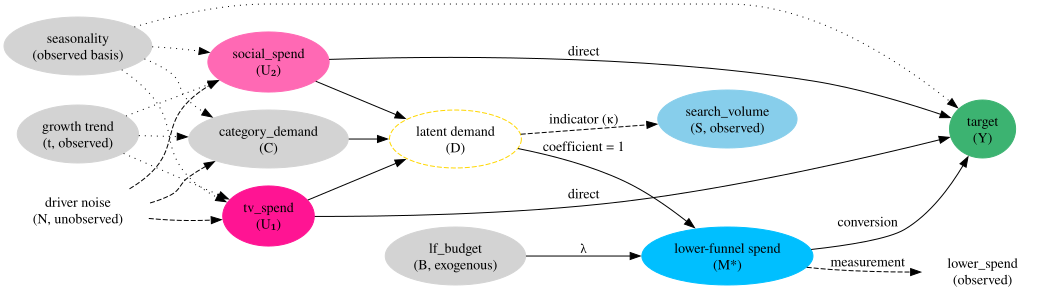

In [1]:
import graphviz as gr

# One specification drives both the picture below and the formal analysis later:
# the graphviz figure and the networkx graph are built from the same edge list, so
# the two cannot drift apart.
#
# `N` is not a device invented for the picture. The covariate draw below gives the
# two plans and the category index a *shared* error term (`pm.LKJCholeskyCov`),
# which in graph terms is exactly an unobserved common cause of all three. It is
# small -- we measure it once the covariates exist -- but drawing it changes the
# d-separation verdicts, so it belongs on the graph.
DAG_NODES = {
    "season": (
        "seasonality\n(observed basis)",
        {"color": "lightgray", "style": "filled"},
    ),
    "t": (
        "growth trend\n(t, observed)",
        {"color": "lightgray", "style": "filled"},
    ),
    "N": (
        "driver noise\n(N, unobserved)",
        {"color": "white", "style": "dashed"},
    ),
    "U1": ("tv_spend\n(U₁)", {"color": "deeppink", "style": "filled"}),
    "U2": ("social_spend\n(U₂)", {"color": "hotpink", "style": "filled"}),
    "C": ("category_demand\n(C)", {"color": "lightgray", "style": "filled"}),
    "B": ("lf_budget\n(B, exogenous)", {"color": "lightgray", "style": "filled"}),
    "D": ("latent demand\n(D)", {"color": "gold", "style": "dashed"}),
    "MS": ("lower-funnel spend\n(M*)", {"color": "deepskyblue", "style": "filled"}),
    "M": ("lower_spend\n(observed)", {"color": "white", "style": "dashed"}),
    "S": ("search_volume\n(S, observed)", {"color": "skyblue", "style": "filled"}),
    "Y": ("target\n(Y)", {"color": "mediumseagreen", "style": "filled"}),
}
DAG_EDGES = [
    ("season", "U1", {"style": "dotted"}),
    ("season", "U2", {"style": "dotted"}),
    ("season", "C", {"style": "dotted"}),
    ("season", "Y", {"style": "dotted"}),
    ("t", "U1", {"style": "dotted"}),
    ("t", "U2", {"style": "dotted"}),
    ("t", "C", {"style": "dotted"}),
    ("N", "U1", {"style": "dashed"}),
    ("N", "U2", {"style": "dashed"}),
    ("N", "C", {"style": "dashed"}),
    ("U1", "Y", {"label": "direct"}),
    ("U2", "Y", {"label": "direct"}),
    ("U1", "D", {}),
    ("U2", "D", {}),
    ("C", "D", {}),
    ("D", "MS", {"label": "coefficient = 1"}),
    ("B", "MS", {"label": "λ"}),
    ("MS", "M", {"label": "measurement", "style": "dashed"}),
    ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
    ("MS", "Y", {"label": "conversion"}),
]

g = gr.Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="ellipse")
for node, (label, attrs) in DAG_NODES.items():
    g.node(node, label, **attrs)
for parent, child, attrs in DAG_EDGES:
    g.edge(parent, child, **attrs)

g

The market driver appears **three** times, on purpose, and only two of the three
are observed. `seasonality` is the annual cycle, a deterministic function of the
calendar that every model below matches with a Fourier basis. `t` is the common
**growth trend** in the plans and the category index -- equally deterministic,
equally observable, but outside the span of an annual basis, so the shared
Fourier term cannot stand in for it. `N` is the drivers' shared **noise**, the
one leg that is genuinely unobserved -- small, but not zero, and measured
explicitly once the covariates are drawn.

Splitting the driver up is not cosmetic. The three legs have completely
different statuses in the models below: the season is conditioned on by *every*
specification by construction, the trend is carried only by the two models that
add a control for it on purpose, and $N$ can never be conditioned on by
anything. Conflating them under a single "seasonality" bubble is precisely how
the confounding in `Naive B` stays invisible -- and, as the d-separation table
will show, dropping $N$ from the picture is how a specification gets certified
that should only have been certified *conditionally*. A confounder does not have
to be unobservable to bite; it only has to be missing from the regression.

The whole graph is replicated across geos. Which parameters are shared and which
are free per geo is a modeling choice, and with roughly 130 weeks per geo it is a
consequential one:

| Parameter | Dimensions | Why |
|---|---|---|
| `adstock_alpha`, `adstock_uf_alpha`, `saturation_lam`, `sat_uf_lam` | `("channel",)` | Carryover and curvature are properties of the medium, not the region; pooling them buys a lot of precision. |
| `saturation_beta`, `sat_uf_beta` | `("geo", "channel")` | Response *amplitude* genuinely differs by region (market size, competition). |
| `intercept`, `funnel_baseline`, `funnel_gamma`, `funnel_lambda`, the noise scales | `("geo",)` | Regional levels and volatility; how strongly budget converts into spend is a regional operating choice. |
| `adstock_lf_alpha`, `sat_lf_beta` | `("geo",)` | The conversion path from lower-funnel spend to the target: how fast paid-search clicks convert and how hard they saturate is a property of each regional market. |
| `sat_lf_lam` | scalar | There is only **one** mediator, so unlike `sat_uf_lam` there is no channel axis to vary over; with a single series per geo we pool the curvature and let the per-geo amplitude carry the regional differences. |
| `funnel_kappa` | scalar | The search index is the same instrument everywhere, so its loading is shared. |

Mixing pooled and unpooled parameters in one expression is where xtensors earn
their keep: `pymc.dims` aligns operands **by dimension name**, so a
`("channel",)` decay multiplies a `("date", "geo", "channel")` media array with no
manual broadcasting.

## Prepare Notebook

In [2]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "advanced funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

# Every stochastic *fit-side* call gets its own named integer seed, drawn once
# before anything else consumes `rng`. Re-running a fit, posterior-predictive or
# counterfactual cell out of order then reproduces its numbers exactly -- which
# matters in a notebook whose prose quotes them. The *data-generation* cells still
# consume shared `rng` state directly, so those remain order-dependent.
SEED: dict[str, int] = dict(
    zip(
        [
            "covariates",
            "generative",
            "cf_gen_tv",
            "cf_gen_social",
            "cf_gen_both",
            "fit_naive_a",
            "pp_naive_a",
            "fit_naive_b",
            "pp_naive_b",
            "fit_naive_bplus",
            "pp_naive_bplus",
            "fit_naive_c",
            "pp_naive_c",
            "fit_funnel",
            "pp_funnel",
            "cf_post_tv_spend",
            "cf_post_social_spend",
        ],
        rng.integers(0, 2**31, size=17).tolist(),
        strict=True,
    )
)

# Seeds added after the original seventeen come from a separately-seeded
# stream: widening the `size=17` draw above would shift the shared `rng` state
# and silently regenerate every simulated series below.
_rng_extra = np.random.default_rng([seed, 1])
for _name in ["fit_naive_bpp", "pp_naive_bpp", "yearly_incrementality"]:
    SEED[_name] = int(_rng_extra.integers(0, 2**31))


def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")


FOREST_COLORS = ["C2", "C4", "C5", "C6", "C8", "C3", "C0", "C1"]


def forest_panel(ax, rows, reference=None, benchmarks=None, annotate=True):
    """Draw one mean-and-HDI interval per row, with optional reference lines.

    ``rows`` maps a label to a posterior ``DataArray``. ``reference`` maps a
    benchmark name to ``(value, style)`` and is drawn as a full-height vertical
    line. ``benchmarks`` maps a row label to the benchmark its bias annotation is
    measured against (default: the first ``reference`` entry); the annotation
    names its benchmark so the same figure can mix estimands without ambiguity.
    """
    labels = list(rows)
    benchmarks = benchmarks or {}
    for i, label in enumerate(labels):
        draws = rows[label]
        lo, hi = hdi_bounds(draws)
        mean = float(draws.mean())
        color = FOREST_COLORS[i % len(FOREST_COLORS)]
        ax.plot([float(lo), float(hi)], [i, i], color=color, lw=3.5, alpha=0.65)
        ax.plot([mean], [i], "o", color=color, ms=9)
        if annotate and reference:
            key = benchmarks.get(label, next(iter(reference)))
            benchmark = reference[key][0]
            ax.annotate(
                f"{mean / benchmark - 1:+.0%} vs {key}",
                (mean, i),
                textcoords="offset points",
                xytext=(0, -15),
                ha="center",
                va="top",
                fontsize=8,
                bbox={
                    "boxstyle": "round,pad=0.15",
                    "fc": "white",
                    "ec": "none",
                    "alpha": 0.75,
                },
            )
    for name, (value, style) in (reference or {}).items():
        ax.axvline(value, label=f"true {name}", **style)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_ylim(-0.7, len(labels) - 0.3)
    ax.invert_yaxis()


TRUE_STYLE = {
    "total": {"color": "black", "linestyle": "--", "linewidth": 2},
    "direct": {"color": "gray", "linestyle": ":", "linewidth": 2},
}

## Configuration

In [4]:
n_dates = 130
l_max = 8
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range, "geo": geos}

## The `FunnelEffect` component

A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` adds an arbitrary term to
the target mean through a three-method protocol: `create_data` registers the data
the effect needs, `create_effect` builds and returns the term, and `set_data`
refreshes the data at prediction time. Because `create_effect` runs *inside* the
model context, it can declare **its own observed likelihoods** -- which is what
turns "add a term to `mu`" into "fit extra structural equations jointly".

{class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect` removes most of that
boilerplate. It takes a list of `data_vars` naming variables in the training
dataset and implements `create_data` and `set_data` for us, registering each one
with the dimensions it already carries in the dataset. Compared with the
hand-written effect in {ref}`mmm_funnel_mueffect`, this deletes the data-carrying
fields, `create_data`, and `set_data` -- and it fixes a subtle limitation of the
hand-rolled version, whose `set_data` ignored the prediction frame entirely.

The `MediaTransformation` helper does the same for the adstock/saturation pairs:
instead of four loose components, we hold two transformation objects and let each
manage its own ordering and prior dimensions.

What remains in `create_effect` is exactly the part that *is* the funnel:

In [5]:
class FunnelEffect(DataVarMuEffect):
    """Geo-level upper-funnel mediation through lower-funnel spend.

    Encodes ``upper channels -> latent demand -> lower-funnel spend -> target`` as
    an additive effect on the target mean, while jointly fitting the observed
    lower-funnel spend and an indicator of the latent demand.
    """

    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect (transformations delegate to their own dicts)."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def create_effect(self, mmm):
        """Build the mediator equation, its likelihoods, and the target effect."""
        model = mmm.model

        # ("date", "geo", "channel") -> ("date", "geo"): every upper channel
        # pushes on the same demand pool, so we sum the channel dimension away.
        upper_on_demand = self.upper_transform(mmm.channel_data_scaled, dim="date").sum(
            dim="channel"
        )

        # Structural equation 1: upper spend + category demand -> latent demand.
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0, dims=("geo",))
        demand = pmd.Deterministic(
            f"{self.prefix}_demand",
            baseline + gamma * model["category_demand"] + upper_on_demand,
        )

        # Structural equation 2: lower-funnel spend responds to demand (coefficient
        # fixed at 1, which anchors D's scale) and to its own exogenous budget.
        lam_b = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5, dims=("geo",))
        lf_spend = pmd.Deterministic(
            f"{self.prefix}_lf_spend",
            demand + lam_b * model["lf_budget"],
        )

        # Observation: reported lower-funnel spend, up to reporting noise.
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_spend_likelihood",
            mu=lf_spend,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_m", sigma=1.0, dims=("geo",)),
            lower=0.0,
            observed=model["lower_spend"],
        )

        # Indicator: branded search volume loads on demand, not on spend.
        kappa = pmd.HalfNormal(f"{self.prefix}_kappa", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_search_likelihood",
            mu=kappa * demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=1.0, dims=("geo",)),
            observed=model["search_volume"],
        )

        # Structural equation 3: lower-funnel spend -> target contribution.
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(lf_spend, dim="date"),
        )

The factory below wires up the two transformations and, crucially, sets the
**dimensions of each prior** according to the pooling table above. `GeometricAdstock`
and `LogisticSaturation` accept a `priors` dictionary, so `alpha` and `lam` get
`dims="channel"` (pooled across geos) while `beta` gets `dims=("geo", "channel")`.
Unique `prefix` values keep these parameters from colliding with the base `MMM`'s
own direct-path transforms.

In [6]:
def make_funnel_effect() -> FunnelEffect:
    """Construct the funnel effect with uniquely-prefixed transformations."""
    return FunnelEffect(
        data_vars=["lower_spend", "search_volume", "category_demand", "lf_budget"],
        prefix="funnel",
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_uf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims="channel"),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
                },
            ),
            adstock_first=True,
            dims=("geo", "channel"),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_lf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="geo")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0, dims="geo"),
                },
            ),
            adstock_first=True,
            dims=("geo",),
        ),
    )

### A note on data plumbing

`DataVarMuEffect` looks its variables up in `mmm.xarray_dataset`, the dataset the
`MMM` stores when the model is built. That has a practical consequence worth
stating plainly, because it is easy to trip over:

> **A `pandas.DataFrame` will silently drop your funnel columns.** When `X` is a
> DataFrame, the conversion keeps only the channel and control columns; anything
> else disappears. To make extra variables visible to the effect, build the model
> from an `xarray.Dataset`, where every data variable survives.

There is a second wrinkle. `MMM.fit` records a `fit_data` group by converting `X`
back to a flat frame, and that bookkeeping step does not currently handle a
`Dataset` whose media variable carries a `channel` dimension. So we **build** with
the `Dataset` (which is what populates the model) and **fit** with the equivalent
long DataFrame (which is only used for bookkeeping, since `fit` does not rebuild
an already-built model). The model itself is entirely determined by the `Dataset`.

## Data generating process

As in {ref}`mmm_data_generator`, we build a model, clamp every parameter to a
known value with the
[`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html)
operator, and forward-sample. The generative model **is** the funnel MMM, so one
forward pass produces the target and both demand proxies at once.

### Exogenous covariates

Three of the drivers -- two media plans and the category demand index -- share a
common annual seasonal component, and two of them share a strong growth trend.
The **amplitudes and trends encode the story**: the TV plan is built around the
category cycle (amplitude 0.80, against category demand's 0.70) *and* rides the
same growth trend the category does (1.20, against the category's 1.00) -- a
growth-stage category whose flagship channel scales up with it. Social runs a
much milder cycle (0.40) and is nearly flat in trend (0.15): it co-moves with
category demand on the seasonal axis only. So the two channels are confounded
with demand through *different* legs of the shared driver, by construction
rather than by the luck of a draw.

The noise around those shared means is drawn from an LKJ prior with `eta=50` and
scales concentrated around 0.3. The concentration keeps the noise close to
*independent* across drivers, which is what pins the **raw** plan/demand
correlations -- and TV's trend-driven residual correlation with them -- to the
deterministic means rather than to the draw. It does not pin everything: at
`eta=50` and $d = 3$ the LKJ marginal correlation sd is
$1/\sqrt{2\eta + 2} \approx 0.10$, so any *residual* correlation of that order
is a lottery across seeds. We measure the realized draw below rather than assume
it away, because two paragraphs of the causal analysis turn on how big it is. A
`softplus` keeps everything non-negative. Regions are then scaled by a size
multiplier.

In [7]:
t = np.arange(n_dates) / n_dates
week_of_year = date_range.isocalendar().week.to_numpy() / 52.0
season = np.sin(2 * np.pi * week_of_year)

drivers = ["tv_spend", "social_spend", "category_demand"]
geo_size = np.array([1.0, 0.7, 0.45])

level = np.array([0.10, 0.05, 0.30])
trend = np.array([1.20, 0.15, 1.00])
seasonal_amplitude = np.array([0.80, 0.40, 0.70])

cov_coords = {"date": date_range, "geo": geos, "driver": drivers}
with pm.Model(coords=cov_coords) as covariates_model:
    L, _, _ = pm.LKJCholeskyCov(
        "L", n=3, eta=50, sd_dist=pm.Gamma.dist(mu=0.30, sigma=0.05)
    )
    mu_cov = (
        level + trend * t[:, None, None] + seasonal_amplitude * season[:, None, None]
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "geo", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "geo", "driver"))

In [8]:
x_data = (
    pm.draw(covariates_model.x, draws=1, random_seed=SEED["covariates"])
    * geo_size[None, :, None]
)

media_raw = x_data[..., :2]
category_demand = x_data[..., 2] / x_data[..., 2].max()

The lower-funnel budget is generated differently on purpose. It is **not**
seasonal and it does not follow the media plans: a low always-on level with
occasional promotional pushes on the search team's own calendar. That shape is
what makes it useful -- the pushes are exogenous shocks to lower-funnel spend, and
they are what let the model separate the budget-driven part of that spend from the
demand-driven part.

In [9]:
promo = rng.binomial(n=1, p=0.35, size=(n_dates, len(geos)))
magnitude = rng.gamma(shape=2.0, scale=0.30, size=(n_dates, len(geos)))
lf_budget = geo_size[None, :] * (0.12 + promo * magnitude)

for gi, geo in enumerate(geos):
    b = lf_budget[:, gi]
    print(
        f"{geo:6s} lf_budget mean {b.mean():.3f}  sd {b.std():.3f}  sd/mean {b.std() / b.mean():.2f}"
    )

north  lf_budget mean 0.371  sd 0.512  sd/mean 1.38
south  lf_budget mean 0.242  sd 0.291  sd/mean 1.20
west   lf_budget mean 0.153  sd 0.176  sd/mean 1.15


The variation matters: a budget that sat flat at its always-on level would carry no
information, and $\lambda$ would be absorbed into the demand baseline. Here the
standard deviation slightly exceeds the mean.

The other thing to check is that the budget really is exogenous. A promotional
calendar that happened to follow the category cycle would be a second confounder
rather than a source of clean variation:

In [10]:
driver_names = ["tv_spend", "social_spend", "category_demand", "lf_budget"]
corr_frames = {}
for gi, geo in enumerate(geos):
    stacked = np.column_stack(
        [
            media_raw[:, gi, 0],
            media_raw[:, gi, 1],
            category_demand[:, gi],
            lf_budget[:, gi],
        ]
    )
    corr_frames[geo] = pd.DataFrame(
        np.corrcoef(stacked, rowvar=False), index=driver_names, columns=driver_names
    )

corr_table = pd.concat(corr_frames, names=["geo", "driver"])
print(
    "max |corr| involving lf_budget: "
    f"{corr_table['lf_budget'].drop(index='lf_budget', level='driver').abs().max():.3f}"
)
corr_table.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:+.2f}")

max |corr| involving lf_budget: 0.131


`lf_budget` is essentially uncorrelated with everything else (every pairing
below 0.14), while **TV tracks category demand far more closely than social
does** (0.81-0.84 against 0.44-0.57) -- exactly as the amplitudes and trends
were configured. A natural guess is that whatever bias the naive models incur
will land on TV, the channel that moves with demand. Hold that thought: the
result is more instructive than the guess. But a raw correlation conflates the
two legs of the shared driver -- the seasonal leg, which every model below
adjusts for by construction, and the trend leg, which only two of them will.
The next table takes the raw numbers apart.

### How much of that co-movement can the models already absorb?

The raw correlations above conflate two very different legs of the confounding.
The **seasonal** leg is a deterministic function of the calendar, and every model
below carries the matching Fourier basis -- whatever part of the co-movement
lives in that subspace is adjusted for by construction, however large it looks
in the raw table. The **trend** leg is just as observable but lies outside the
span of an annual basis, and only the models that deliberately control for it
touch it.

Partialling makes the split quantitative. The residual correlation after
projecting out the Fourier basis is the co-movement the seasonal adjustment
*cannot* absorb -- the part with the power to bias the models below -- and the
residual after also projecting out $t$ is what would remain for a model that
carries a trend control:

In [11]:
doy_frac = date_range.dayofyear.to_numpy() / 365.25
fourier_basis = np.column_stack(
    [f(2 * np.pi * k * doy_frac) for k in (1, 2) for f in (np.sin, np.cos)]
)


def partial_out(v: np.ndarray, controls: np.ndarray) -> np.ndarray:
    """Residual of ``v`` after an OLS projection on ``[1, controls]``."""
    design = np.column_stack([np.ones(len(v)), controls])
    return v - design @ np.linalg.lstsq(design, v, rcond=None)[0]


# The drivers' cycle and the models' basis are different functions of the calendar
# (isoweek/52 against dayofyear/365.25), so "the models carry the seasonal leg by
# construction" is a claim about their overlap, not an identity. Price it first.
season_residual = partial_out(season, fourier_basis)
print(
    "R² of the drivers' seasonal cycle on the model's Fourier basis: "
    f"{1 - season_residual.var() / season.var():.4f}"
)

residual_rows = []
for gi, geo in enumerate(geos):
    demand_g = category_demand[:, gi]
    for ci, ch in enumerate(channels):
        spend_g = media_raw[:, gi, ci]
        basis_t = np.column_stack([fourier_basis, t])
        residual_rows.append(
            {
                "geo": geo,
                "channel": ch,
                "raw": np.corrcoef(spend_g, demand_g)[0, 1],
                "after Fourier basis": np.corrcoef(
                    partial_out(spend_g, fourier_basis),
                    partial_out(demand_g, fourier_basis),
                )[0, 1],
                "after Fourier basis + t": np.corrcoef(
                    partial_out(spend_g, basis_t), partial_out(demand_g, basis_t)
                )[0, 1],
            }
        )

residual_corr = pd.DataFrame(residual_rows).set_index(["geo", "channel"])
residual_corr.style.format("{:+.3f}")

R² of the drivers' seasonal cycle on the model's Fourier basis: 0.9998


The split could hardly be cleaner. **TV's co-movement with category demand
survives the seasonal projection almost undiminished** (+0.56 to +0.61): the TV
plan rides the same growth trend as the category, and no annual basis can
absorb a trend. **Social's residual co-movement is already at noise level**
(|r| at or below 0.16) -- its raw correlation with demand was almost entirely
seasonal, and the seasonal adjustment eats it. Adding $t$ to the projection
removes what remains of TV's (to |r| at or below 0.10): the surviving
confounding is trend-shaped, and in this linear diagnostic a trend control is
enough to close it.

Social's column moves as well -- from +0.13/+0.05/-0.16 to -0.10/-0.13/-0.23 --
and it is tempting to read that as a trend control over-correcting a channel
that did not need one. It is not. Those negative residuals are already in the
draw, as the next cell measures directly; all this column says about social is
that its co-movement with demand is small in every projection.

Keep both halves in hand for the model comparison. Both channels do have a
backdoor through the shared trend -- $t \to U_2$ is in the DGP with a loading of
0.15, and the d-separation table below will say so for social exactly as plainly
as for TV -- but only TV's is **numerically material** (+0.56 to +0.61 against
$|r| \le 0.16$). So when a naive model's social estimate goes badly wrong below,
confounding will not be the reason. D-separation is binary and this measurement
is not, and that gap is where the rest of the notebook lives.

```{note}
The `season` node in the DAG stands for two near-collinear functions rather than
one variable: the drivers cycle on $\sin(2\pi \cdot \text{isoweek}/52)$ while
every model carries a two-mode Fourier basis in `dayofyear/365.25`. The $R^2$
printed above is what makes "adjusted for by construction" true in practice --
comfortably, but by measurement rather than by definition.
```

### One more leg: the drivers' own correlated noise

The residual columns above are not purely structural. The three drivers share a
covariance matrix, not just a mean: `pm.LKJCholeskyCov` gives them a **common
error component**, and whatever correlation that draw happens to have survives
*every* projection, because it lives in the span of no regressor at all. In
graph terms that component is a latent common cause of the two plans and the
category index -- it enters the DAG above as $N$ -- so its size is worth
knowing rather than assuming. Since `softplus` is invertible, the noise that
produced the drawn series is exactly recoverable, which makes this a
measurement:

In [12]:
# softplus is invertible, so the drawn drivers recover the noise behind them.
driver_noise = np.log(np.expm1(x_data / geo_size[None, :, None])) - mu_cov

noise_rows = [
    {
        "geo": geo,
        "tv/category": np.corrcoef(driver_noise[:, gi, 0], driver_noise[:, gi, 2])[
            0, 1
        ],
        "social/category": np.corrcoef(driver_noise[:, gi, 1], driver_noise[:, gi, 2])[
            0, 1
        ],
        "tv/social": np.corrcoef(driver_noise[:, gi, 0], driver_noise[:, gi, 1])[0, 1],
    }
    for gi, geo in enumerate(geos)
]

# One LKJ draw is shared by all three geos, so pooling the residuals estimates the
# draw's own correlation; the per-geo rows are what the residual table above sees.
pooled_noise = np.concatenate([driver_noise[:, gi, :] for gi in range(len(geos))])
pooled_corr = np.corrcoef(pooled_noise, rowvar=False)
noise_rows.append(
    {
        "geo": "pooled",
        "tv/category": pooled_corr[0, 2],
        "social/category": pooled_corr[1, 2],
        "tv/social": pooled_corr[0, 1],
    }
)

# The prior's own scatter, for scale: the marginal correlation sd of an LKJ(eta)
# prior on a d x d matrix is 1 / sqrt(2 * eta + 2).
print(f"LKJ marginal correlation sd at eta=50, d=3: {1 / np.sqrt(2 * 50 + 2):.3f}")
pd.DataFrame(noise_rows).set_index("geo").style.format("{:+.3f}")

LKJ marginal correlation sd at eta=50, d=3: 0.099


,tv/category,social/category,tv/social
geo,,,
north,-0.119,-0.066,-0.004
south,-0.026,-0.146,+0.010
west,-0.113,-0.248,+0.088
pooled,-0.086,-0.159,+0.037


Two readings, and the notebook uses both.

**The noise correlation is small but not zero, and nothing observed spans it.**
This is the one leg of the shared driver that no control column can reach, which
is why the DAG above carries an unobserved $N$ pointing at all three drivers --
and why one of the two "valid" adjustment sets below turns out to be valid only
under an assumption about *this* number.

**It also explains the sign of social's residual column.** Social's noise
correlation with category demand is -0.07/-0.15/-0.25 by geo -- the same signs
and roughly the same magnitudes as social's post-Fourier-plus-$t$ residuals
(-0.10/-0.13/-0.23). Once the deterministic means are projected out, what
remains *is* the draw's noise, so those negatives are a property of this draw
and not something the conditioning set did to social. The printed prior sd sets
the scale for reading any of it: at `eta=50` and $d=3$ the LKJ marginal
correlation sd is about 0.10, so a residual correlation of that size is
indistinguishable from the prior's own scatter, and only TV's +0.56 to +0.61 is
far enough out to be structural.

### Ground-truth parameters

Every structural parameter gets an explicit true value, with the shape implied by
its dimensions. Rather than trusting our memory of which parameter is pooled, we
build the model first and read the dimensions off it.

In [13]:
true = {
    # target equation: direct paths and seasonality
    "intercept_contribution": np.array([0.35, 0.28, 0.22]),
    "adstock_alpha": np.array([0.55, 0.30]),
    "saturation_lam": np.array([3.0, 4.0]),
    "saturation_beta": np.array([[0.55, 0.35], [0.45, 0.30], [0.35, 0.25]]),
    "gamma_fourier": np.array(
        [
            [0.05, 0.03, 0.02, -0.02],
            [0.04, 0.02, 0.02, -0.01],
            [0.03, 0.02, 0.01, -0.01],
        ]
    ),
    "y_sigma": np.array([0.04, 0.04, 0.04]),
    # mediator equation: upper spend + category demand -> latent demand
    "funnel_baseline": np.array([0.20, 0.16, 0.12]),
    "funnel_gamma": np.array([0.35, 0.30, 0.25]),
    "adstock_uf_alpha": np.array([0.60, 0.35]),
    "sat_uf_lam": np.array([2.5, 3.0]),
    "sat_uf_beta": np.array([[0.85, 0.55], [0.70, 0.45], [0.55, 0.35]]),
    # lower-funnel spend equation and its observation
    "funnel_lambda": np.array([0.50, 0.45, 0.40]),
    "funnel_sigma_m": np.array([0.05, 0.05, 0.05]),
    # branded-search indicator
    "funnel_kappa": np.array(0.8),
    "funnel_sigma_s": np.array([0.05, 0.05, 0.05]),
    # conversion path: lower-funnel spend -> target
    "adstock_lf_alpha": np.array([0.35, 0.30, 0.25]),
    "sat_lf_lam": np.array(1.5),
    "sat_lf_beta": np.array([1.05, 0.90, 0.72]),
}

### Model configuration

The same priors are used for the generative model and for the models we fit, so we
define them once. Note the `scaling` block: `dims=()` means "take the maximum over
the date dimension only", giving one scale per geo (and per channel), which is the
usual choice for a geo panel where regions differ in size.

In [14]:
SCALING = {
    "channel": {"method": "max", "dims": ()},
    "target": {"method": "max", "dims": ()},
}

MODEL_CONFIG = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.2, dims="geo"),
    "gamma_fourier": Prior("Normal", mu=0, sigma=0.1, dims=("geo", "fourier_mode")),
    "likelihood": Prior(
        "Normal",
        sigma=Prior("HalfNormal", sigma=0.5, dims="geo"),
        dims=("date", "geo"),
    ),
}


def make_mmm(channel_columns: list[str], **kwargs) -> MMM:
    """Build the base MMM shared by the generative and fitted models."""
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        dims=("geo",),
        scaling=SCALING,
        adstock=GeometricAdstock(
            l_max=l_max,
            priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
                "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
            }
        ),
        yearly_seasonality=2,
        model_config=MODEL_CONFIG,
        **kwargs,
    )


def make_dataset(media, lower_spend, search_volume, cat_demand, budget) -> xr.Dataset:
    """Assemble the xarray Dataset the funnel model is built from.

    The media variable must be named ``media`` (not ``channel``, which xarray would
    promote to a coordinate) and carry a ``channel`` dimension. Every variable named
    in the effect's ``data_vars`` must appear here, or ``build_model`` raises.
    """
    return xr.Dataset(
        {
            "media": xr.DataArray(media, dims=("date", "geo", "channel")),
            "lower_spend": xr.DataArray(lower_spend, dims=("date", "geo")),
            "search_volume": xr.DataArray(search_volume, dims=("date", "geo")),
            "category_demand": xr.DataArray(cat_demand, dims=("date", "geo")),
            "lf_budget": xr.DataArray(budget, dims=("date", "geo")),
        },
        coords={**coords, "channel": channels},
    )

### Forward simulation

We build the generative model on dummy observations and a dummy target (all ones,
so the target scale is one and the true parameters are on the natural scale), then
clamp and sample.

```{warning}
`lower_spend` and `search_volume` are placeholders here -- they are *outputs* of
the forward pass. `lf_budget` is **not**: it is a genuine input to the mediator
equation and must be the real series. Passing ones for it would leave $\lambda$
multiplying a constant, and the failure would be silent -- sampling still succeeds,
and $\lambda$'s posterior simply reverts to its prior.
```

In [15]:
ones = np.ones((n_dates, len(geos)))
ds_gen = make_dataset(media_raw, ones, ones, category_demand, lf_budget)
y_gen = xr.DataArray(ones, dims=("date", "geo"), coords=coords)

gen = make_mmm(channels)
gen.add_mu_effect(make_funnel_effect())
gen.build_model(X=ds_gen, y=y_gen)
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)

pd.DataFrame(
    [(v, gen.model.named_vars_to_dims.get(v), true[v].shape) for v in true],
    columns=["parameter", "dims", "true value shape"],
)

,parameter,dims,true value shape
0,intercept_contribution,"(geo,)","(3,)"
1,adstock_alpha,"(channel,)","(2,)"
2,saturation_lam,"(channel,)","(2,)"
3,saturation_beta,"(geo, channel)","(3, 2)"
4,gamma_fourier,"(geo, fourier_mode)","(3, 4)"
5,y_sigma,"(geo,)","(3,)"
6,funnel_baseline,"(geo,)","(3,)"
7,funnel_gamma,"(geo,)","(3,)"
8,adstock_uf_alpha,"(channel,)","(2,)"
9,sat_uf_lam,"(channel,)","(2,)"


Reading the dimensions off the model before writing the intervention is a habit
worth keeping: `do` requires the clamped values to match the model's shapes
exactly, and the pooling choices above mean those shapes are not all obvious.

The model graph makes the **three** likelihoods explicit -- the target and the two
demand proxies are all children of the same set of latent parameters.

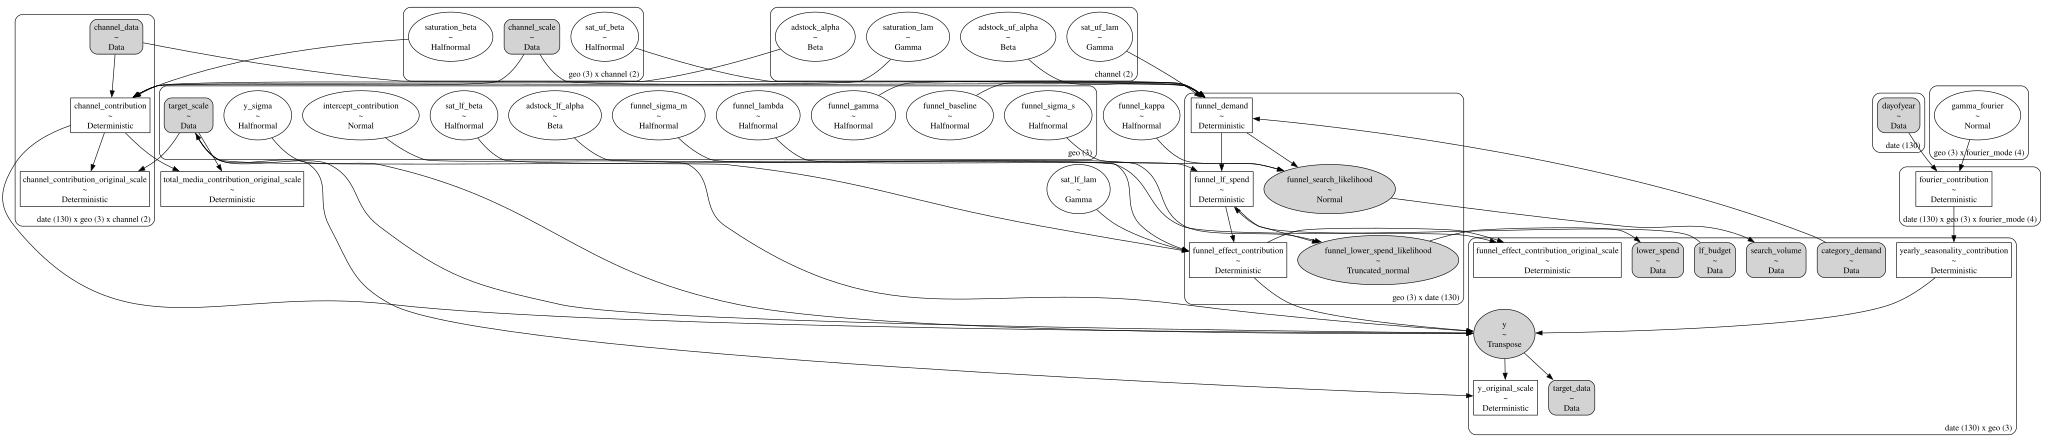

In [16]:
pm.model_to_graphviz(gen.model)

In [17]:
gen.model = do(gen.model, true)

var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "funnel_effect_contribution_original_scale",
    "funnel_demand",
    "funnel_lf_spend",
]
pp_names = ["funnel_lower_spend_likelihood", "funnel_search_likelihood"]

with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1, var_names=var_names + pp_names, random_seed=SEED["generative"]
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].transpose("date", "geo").to_numpy()
demand_true = prior["funnel_demand"].transpose("date", "geo").to_numpy()
lf_spend_true = prior["funnel_lf_spend"].transpose("date", "geo").to_numpy()
lower_spend_obs = (
    prior_pp["funnel_lower_spend_likelihood"].transpose("date", "geo").to_numpy()
)
search_obs = prior_pp["funnel_search_likelihood"].transpose("date", "geo").to_numpy()
direct_true = (
    prior["channel_contribution_original_scale"]
    .transpose("date", "geo", "channel")
    .to_numpy()
)
indirect_raw = (
    prior["funnel_effect_contribution_original_scale"]
    .transpose("date", "geo")
    .to_numpy()
)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


### The true causal decomposition

The raw `funnel_effect_contribution` includes the demand that comes from the
baseline and the category index, which upper-funnel spend never created. To
isolate each channel's **causal** indirect contribution we re-run the clamped
generative model with that channel's spend set to zero and subtract. Running the
same counterfactual with *both* channels off lets us measure the non-additivity.

This is the standard mixed-regime construction of mediation analysis: an
expectation in which the treatment takes one value in the outcome equation and
another in the mediator equation. [Mediation Analysis and (In)Direct Effects with
PyMC](https://juanitorduz.github.io/mediation/) writes those as
$E_{t, t', t''}$ and evaluates them with `pm.do` on the generative model, which
is exactly what the cell below does -- here the two "regimes" are a channel's
observed spend and zero spend.

In [18]:
def forward_with_zeroed(channel_mask, seed) -> dict[str, np.ndarray]:
    """Mediated contribution and structural LF spend with masked channels zeroed."""
    media_cf = media_raw.copy()
    media_cf[..., channel_mask] = 0.0
    with gen.model:
        pm.set_data({"channel_data": media_cf})
        idata_cf = pm.sample_prior_predictive(
            draws=1,
            var_names=["funnel_effect_contribution_original_scale", "funnel_lf_spend"],
            random_seed=seed,
        )
    draw = idata_cf["prior"].sel(chain=0, draw=0)
    return {
        var: draw[var].transpose("date", "geo").to_numpy()
        for var in ["funnel_effect_contribution_original_scale", "funnel_lf_spend"]
    }


cf_gen = {
    "tv_spend": forward_with_zeroed(np.array([True, False]), SEED["cf_gen_tv"]),
    "social_spend": forward_with_zeroed(np.array([False, True]), SEED["cf_gen_social"]),
    "both": forward_with_zeroed(np.array([True, True]), SEED["cf_gen_both"]),
}

indirect_true = np.stack(
    [
        indirect_raw - cf_gen[ch]["funnel_effect_contribution_original_scale"]
        for ch in channels
    ],
    axis=-1,
)
indirect_both = (
    indirect_raw - cf_gen["both"]["funnel_effect_contribution_original_scale"]
)

# The same counterfactual also prices each channel's *induced* lower-funnel spend:
# the structural spend M* with the channel on, minus M* with it off. Because the
# coefficient on D in the M* equation is exactly one, a unit of induced demand is a
# unit of incremental lower-funnel spend -- we will need this when defining ROAS.
induced_spend_true = np.stack(
    [lf_spend_true - cf_gen[ch]["funnel_lf_spend"] for ch in channels], axis=-1
)

# Restore the generative model's media data.
with gen.model:
    pm.set_data({"channel_data": media_raw})

total_true = direct_true + indirect_true

Sampling: []


Sampling: []


Sampling: []


```{note}
Unlike the single-channel example, we keep the **full** date range rather than
dropping the first `l_max` weeks. The generative model and the fitted models apply
the same zero-padded adstock, so the early weeks are not an artifact. Dropping them
would actually *introduce* one: the fitted model would be asked to explain weeks
whose carryover history had been deleted.
```

In [19]:
data = xr.Dataset(
    {
        "tv_spend": (("date", "geo"), media_raw[..., 0]),
        "social_spend": (("date", "geo"), media_raw[..., 1]),
        "category_demand": (("date", "geo"), category_demand),
        "lf_budget": (("date", "geo"), lf_budget),
        "lower_spend": (("date", "geo"), lower_spend_obs),
        "search_volume": (("date", "geo"), search_obs),
        "y": (("date", "geo"), y_obs),
        "demand_true": (("date", "geo"), demand_true),
        "lf_spend_true": (("date", "geo"), lf_spend_true),
        "direct_true": (("date", "geo", "channel"), direct_true),
        "indirect_true": (("date", "geo", "channel"), indirect_true),
        "total_true": (("date", "geo", "channel"), total_true),
        "induced_spend_true": (("date", "geo", "channel"), induced_spend_true),
    },
    coords={**coords, "channel": channels},
)

shares = (
    data["indirect_true"].mean("date") / data["total_true"].mean("date")
).to_dataframe(name="indirect share")
shares["indirect share"] = shares["indirect share"].map("{:.1%}".format)
shares

indirect share
geo   channel                    
north tv_spend              34.2%
      social_spend          33.8%
south tv_spend              37.4%
      social_spend          35.6%
west  tv_spend              36.8%
      social_spend          34.1%

Between a third and two fifths of every upper-funnel channel's effect travels
through the mediator. Now the non-additivity:

In [20]:
sum_of_singles = float(data["indirect_true"].sum("channel").mean())
joint = float(indirect_both.mean())
print(f"Sum of single-channel indirect effects: {sum_of_singles:.3f}")
print(f"Indirect effect of switching both off:  {joint:.3f}")
print(f"Shortfall from treating paths as additive: {1 - sum_of_singles / joint:.1%}")

Sum of single-channel indirect effects: 0.274
Indirect effect of switching both off:  0.317
Shortfall from treating paths as additive: 13.6%


Because the two channels share one saturating demand pool, per-channel indirect
effects computed one at a time **understate** their joint effect by about 14%.
This is not a bug: with a concave response there is no unique way to split a joint
effect into per-channel pieces, and leave-one-out attribution is one convention
among several. It is worth stating explicitly whenever these numbers inform a
budget conversation.

The mediation literature names the leftover rather than rounding it away.
[Mediation Analysis and (In)Direct Effects with
PyMC](https://juanitorduz.github.io/mediation/) decomposes a total effect with
two mediators as $\text{TE} = \text{DE} + \text{IIE}_1 + \text{IIE}_2 +
\text{INT} + \text{DEP}$, where the interaction and dependence terms are
precisely the mass the individual indirect effects do not sum to. The axis is
different here -- our shortfall comes from two *treatments* pushing on one shared
mediator, not from one treatment reaching the outcome through two mediators --
but the lesson carries over: the gap is a term with a name, and which convention
you report is a choice you owe your reader.

### Exploratory visualization

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/3923279031.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.972))


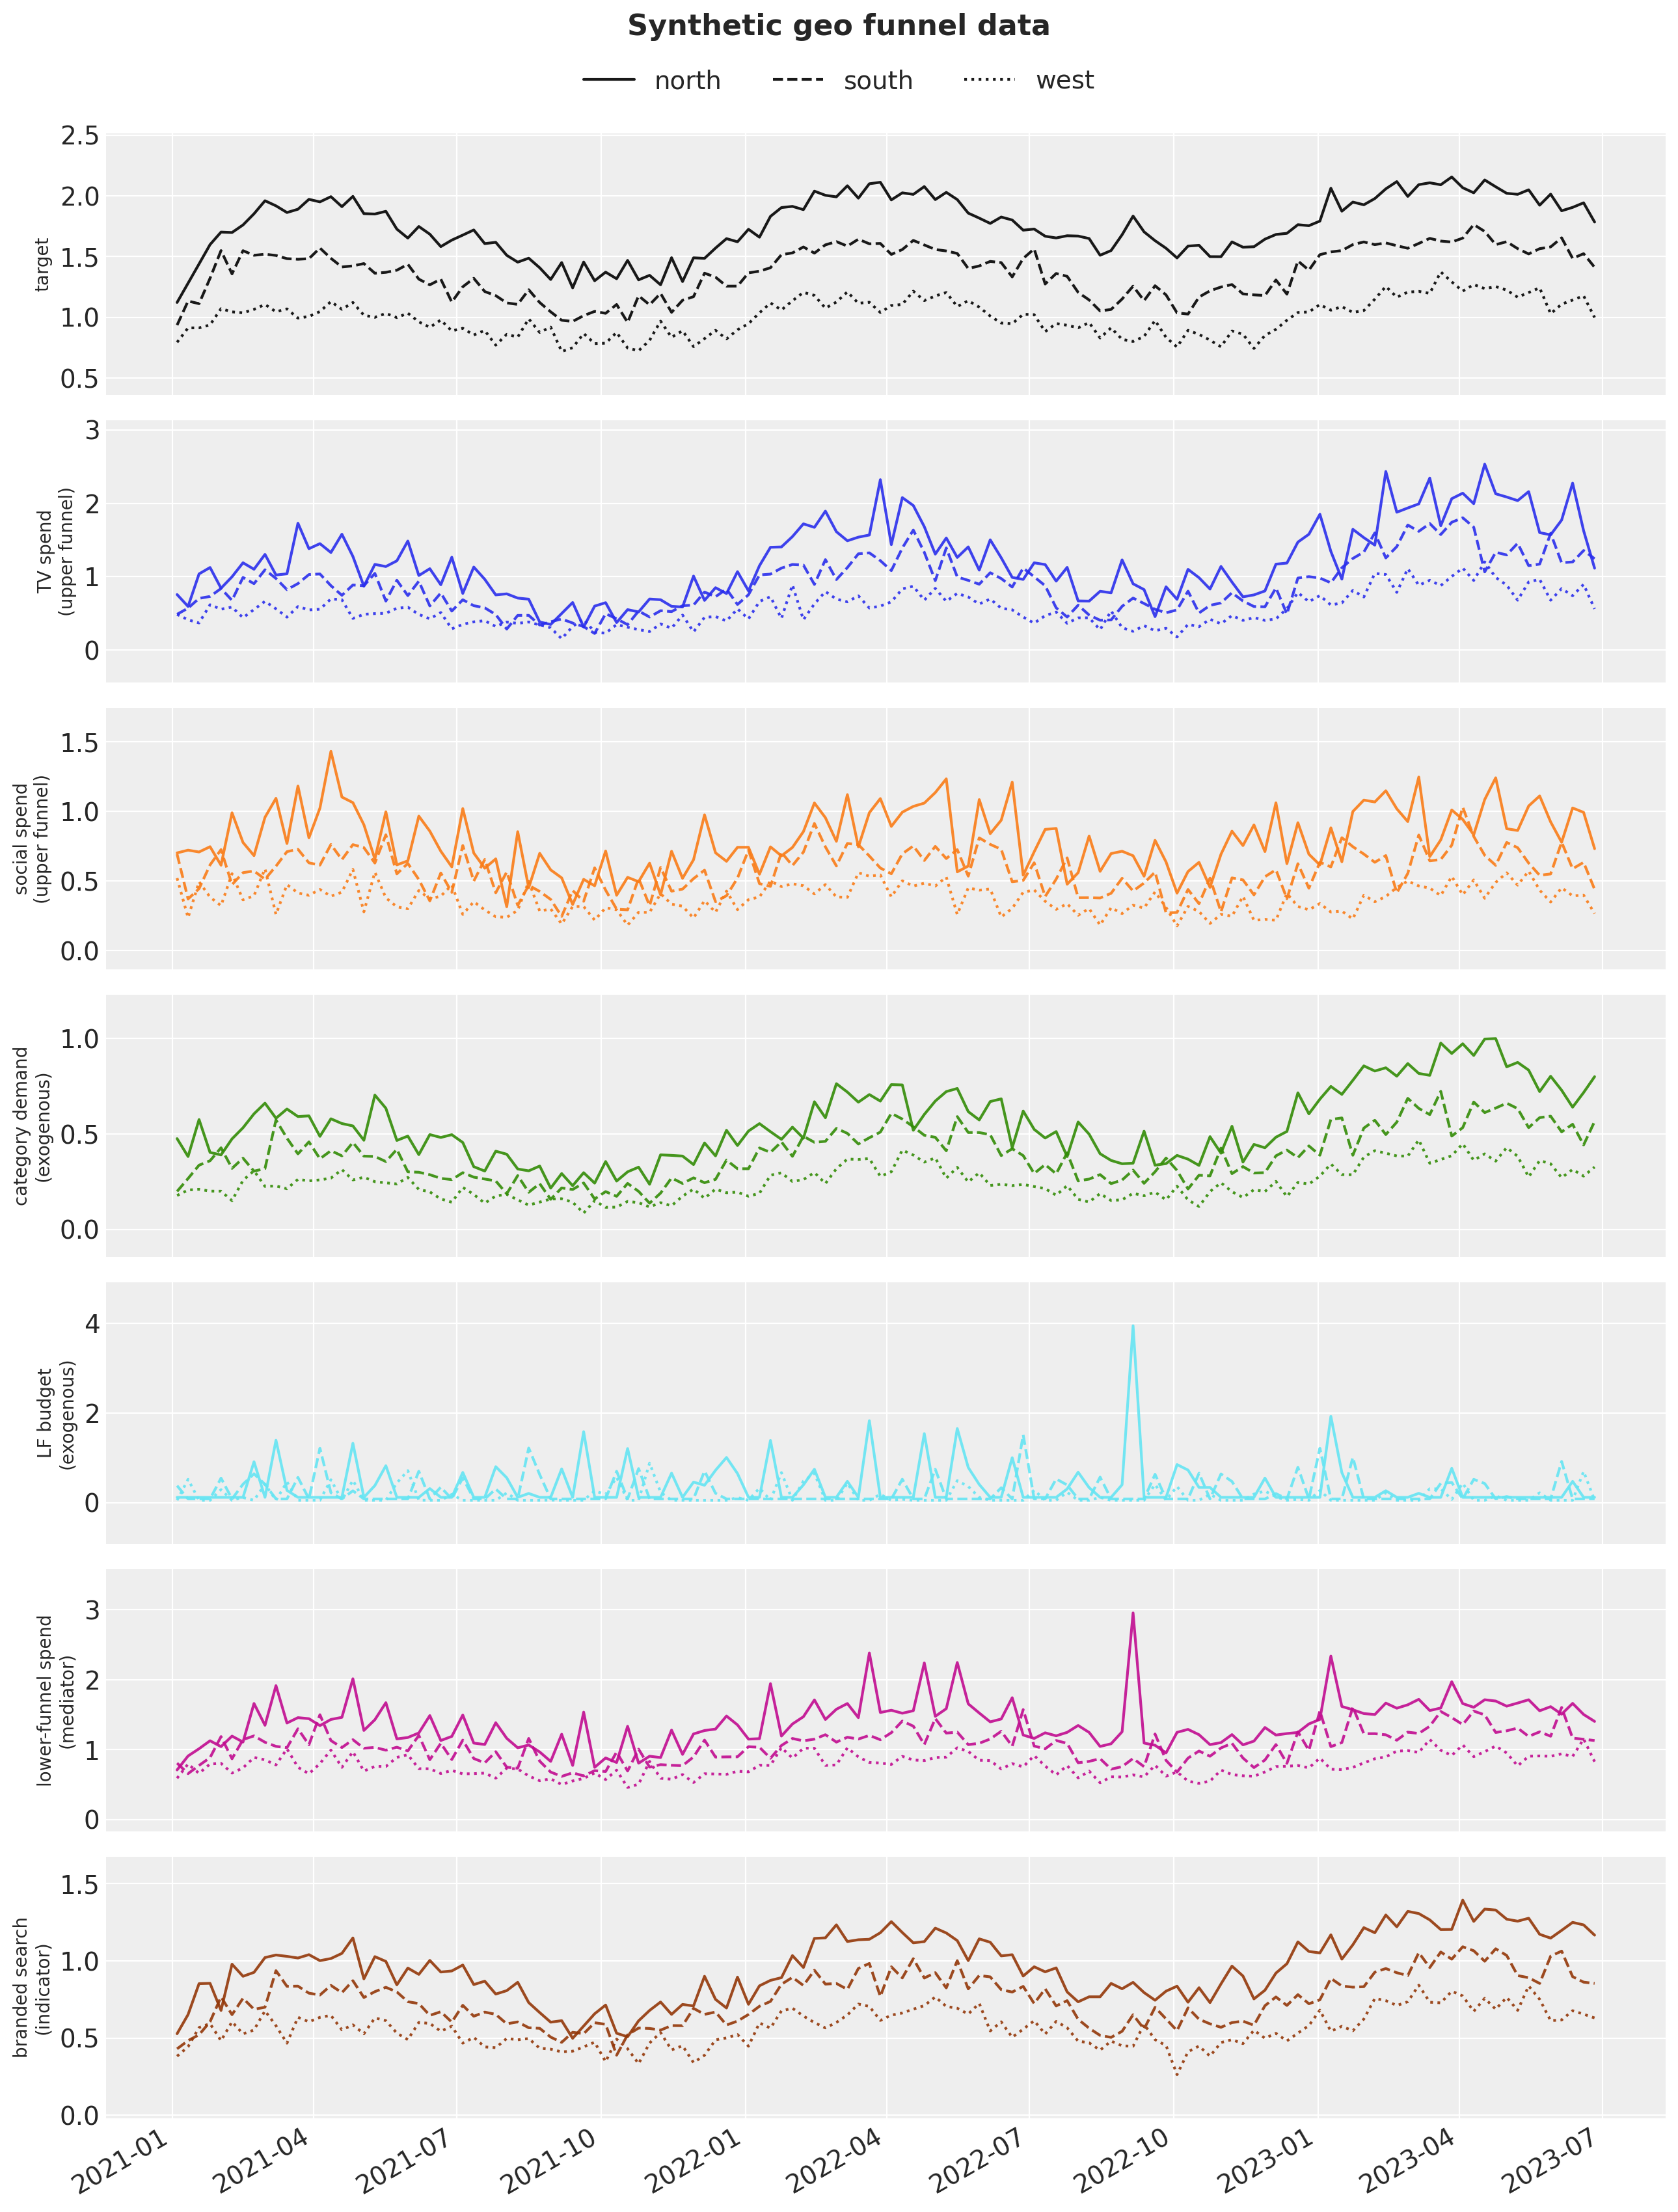

In [21]:
series = [
    ("y", "target", "black"),
    ("tv_spend", "TV spend\n(upper funnel)", "C0"),
    ("social_spend", "social spend\n(upper funnel)", "C1"),
    ("category_demand", "category demand\n(exogenous)", "C2"),
    ("lf_budget", "LF budget\n(exogenous)", "C5"),
    ("lower_spend", "lower-funnel spend\n(mediator)", "C3"),
    ("search_volume", "branded search\n(indicator)", "C4"),
]

fig, axes = plt.subplots(nrows=len(series), ncols=1, figsize=(13, 17), sharex=True)
for ax, (name, label, color) in zip(axes, series, strict=True):
    for geo, style in zip(geos, ["-", "--", ":"], strict=True):
        ax.plot(
            date_range,
            data[name].sel(geo=geo),
            linestyle=style,
            color=color,
            label=geo,
            alpha=0.9,
        )
    # The variable name lives in the y-label, not a title -- with seven stacked
    # panels, per-axes titles collide with the suptitle and with each other.
    ax.set_ylabel(label, fontsize=10)
    ax.margins(y=0.25)
# One figure-level legend: per-axes legends would repeat the same three geo
# entries in every panel.
handles, geo_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, geo_labels, loc="upper center", bbox_to_anchor=(0.5, 0.982), ncols=3
)
fig.suptitle("Synthetic geo funnel data", fontsize=16, fontweight="bold", y=0.997)
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.972))

Zooming in on the latent layer shows how the pieces relate. Lower-funnel spend
sits *above* latent demand by the budget-driven wedge $\lambda_g B_{t,g}$, and the
reported series tracks that structural quantity up to reporting noise. Branded
search follows demand itself, scaled by $\kappa$.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/3369902314.py:44: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.86))


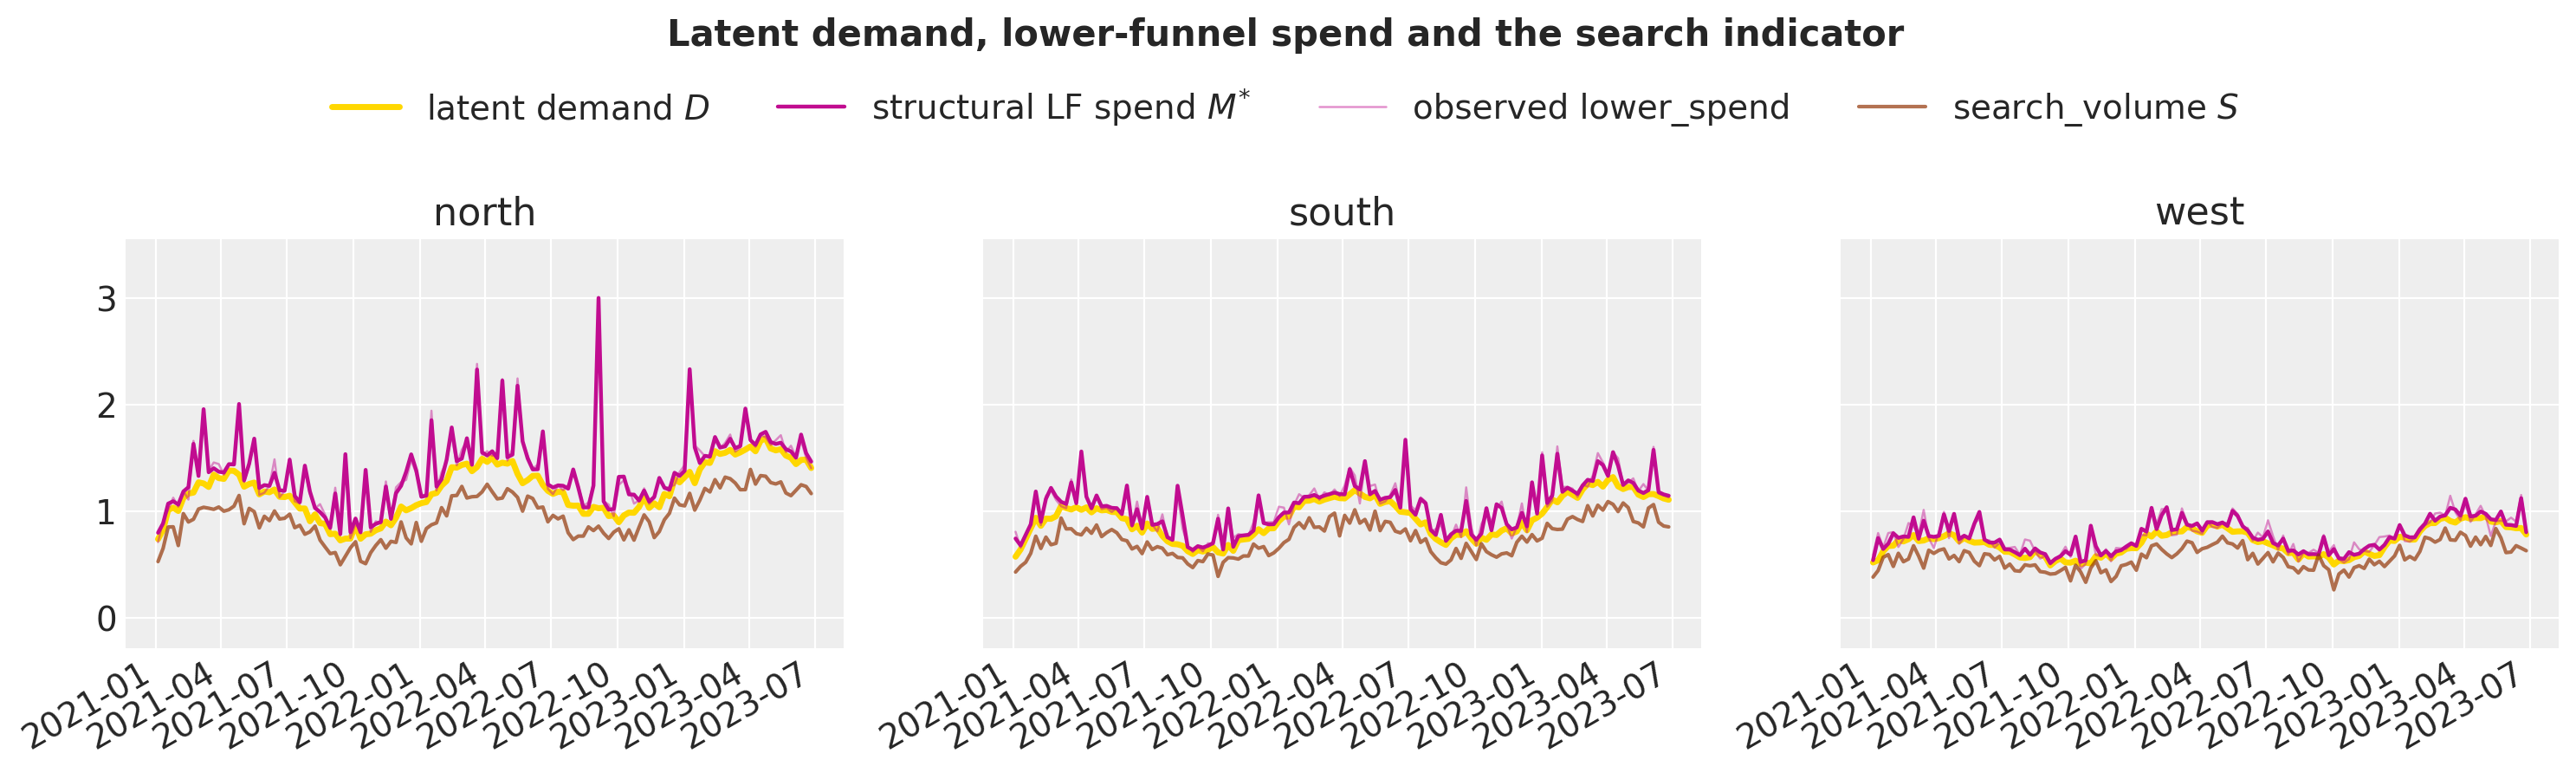

In [22]:
fig, axes = plt.subplots(ncols=len(geos), figsize=(15, 4.5), sharey=True)
for ax, geo in zip(axes, geos, strict=True):
    ax.plot(
        date_range,
        data["demand_true"].sel(geo=geo),
        color="gold",
        lw=2.5,
        label="latent demand $D$",
    )
    ax.plot(
        date_range,
        data["lf_spend_true"].sel(geo=geo),
        color="C3",
        lw=1.6,
        label="structural LF spend $M^{*}$",
    )
    ax.plot(
        date_range,
        data["lower_spend"].sel(geo=geo),
        color="C3",
        alpha=0.45,
        lw=0.9,
        label="observed lower_spend",
    )
    ax.plot(
        date_range,
        data["search_volume"].sel(geo=geo),
        color="C4",
        alpha=0.7,
        label="search_volume $S$",
    )
    ax.set_title(geo)
    ax.margins(y=0.2)
# One figure-level legend, placed under the title: a per-axes legend sits on top of
# the lines in every panel.
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    "Latent demand, lower-funnel spend and the search indicator",
    fontsize=15,
    fontweight="bold",
)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=4)
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.86))

## What the graph already says

Before fitting anything, the DAG itself can be interrogated. Each model below is,
causally speaking, just a **conditioning set**: the variables it regresses the
target on. Pearl's backdoor criterion says a set $Z$ identifies the *total* effect
of a treatment on $Y$ exactly when (i) $Z$ contains no descendant of the
treatment, and (ii) $Z$ d-separates treatment from target in the graph with the
treatment's outgoing edges removed. Both conditions are mechanical graph checks,
and [networkx](https://networkx.org/documentation/stable/reference/algorithms/d_separation.html)
ships them -- so instead of asserting who is biased and why, we can compute it.

The same edge list that drew the figure builds the graph:

In [23]:
G = nx.DiGraph([(parent, child) for parent, child, _ in DAG_EDGES])
treatment, outcome = "U1", "Y"

descendants = nx.descendants(G, treatment)
print(f"descendants({treatment}) = {sorted(descendants)}")

# Backdoor surgery: remove the treatment's outgoing edges.
G_do = G.copy()
G_do.remove_edges_from(list(G.out_edges(treatment)))

# What each model conditions on when estimating tv_spend's effect. Every model
# includes the other channel and the Fourier basis (= the `season` node); they
# differ only in what else they add.
conditioning_sets = {
    "Naive A (mediator as channel)": {"U2", "season", "M"},
    "Naive B (mediator omitted)": {"U2", "season"},
    "Naive B+ (demand as control)": {"U2", "season", "C"},
    "Naive B++ (trend as control)": {"U2", "season", "t"},
    "Naive C (indicator as channel)": {"U2", "season", "S"},
    "(hypothetical: condition on M*)": {"U2", "season", "MS"},
}

rows = {}
for label, Z in conditioning_sets.items():
    forbidden = sorted(Z & descendants)
    blocks = nx.is_d_separator(G_do, {treatment}, {outcome}, Z)
    rows[label] = {
        "conditions on": ", ".join(sorted(Z)),
        "descendant of U₁ in Z": ", ".join(forbidden) or "—",
        "blocks all backdoors": blocks,
        "valid for total effect": blocks and not forbidden,
    }

# The prose below claims the verdicts are symmetric in the treatment. Compute
# that rather than assert it: re-run every check with U2 as treatment (its
# conditioning sets swap in the *other* channel, U1).
G_do_u2 = G.copy()
G_do_u2.remove_edges_from(list(G.out_edges("U2")))
descendants_u2 = nx.descendants(G, "U2")
for label, Z in conditioning_sets.items():
    Z_u2 = {("U1" if z == "U2" else z) for z in Z}
    blocks_u2 = nx.is_d_separator(G_do_u2, {"U2"}, {outcome}, Z_u2)
    valid_u2 = blocks_u2 and not (Z_u2 & descendants_u2)
    if (
        blocks_u2 != rows[label]["blocks all backdoors"]
        or valid_u2 != rows[label]["valid for total effect"]
    ):
        raise ValueError(f"verdict differs with U2 as treatment: {label}")
print("every verdict below also holds with U2 as the treatment (checked cell by cell)")

pd.DataFrame(rows).T

descendants(U1) = ['D', 'M', 'MS', 'S', 'Y']
every verdict below also holds with U2 as the treatment (checked cell by cell)


,conditions on,descendant of U₁ in Z,blocks all backdoors,valid for total effect
Naive A (mediator as channel),"M, U2, season",M,False,False
Naive B (mediator omitted),"U2, season",—,False,False
Naive B+ (demand as control),"C, U2, season",—,True,True
Naive B++ (trend as control),"U2, season, t",—,False,False
Naive C (indicator as channel),"S, U2, season",S,False,False
(hypothetical: condition on M*),"MS, U2, season",MS,True,False


Reading the verdicts off the table:

- **Naive B fails condition (ii).** With only the other channel and the seasonal
  basis conditioned, the backdoor $U_1 \leftarrow t \to C \to D \to
  M^{*} \to Y$ stays open -- and so does its twin through the drivers' shared
  noise, $U_1 \leftarrow N \to C \to D \to M^{*} \to Y$. Note what this is
  *not*: omitting the mediator is the **correct** move for a total effect --
  that is what makes it a total effect. The graph-level defect is the open
  backdoor through the shared driver, whose trend leg is the co-movement the
  residual-correlation table showed surviving the seasonal adjustment on the TV
  side.
- **Naive B+ is valid; Naive B++ is not.** Both fork nodes, $t$ and $N$, sit
  upstream of *both* the treatment and $C$, and $C$ sits on both paths
  downstream of them -- so conditioning on the observed category index blocks
  the trend leg **and** the noise leg at once. Conditioning on $t$ blocks only
  the leg it names: the noise path stays open, and $N$ is unobservable, so
  `Naive B++` cannot close it by adding a column. Neither variable is a
  descendant of the treatment, so what separates them is coverage, not
  condition (i).
- **Naive A and Naive C fail condition (i)** -- each conditions on a descendant of
  the treatment (`M` via $U_1 \to D \to M^{*} \to M$; `S` via $U_1 \to D \to S$),
  cutting into the causal path itself. No amount of extra controls repairs that.
- **The hypothetical last row is the interesting one**: conditioning on the
  *structural* $M^{*}$ would block every backdoor, yet it is still invalid for the
  total effect for exactly the same reason -- it is a descendant, and conditioning
  on it is what *defines* the direct effect instead.

That last distinction can be made precise. Removing the direct edge
$U_1 \to Y$ and asking whether the conditioning set separates treatment from
target tests whether it isolates the direct path:

In [24]:
G_direct = G.copy()
G_direct.remove_edge(treatment, "Y")

for name, Z in [
    ("M* (structural)", {"U2", "season", "MS"}),
    ("M (noisy observation, what Naive A has)", {"U2", "season", "M"}),
]:
    isolated = nx.is_d_separator(G_direct, {treatment}, {outcome}, Z)
    print(f"conditioning on {name:42s} isolates the direct effect: {isolated}")

conditioning on M* (structural)                            isolates the direct effect: True
conditioning on M (noisy observation, what Naive A has)    isolates the direct effect: False


So `Naive A` is not estimating the total effect *badly* -- it is (approximately)
estimating the **direct** effect. Approximately, because it conditions on the
noisy observation `M` rather than the structural `M*`: strict d-separation fails
through the measurement noise, and the approximation is good exactly to the
extent $\sigma^M$ is small. Keep this in mind for the comparisons below, where we
benchmark Naive A against the quantity it actually answers for.

Finally, the graph can be asked what adjustment it would *recommend*:

In [25]:
# Sorted rather than printed as a set: a set's repr order is not stable across
# processes, and this notebook's outputs are meant to reproduce exactly.
print(
    "minimal separator, unrestricted:        ",
    sorted(nx.find_minimal_d_separator(G_do, {treatment}, {outcome})),
)
# `N` is deliberately absent from `observable`: it is the drivers' shared noise,
# which no column in any dataset carries. The unrestricted answer above is free to
# name it; a practitioner can only act on this second, restricted one.
observable = {"U2", "season", "C", "B", "M", "S", "t"} - descendants
print(
    "minimal separator, observables only:    ",
    sorted(
        nx.find_minimal_d_separator(
            G_do,
            {treatment},
            {outcome},
            included={"U2", "season"},
            restricted=observable | {"U2", "season"},
        )
    ),
)

minimal separator, unrestricted:         ['N', 'season', 't']
minimal separator, observables only:     ['C', 'U2', 'season']


Unrestricted, the graph asks for the season and the trend -- and for $N$, which
no dataset contains. Restricted to observed, non-descendant variables (and told
that the other channel and the seasonal basis are already in every model), it
returns $\{C, U_2, \text{season}\}$: **the graph nominates `Naive B+`'s
specification**, and it drops $t$ altogether, because conditioning on the
observed category index blocks the trend leg and the noise leg in one move.

`Naive B++` is the cheaper specification -- a column computed from the calendar,
no extra data series -- but it is valid only *conditionally*: it closes the
trend fork and leaves the noise fork open, so reading it as a valid total-effect
estimator is an assumption about the size of the driver-noise correlation we
measured above ($|r| \le 0.25$ per geo, $\le 0.16$ pooled, against a prior
scatter of 0.10). That is the honest status of most trend controls in practice,
and it is worth stating as an assumption rather than a verdict. Both models are
fit below, so the graph's ranking can be checked against the truth rather than
taken on faith -- and the empirical result is not the one the ranking suggests,
which is the point of checking. The same verdicts hold with `U2` as the
treatment -- computed cell by cell alongside the table above, not assumed.

One model is deliberately missing from this analysis: the **funnel model** is
not identified by an adjustment set at all. It identifies by specifying the
full structural system, and that buys correctness exactly insofar as the demand
equation is correctly specified (including $C$'s role in it) and nothing
unobserved confounds $M^{*} \to Y$. The backdoor machinery cannot certify
those assumptions; the parameter-recovery and proxy-predictive checks later in
the notebook are their empirical substitute.

One more thing the graph makes testable. The exclusion restriction "the budget
enters lower-funnel spend but not branded search" implies $B \perp S$
*marginally* -- their only connecting path runs through the collider at $M^{*}$,
which stays blocked as long as nothing downstream of it is conditioned on:

In [26]:
print("B independent of S given {}:   ", nx.is_d_separator(G, {"B"}, {"S"}, set()))
print("B independent of S given {Y}: ", nx.is_d_separator(G, {"B"}, {"S"}, {"Y"}))
print("B independent of S given {M}: ", nx.is_d_separator(G, {"B"}, {"S"}, {"M"}))

for gi, geo in enumerate(geos):
    r = np.corrcoef(lf_budget[:, gi], search_obs[:, gi])[0, 1]
    print(f"corr(lf_budget, search_volume) in {geo}: {r:+.3f}")

B independent of S given {}:    True
B independent of S given {Y}:  False
B independent of S given {M}:  False
corr(lf_budget, search_volume) in north: -0.071
corr(lf_budget, search_volume) in south: -0.026
corr(lf_budget, search_volume) in west: +0.049


The raw-data correlations sit at zero per geo, as the graph says they should.
(Per geo matters: pooled across regions both series scale with market size, which
manufactures a spurious positive correlation -- and conditioning on anything
downstream of $M^{*}$, including the target, *opens* the collider, so this check
only works on the raw series.) If real data failed this check, the exclusion
restriction -- and with it the identification of $\lambda$ -- would be suspect
before a single model was fit.

```{note}
For production use, {class}`~pymc_marketing.mmm.causal.CausalGraphModel` packages
this machinery -- give `MMM` a DAG string and it computes adjustment sets with
equivalent machinery via [dowhy](https://github.com/microsoft/dowhy), whose
`CausalModel` it wraps. We ran the checks with raw `networkx` here so the
descendant and collider reasoning stays visible.
```

## Fitting the models

We fit six models on the synthetic data:

- **Naive A** -- a standard geo MMM with the mediator thrown in as an **ordinary
  channel** alongside the two upper-funnel channels.
- **Naive B** -- a standard geo MMM with the mediator **omitted**.
- **Naive B+** -- Naive B plus `category_demand` as a **control column**: the
  adjustment set the d-separation analysis nominated, and the only one available
  here that is valid without further assumptions.
- **Naive B++** -- Naive B plus the **growth trend** as a control column: the
  cheapest candidate fix, valid under the assumption that the drivers' shared
  noise is negligible.
- **Naive C** -- a standard geo MMM with **branded search volume** as a channel.
- **Funnel** -- the joint model with the `FunnelEffect`.

All six share adstock/saturation families, priors, scaling and sampler settings.
The five naive models differ from one another only in which observed series they
condition on, so differences among *them* are structural. The funnel model
additionally observes more than any of them -- two extra likelihood series
(`lower_spend`, `search_volume`) and two extra inputs (`category_demand`,
`lf_budget`) -- so where it has an advantage, that advantage comes from
structure *and* information together, a distinction worth keeping in mind when
reading the comparisons.

In [27]:
frame = (
    data[
        [
            "tv_spend",
            "social_spend",
            "lower_spend",
            "search_volume",
            "category_demand",
            "y",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

X_upper = frame[["date", "geo", *channels]]
X_with_mediator = frame[["date", "geo", *channels, "lower_spend"]]
X_with_search = frame[["date", "geo", *channels, "search_volume"]]
X_with_control = frame[["date", "geo", *channels, "category_demand"]]
# The growth trend as a control regressor: observable from the calendar alone.
frame["t"] = frame["date"].map(dict(zip(date_range, t, strict=True)))
X_with_trend = frame[["date", "geo", *channels, "t"]]
y = frame["y"]

sample_kwargs = dict(chains=4, tune=1_000, draws=1_000, target_accept=0.95)
sampler_config = {"nuts_sampler": "nutpie"}

### Naive A: mediator as an ordinary channel

This is what most production MMMs do when they have upper- and lower-funnel spend
in the same table: list them side by side. It is not an unreasonable model -- in
this DAG lower-funnel spend really does drive the target, so the coefficient it
estimates is a real thing. But as the d-separation table showed, conditioning on
the mediator **blocks the indirect path**: the upper channels are credited with at
most their direct effect, and the lower-funnel channel keeps the credit for demand
they created. Naive A is not a broken model so much as a model that silently
answers a different question -- the *direct* effect -- and we will benchmark it
against that quantity as well as against the total.

In [28]:
naive_a = make_mmm([*channels, "lower_spend"], sampler_config=sampler_config)
naive_a.build_model(X_with_mediator, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X_with_mediator, y, random_seed=SEED["fit_naive_a"], **sample_kwargs)
naive_a.sample_posterior_predictive(X_with_mediator, random_seed=SEED["pp_naive_a"]);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B: mediator omitted

Here the two upper channels are the only media. Causally this is the **right
estimand**: not conditioning on the mediator is exactly what makes a total effect
a total effect. Naive B has two distinct problems, and they will land on
different channels. The first is the one the graph isolated -- the open
backdoor through the shared growth trend, which the residual-correlation table
showed is material for TV and absent for social. The second the graph is
silent about: with the mediator omitted, each response curve also has to absorb
the demand its channel creates downstream, mediated through a saturating pool
the model does not represent. Where each part lands, we will let the results
say.

In [29]:
naive_b = make_mmm(channels, sampler_config=sampler_config)
naive_b.build_model(X_upper, y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X_upper, y, random_seed=SEED["fit_naive_b"], **sample_kwargs)
naive_b.sample_posterior_predictive(X_upper, random_seed=SEED["pp_naive_b"]);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B+: mediator omitted, category demand as a control

This is the adjustment the d-separation analysis nominated: block the remaining
backdoors with the observed category index, which sits downstream of *both*
forks in the shared driver. `MMM` takes it as an ordinary **control column** --
a linear term with a per-geo coefficient, no adstock or saturation -- which is
one argument and no new machinery:

In [30]:
naive_bplus = make_mmm(
    channels, control_columns=["category_demand"], sampler_config=sampler_config
)
naive_bplus.build_model(X_with_control, y)
naive_bplus.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_bplus.fit(X_with_control, y, random_seed=SEED["fit_naive_bplus"], **sample_kwargs)
naive_bplus.sample_posterior_predictive(
    X_with_control, random_seed=SEED["pp_naive_bplus"]
);

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

Two things to note before seeing results. First, on the graph this is a
**formally valid total-effect estimator** at the cost of one extra column -- if
all you need is total ROAS per upper channel, specifications like this are the
honest baseline the funnel model has to beat. Second, its control is a linear
stand-in for a path that is truly nonlinear ($C$ enters through the demand
equation and then a saturating conversion), so some residual bias is possible
even though the graph verdict is clean: d-separation is about *which* variables
suffice, not about functional form. Keep that caveat in mind -- it returns with
force below.

### Naive B++: mediator omitted, the trend as a control

The second candidate is the cheapest specification available here -- no extra
data series at all, since the regressor is a function of the calendar, just one
more control column with a per-geo coefficient. On the graph it is valid only
under the extra assumption that the drivers' shared noise is negligible, which
is the kind of assumption trend controls usually rest on and which we sized
above rather than waved at. The same functional-form caveat applies as for Naive
B+: the trend reaches the target through softplus-rectified plans and a
saturating conversion, and a linear term stands in for all of it.

In [31]:
naive_bpp = make_mmm(channels, control_columns=["t"], sampler_config=sampler_config)
naive_bpp.build_model(X_with_trend, y)
naive_bpp.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_bpp.fit(X_with_trend, y, random_seed=SEED["fit_naive_bpp"], **sample_kwargs)
naive_bpp.sample_posterior_predictive(X_with_trend, random_seed=SEED["pp_naive_bpp"]);

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive C: the indicator as a channel

Branded search volume is the most tempting variable in the whole dataset. It
correlates beautifully with sales, it is free, and it arrives weekly. So it ends up
in the channel list.

It causes nothing. Because it is a **descendant of latent demand**, conditioning on
it blocks $U \to D \to M^{*} \to Y$ just as surely as conditioning on the mediator
itself would -- textbook post-treatment conditioning, on a variable that has no
causal role at all.

In [32]:
naive_c = make_mmm([*channels, "search_volume"], sampler_config=sampler_config)
naive_c.build_model(X_with_search, y)
naive_c.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_c.fit(X_with_search, y, random_seed=SEED["fit_naive_c"], **sample_kwargs)
naive_c.sample_posterior_predictive(X_with_search, random_seed=SEED["pp_naive_c"]);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### The funnel model

The funnel model has the two upper channels (their direct effects) plus the
`FunnelEffect`, which reads the mediator data from the `Dataset` and fits the
target and both proxies jointly. Note the plumbing discussed earlier: we build
from the `Dataset` and fit with the long frame.

In [33]:
ds_fit = make_dataset(
    media_raw, lower_spend_obs, search_obs, category_demand, lf_budget
)
y_fit = xr.DataArray(y_obs, dims=("date", "geo"), coords=coords)

funnel = make_mmm(channels, sampler_config=sampler_config)
funnel.add_mu_effect(make_funnel_effect())
funnel.build_model(X=ds_fit, y=y_fit)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X=X_upper, y=y, random_seed=SEED["fit_funnel"], **sample_kwargs)
funnel.sample_posterior_predictive(X_upper, random_seed=SEED["pp_funnel"]);

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s, funnel_kappa, funnel_sigma_m]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


Output()

### Diagnostics

In [34]:
models = {
    "Naive A": naive_a,
    "Naive B": naive_b,
    "Naive B+": naive_bplus,
    "Naive B++": naive_bpp,
    "Naive C": naive_c,
    "Funnel": funnel,
}

# Scalar parameters only. Summarising every deterministic would pull in the
# date x geo arrays (`funnel_demand`, `funnel_lf_spend`, the contributions) and
# dominate the runtime of this cell.
scalar_params = [
    "intercept_contribution",
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_fourier",
    "gamma_control",
    "y_sigma",
    "funnel_baseline",
    "funnel_gamma",
    "funnel_lambda",
    "funnel_kappa",
    "funnel_sigma_m",
    "funnel_sigma_s",
    "adstock_uf_alpha",
    "sat_uf_lam",
    "sat_uf_beta",
    "adstock_lf_alpha",
    "sat_lf_lam",
    "sat_lf_beta",
]

for label, model in models.items():
    present = [v for v in scalar_params if v in model.idata.posterior]
    divergences = int(model.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(model.idata, var_names=present)["r_hat"].max())
    print(f"{label:9s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")

Naive A   | divergences:   0 | max r-hat: 1.000
Naive B   | divergences:   0 | max r-hat: 1.010
Naive B+  | divergences:   0 | max r-hat: 1.000


Naive B++ | divergences:   0 | max r-hat: 1.010
Naive C   | divergences:   0 | max r-hat: 1.010


Funnel    | divergences:   0 | max r-hat: 1.010


### Posterior predictive checks

The funnel model has **three** observed quantities. All of them should be well
recovered.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/3064146725.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0.01, 0, 1, 0.97))


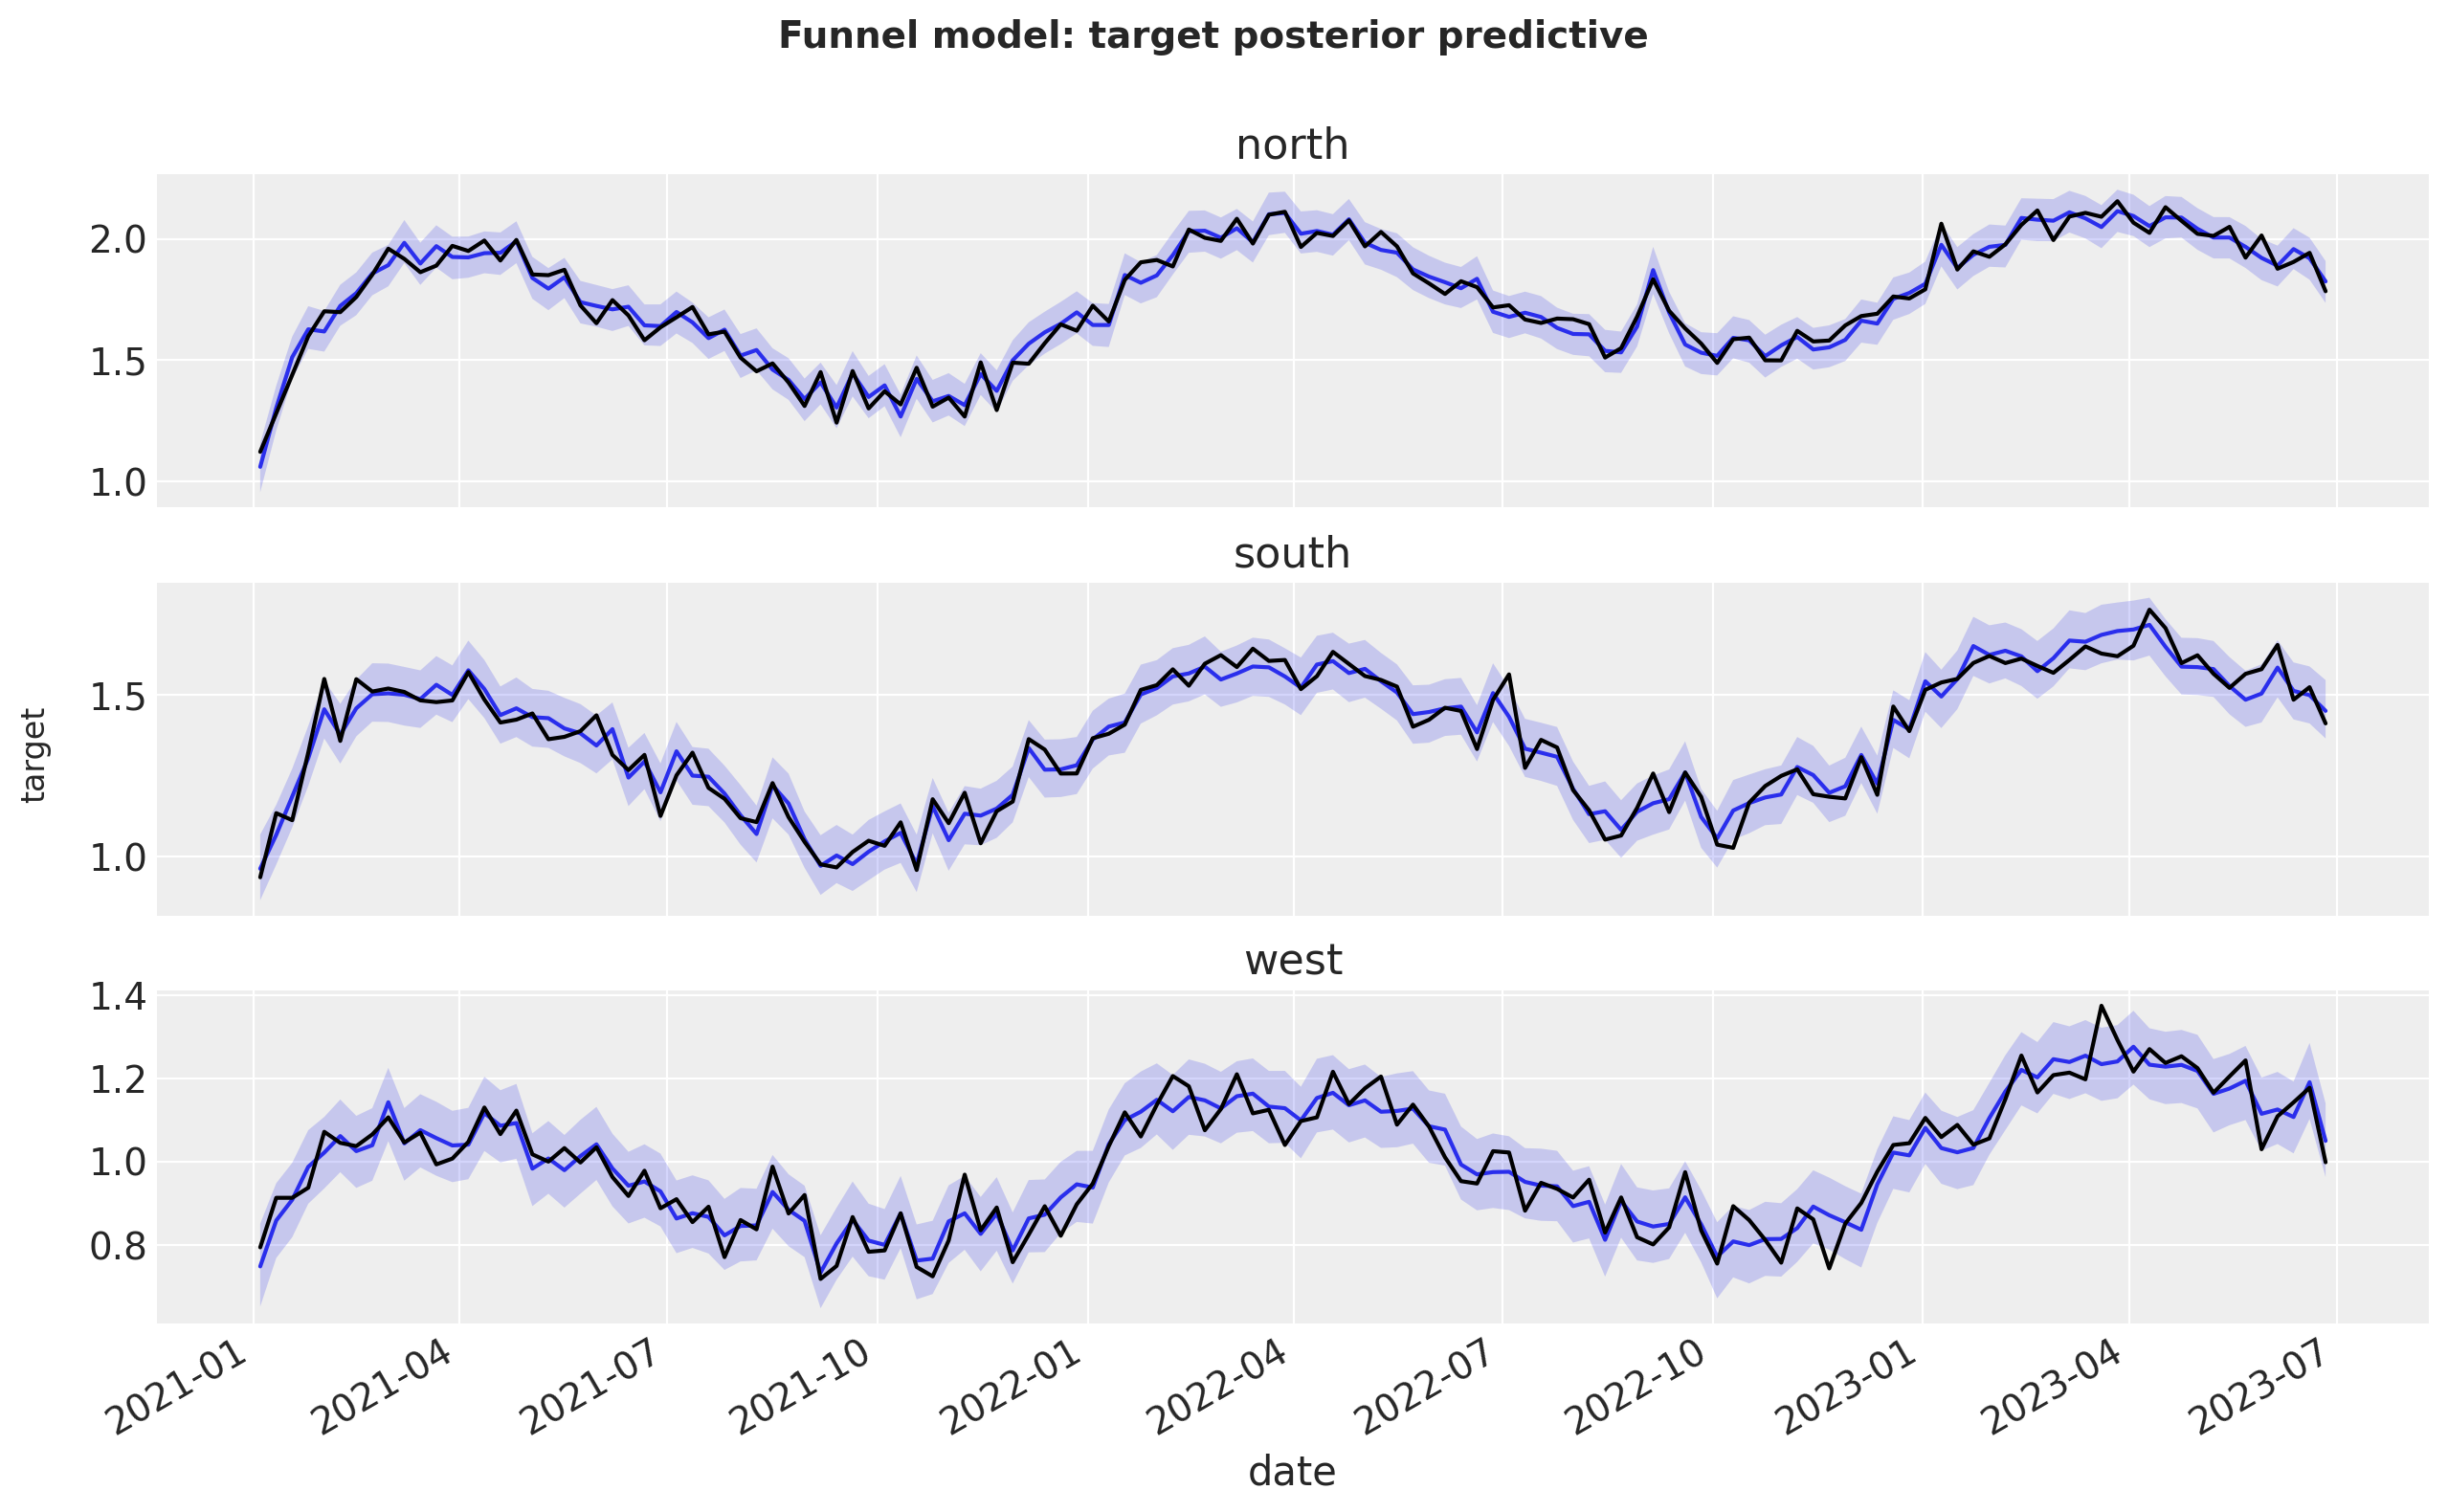

In [35]:
funnel.plot_suite = "new"

# `return_as_pc` gives back the PlotCollection instead of (fig, axes), so panels can
# be addressed by coordinate label rather than by position in `fig.get_axes()`.
pc = funnel.plot.diagnostics.posterior_predictive(
    hdi_prob=0.94, return_as_pc=True, figsize=(13, 8)
)
fig = pc.viz["figure"].item()

for i, geo in enumerate(geos):
    ax = pc.viz["plot"].sel(geo=geo).item()
    # The built-in labels every panel "Date" / "Posterior Predictive"; repeated on a
    # stacked geo facet they collide and spill outside the axes.
    ax.set_xlabel("date" if i == len(geos) - 1 else "")
    ax.set_ylabel("")
    ax.set_title(geo)

fig.supylabel("target")
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold"
)
fig.autofmt_xdate()
fig.tight_layout(rect=(0.01, 0, 1, 0.97))

The other two are the effect's own likelihoods. There is no built-in for these:
`diagnostics.posterior_predictive` targets the model's `y` variable specifically,
so a custom likelihood declared inside a `MuEffect` has to be plotted by hand.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/4010075878.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


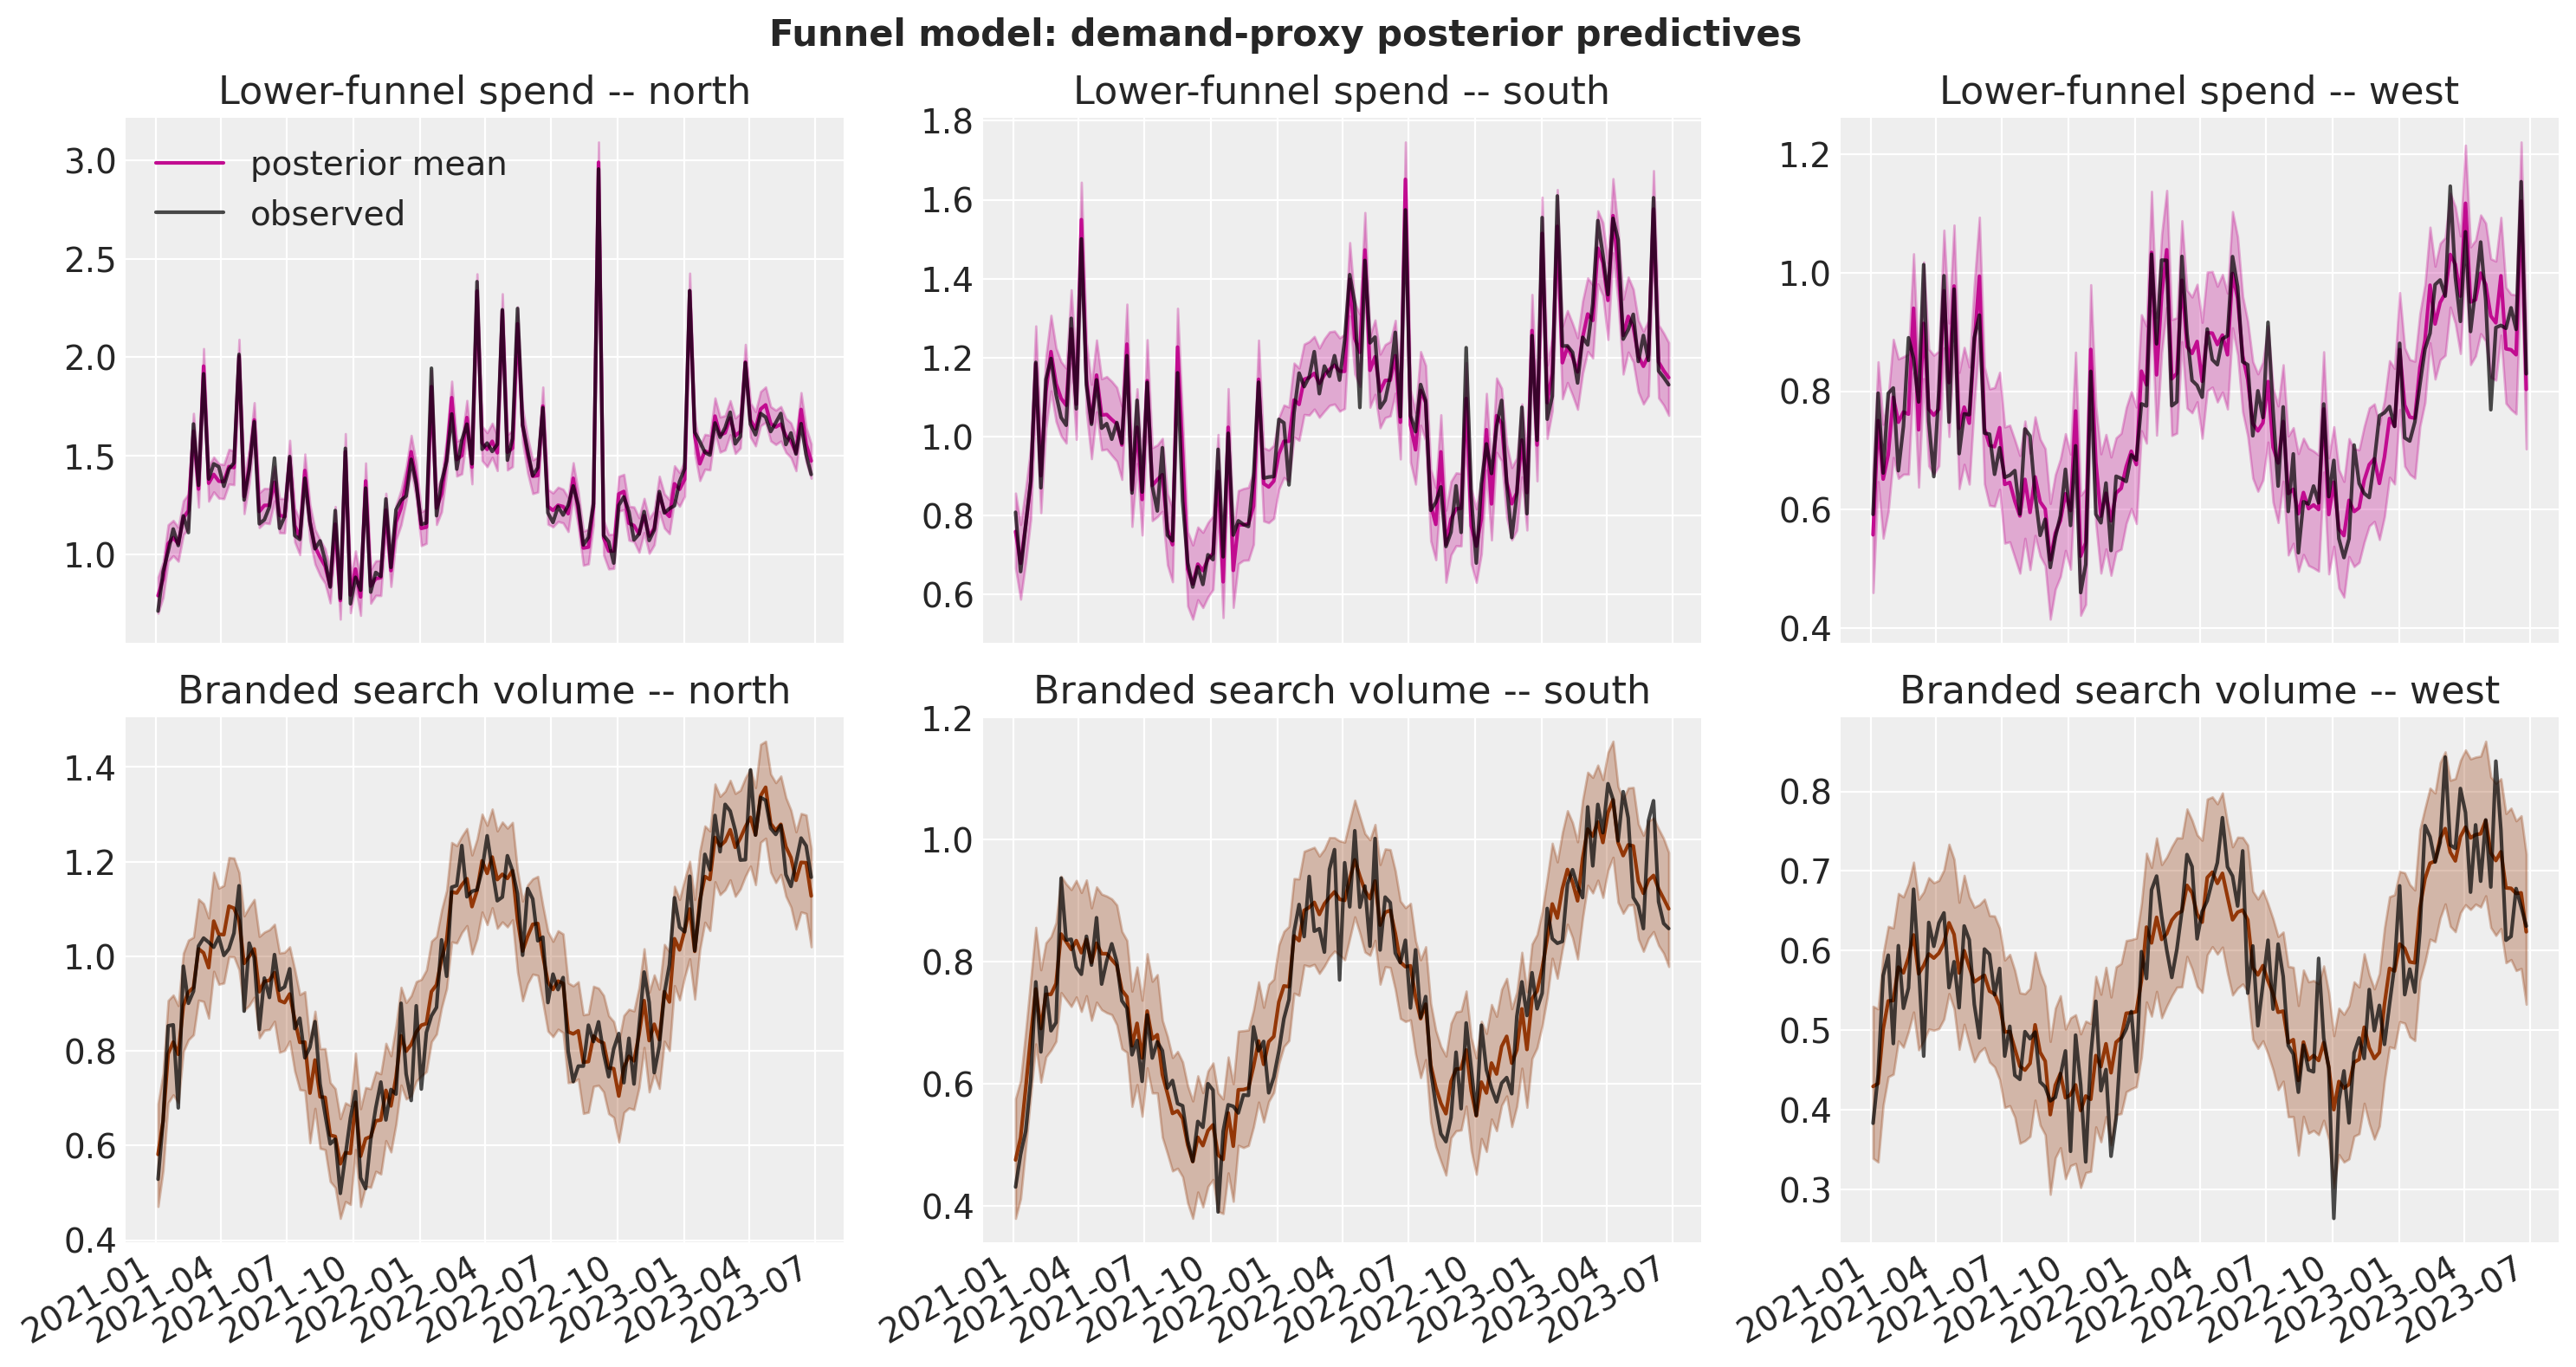

In [36]:
proxies = [
    ("funnel_lower_spend_likelihood", "lower_spend", "Lower-funnel spend", "C3"),
    ("funnel_search_likelihood", "search_volume", "Branded search volume", "C4"),
]

fig, axes = plt.subplots(
    nrows=len(proxies), ncols=len(geos), figsize=(15, 8), sharex=True
)
for row, (var, observed, title, color) in enumerate(proxies):
    pp = funnel.idata.posterior_predictive[var]
    lo, hi = hdi_bounds(pp)
    mean = pp.mean(dim=["chain", "draw"])
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        ax.fill_between(
            date_range, lo.sel(geo=geo), hi.sel(geo=geo), alpha=0.3, color=color
        )
        ax.plot(date_range, mean.sel(geo=geo), color=color, label="posterior mean")
        ax.plot(
            date_range,
            data[observed].sel(geo=geo),
            color="black",
            alpha=0.7,
            label="observed",
        )
        ax.set(title=f"{title} -- {geo}")
axes[0, 0].legend(loc="upper left")
fig.suptitle(
    "Funnel model: demand-proxy posterior predictives",
    fontsize=15,
    fontweight="bold",
)
fig.autofmt_xdate()
fig.tight_layout()

## Parameter recovery

Because we generated the data we can check the funnel model against the truth.
One subtlety carries over from the basic notebook and gets slightly more involved
here: the `MMM` fits on an internally scaled target, so every parameter that acts
on the **scale of the target mean** -- the intercept, the two saturation
amplitudes and the Fourier coefficients -- must be multiplied by `target_scale`
before comparing with the ground truth. With `dims=()` scaling that factor is
**per geo**, and `xarray` applies it by label for us. Parameters acting on the
*inputs* (adstock decays, saturation curvatures) or on the *mediator* scale
(everything in the demand equation) are scale-free and compare directly.

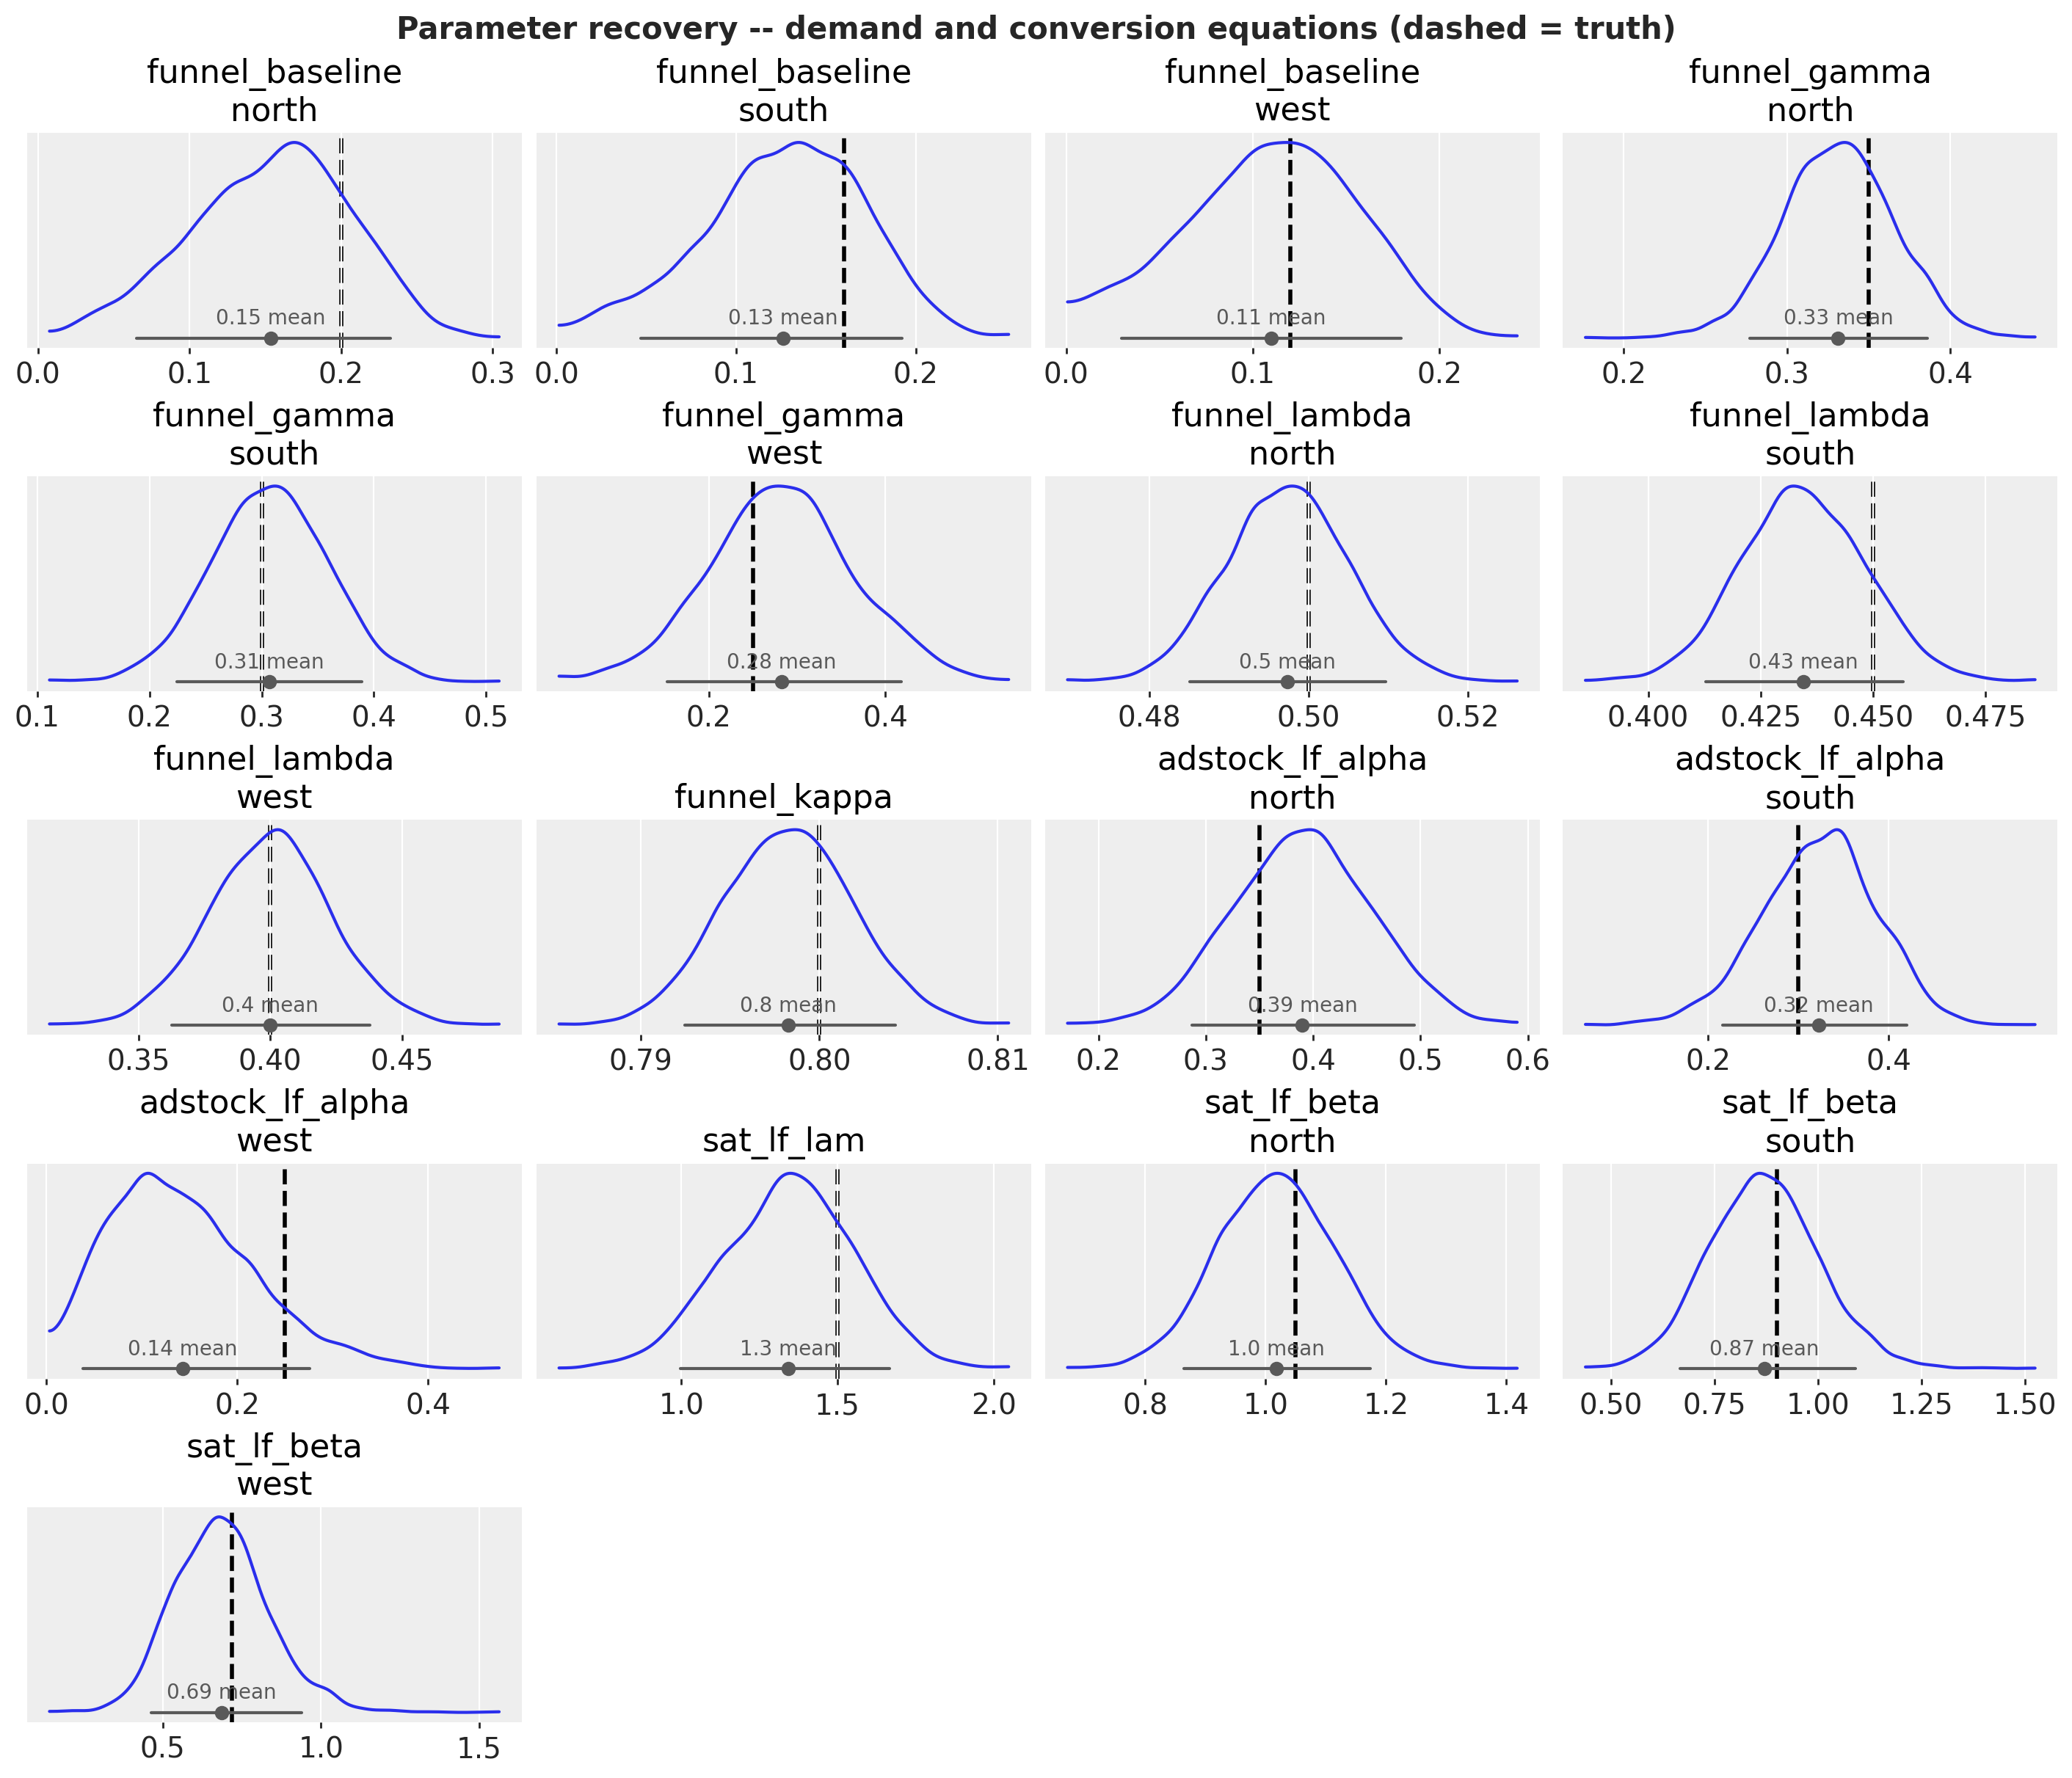

In [37]:
target_scale = funnel.idata.constant_data["target_scale"]
mu_scale_vars = {
    "intercept_contribution",
    "saturation_beta",
    "sat_lf_beta",
    "gamma_fourier",
}

posterior_on_true_scale = xr.Dataset(
    {
        var: (draws * target_scale if var in mu_scale_vars else draws)
        for var, draws in funnel.idata.posterior.data_vars.items()
    }
)
recovery_idata = xr.DataTree.from_dict(
    {"posterior": xr.DataTree(posterior_on_true_scale)}
)


def truth_dataset(var_names: list[str]) -> xr.Dataset:
    """Ground truth for ``var_names`` as a Dataset matching the posterior's dims."""
    labels = {"geo": geos, "channel": channels}
    out = {}
    for var in var_names:
        dims = funnel.model.named_vars_to_dims.get(var) or ()
        out[var] = xr.DataArray(
            true[var], dims=dims, coords={d: labels[d] for d in dims}
        )
    return xr.Dataset(out)


def recovery_plot(var_names: list[str], title: str, figsize: tuple[float, float]):
    """Posterior KDEs from the built-in plot suite, with true values overlaid."""
    pc = funnel.plot.diagnostics.posterior(
        var_names=var_names,
        idata=recovery_idata,
        return_as_pc=True,
        figure_kwargs={"figsize": figsize, "layout": "constrained"},
    )
    # `add_lines` accepts a Dataset of reference values and aligns it to each panel
    # by dimension, so per-geo and per-channel truths land in the right facets.
    azp.add_lines(
        pc,
        truth_dataset(var_names),
        visuals={"ref_line": {"color": "black", "linestyle": "--", "linewidth": 2}},
    )
    fig = pc.viz["figure"].item()
    fig.suptitle(title, fontsize=15, fontweight="bold")
    return pc


recovery_plot(
    [
        "funnel_baseline",
        "funnel_gamma",
        "funnel_lambda",
        "funnel_kappa",
        "adstock_lf_alpha",
        "sat_lf_lam",
        "sat_lf_beta",
    ],
    "Parameter recovery -- demand and conversion equations (dashed = truth)",
    (14, 12),
);

The parameters that carry the new structure are recovered sharply. `funnel_lambda`
and `funnel_kappa` in particular are pinned down tightly, which is what we want:
they are the two loadings that decide how much of lower-funnel spend is
demand-driven and how strongly branded search tracks demand.

It is worth checking that $\lambda$ is genuinely *identified* rather than simply
returning its prior -- an unidentified parameter still produces a posterior that
happily brackets the truth. Two things to look at: how much the data sharpened it
relative to the prior, and whether it traded off against the demand baseline it
shares a level with.

In [38]:
prior_lambda_sd = 0.5 * np.sqrt(1 - 2 / np.pi)  # sd of HalfNormal(sigma=0.5)
lambda_draws = funnel.idata.posterior["funnel_lambda"]

identification = pd.DataFrame(
    {
        "posterior mean": lambda_draws.mean(dim=["chain", "draw"]).to_series(),
        "true": pd.Series(true["funnel_lambda"], index=geos),
        "posterior sd / prior sd": (
            lambda_draws.std(dim=["chain", "draw"]) / prior_lambda_sd
        ).to_series(),
        "corr(lambda, baseline)": pd.Series(
            {
                geo: float(
                    xr.corr(
                        lambda_draws.sel(geo=geo),
                        funnel.idata.posterior["funnel_baseline"].sel(geo=geo),
                    )
                )
                for geo in geos
            }
        ),
    }
)
identification.style.format("{:.3f}")

,posterior mean,true,posterior sd / prior sd,"corr(lambda, baseline)"
north,0.497,0.500,0.025,-0.053
south,0.434,0.450,0.046,-0.022
west,0.400,0.400,0.078,-0.024


The data shrinks $\lambda$ to a small fraction of its prior width, and its
correlation with the demand baseline is close to zero. That is the exclusion
restriction doing its job: the budget enters lower-funnel spend but not branded
search, so the search equation pins the baseline while the budget's promotional
spikes pin $\lambda$. Had we generated a flat, always-on budget instead, these two
would have been hopelessly confounded and no amount of sampling would have helped.

Now the media parameters:

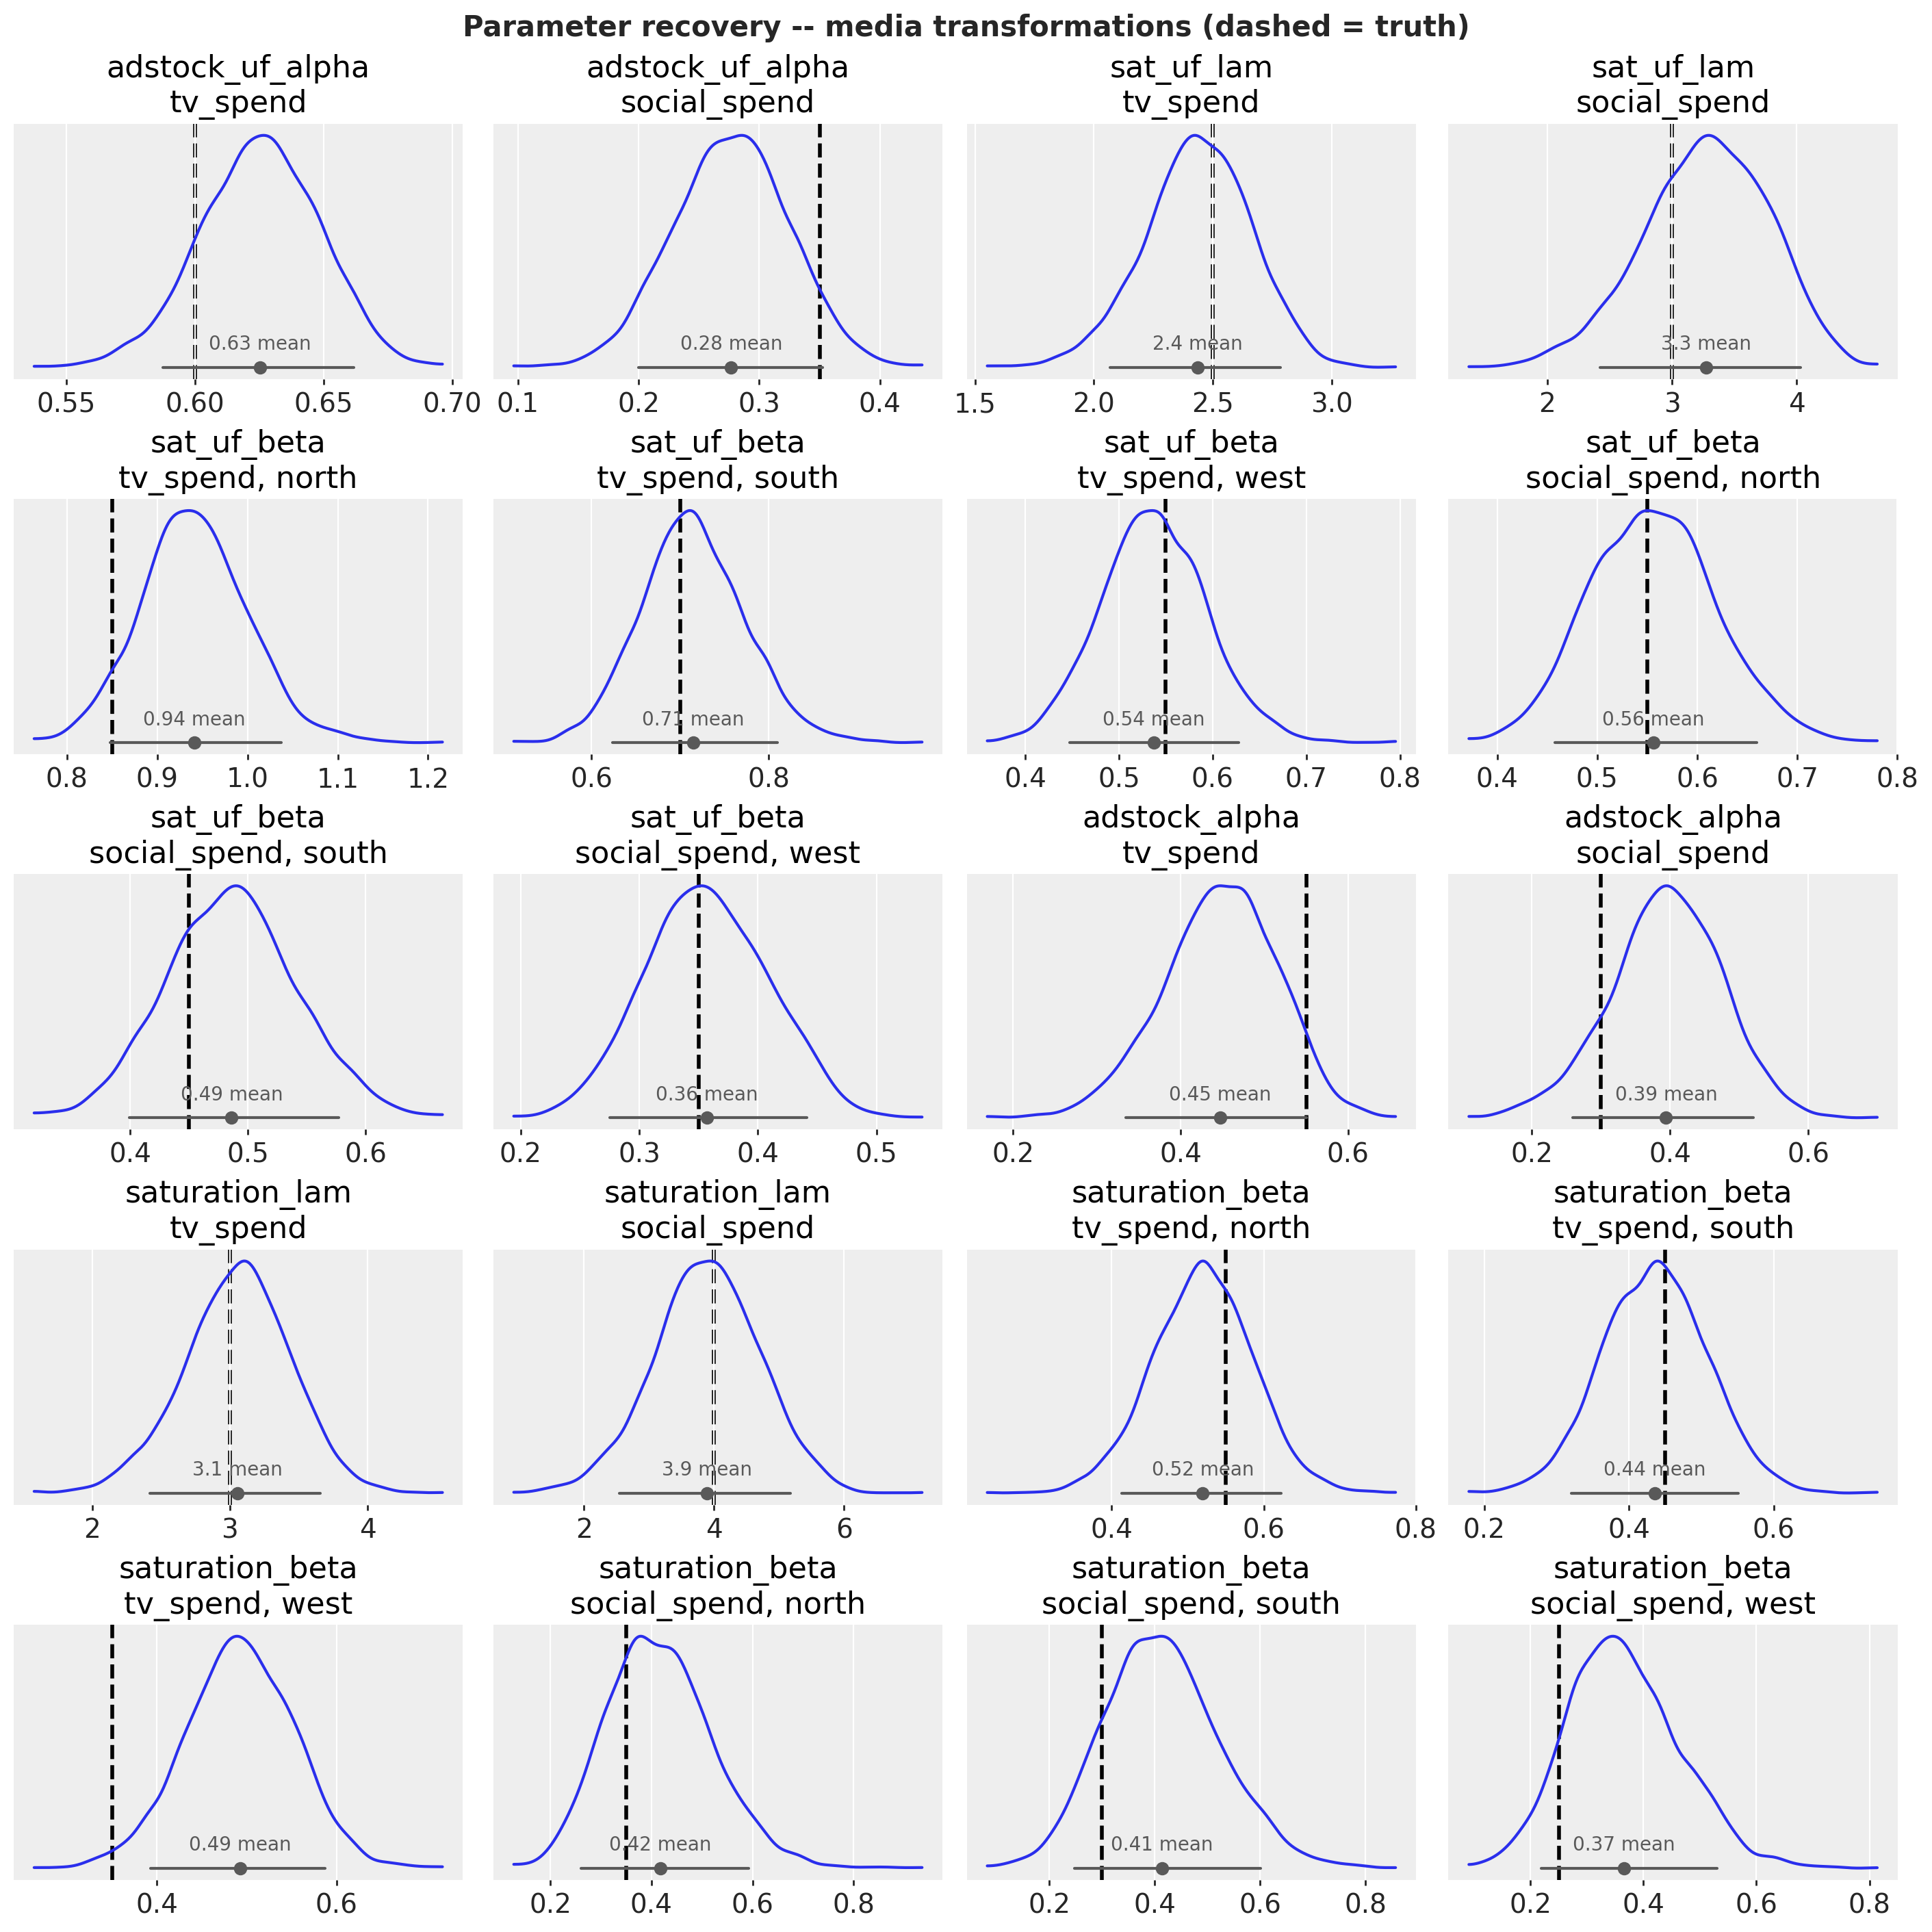

In [39]:
recovery_plot(
    [
        "adstock_uf_alpha",
        "sat_uf_lam",
        "sat_uf_beta",
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    "Parameter recovery -- media transformations (dashed = truth)",
    (14, 14),
);

Twenty KDE panels are good for shapes and bad for checking claims, so here is the
same information as numbers -- posterior mean, 94% HDI, truth, and whether the
interval covers it -- for every parameter in the two figures:

In [40]:
recovery_vars = [
    "funnel_baseline",
    "funnel_gamma",
    "funnel_lambda",
    "funnel_kappa",
    "adstock_lf_alpha",
    "sat_lf_lam",
    "sat_lf_beta",
    "adstock_uf_alpha",
    "sat_uf_lam",
    "sat_uf_beta",
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
]

records = []
for var in recovery_vars:
    draws = posterior_on_true_scale[var]
    truth_da = truth_dataset([var])[var]
    lo, hi = hdi_bounds(draws)
    mean = draws.mean(dim=["chain", "draw"])
    if truth_da.ndim == 0:
        cells = [((), float(truth_da))]
    else:
        cells = [
            (idx, float(truth_da.sel(dict(zip(truth_da.dims, idx, strict=True)))))
            for idx in pd.MultiIndex.from_product(
                [truth_da[d].values for d in truth_da.dims]
            )
        ]
    for idx, truth_value in cells:
        sel = dict(zip(truth_da.dims, idx, strict=True))
        lo_v, hi_v = float(lo.sel(sel)), float(hi.sel(sel))
        records.append(
            {
                "parameter": var,
                "cell": ", ".join(map(str, idx)) or "—",
                "mean": float(mean.sel(sel)),
                "hdi 3%": lo_v,
                "hdi 97%": hi_v,
                "true": truth_value,
                "covered": lo_v <= truth_value <= hi_v,
            }
        )

recovery_table = pd.DataFrame(records).set_index(["parameter", "cell"])
n_covered = int(recovery_table["covered"].sum())
print(f"covered: {n_covered}/{len(recovery_table)} parameter cells")

rel_err = (recovery_table["mean"] - recovery_table["true"]).abs() / recovery_table[
    "true"
].abs()
for _geo in geos:
    in_geo = recovery_table.index.get_level_values("cell").str.contains(_geo)
    print(f"mean relative |error|, {_geo}-indexed cells: {rel_err[in_geo].mean():.1%}")
recovery_table.style.format(
    {"mean": "{:.3f}", "hdi 3%": "{:.3f}", "hdi 97%": "{:.3f}", "true": "{:.3f}"}
).map(
    lambda v: (
        f"background-color: {'#c8e6c9' if v else '#ffcdd2'}"
        if isinstance(v, (bool, np.bool_))
        else ""
    )
)

covered: 36/37 parameter cells
mean relative |error|, north-indexed cells: 8.9%
mean relative |error|, south-indexed cells: 9.9%
mean relative |error|, west-indexed cells: 17.8%


These are looser than the funnel-side parameters -- compare the interval widths
in the table above -- and for a reason worth naming: both the direct and the
indirect path originate at the same upper-funnel spend, so how much of the
response belongs to each is only weakly identified parameter by parameter. The
trade-offs are not directionless, though. Two patterns are worth carrying
forward.

**Channel: a coherent social-side tilt.** Social's amplitude runs high in all
six of its cells -- mildly on the demand path (+1% to +8%), strongly on the
direct path (+19% to +46%). Of social's four *pooled* parameters, the
direct-path pair pushes the same amplitude-inflating way (`adstock_alpha` 0.394
against a true 0.300, `saturation_lam` 3.888 against 4.000) while the
demand-path pair leans against it (`adstock_uf_alpha` 0.277 against 0.350,
`sat_uf_lam` 3.273 against 3.000). Because pooled parameters are shared across
geos, this is best read as **one tilt propagated to three geos** rather than as
independent misses -- the geo cells are not independent evidence, and the same
tilt resurfaces in the bias tables below.

**Geo: `west` is hardest by construction.** The mean relative error printed
above the table nearly doubles from `north` and `south` (8.9%/9.9%) to `west`
(17.8%), and the one cell of 37 that escapes its interval is
`saturation_beta[west, tv_spend]` (+41%). The gradient is built into the DGP:
the observation noise `y_sigma` is flat at 0.04 while every component of the
target level scales with the region size multiplier (1.0/0.7/0.45), so `west`
runs the worst signal-to-noise in the panel. Keep that in mind when the bias
tables put the funnel model's largest misses in `west` cells.

As in the basic notebook, what matters for a decision is the **total** effect,
and that survives these trade-offs largely intact, as we see next.

## Direct, indirect, and total effect per channel

We now reconstruct each channel's estimated decomposition. The direct path is the
base channel contribution. The indirect path is the mediated contribution
**minus** what it would be with that channel's spend set to zero -- the same
counterfactual we ran on the generative model, now on the posterior.

In [41]:
def counterfactual_indirect(channel: str) -> dict[str, xr.DataArray]:
    """Posterior mediated contribution and induced LF spend attributable to ``channel``."""
    X_zero = X_upper.copy()
    X_zero[channel] = 0.0
    cf = funnel.sample_posterior_predictive(
        X_zero,
        extend_idata=False,
        combined=False,
        var_names=["funnel_effect_contribution_original_scale", "funnel_lf_spend"],
        random_seed=SEED[f"cf_post_{channel}"],
    )
    factual = funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    counterfactual = cf["funnel_effect_contribution_original_scale"]
    # Guard the plumbing: when X is a DataFrame the conversion keeps only the channel
    # columns, so the effect's own data variables (including lf_budget) correctly
    # retain their training values. If that ever stopped holding, the mediated
    # contribution would not move and the indirect effect would silently read zero.
    if float(counterfactual.mean()) >= float(factual.mean()):
        raise RuntimeError(
            f"zeroing {channel} did not reduce the mediated contribution -- "
            "the effect's data variables were probably overwritten"
        )
    return {
        "indirect": factual - counterfactual,
        # M* with the channel on minus M* with it off: the lower-funnel spend the
        # channel *induces*. Same units as observed lower_spend (the likelihood
        # ties them), which is what lets it enter a ROAS denominator later.
        "induced_spend": (
            funnel.idata.posterior["funnel_lf_spend"] - cf["funnel_lf_spend"]
        ),
    }


counterfactuals = {channel: counterfactual_indirect(channel) for channel in channels}

direct_post = funnel.idata.posterior["channel_contribution_original_scale"]
indirect_post = xr.concat(
    [counterfactuals[channel]["indirect"] for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
induced_spend_post = xr.concat(
    [counterfactuals[channel]["induced_spend"] for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
total_post = direct_post + indirect_post

Sampling: []


Output()

Sampling: []


Output()

min component: 0.03134417478178286


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/198638106.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


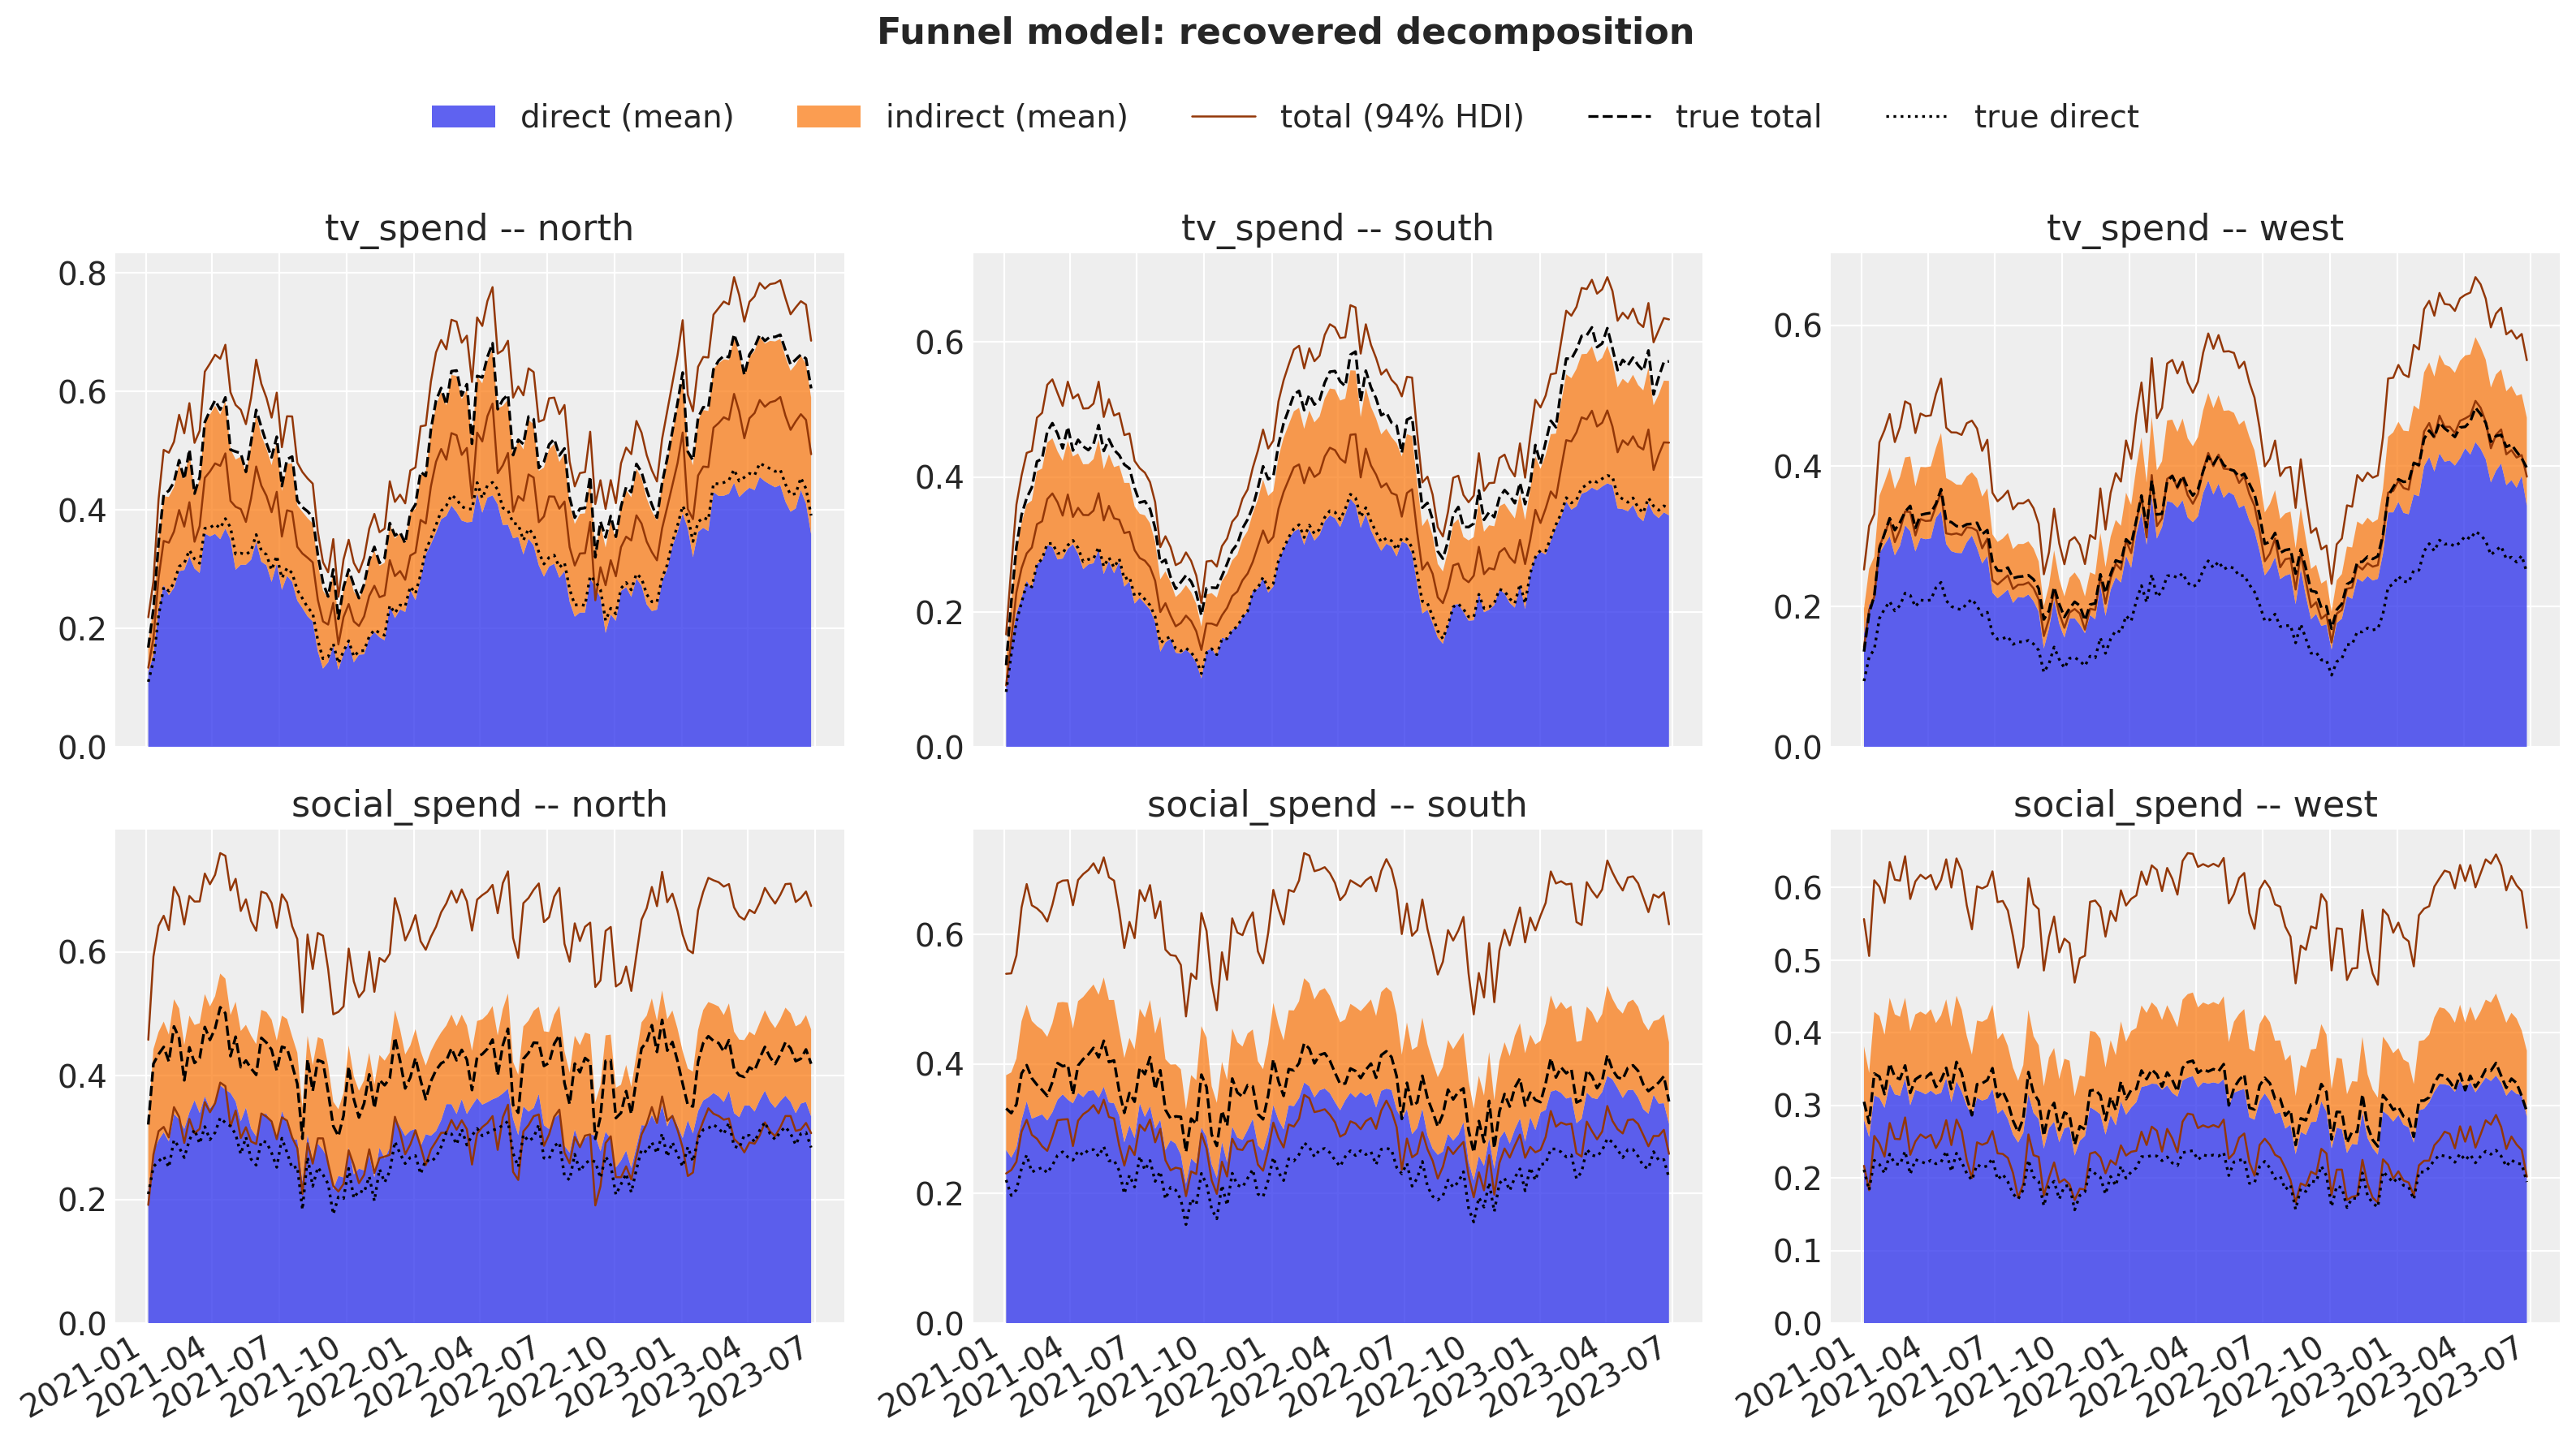

In [42]:
# Direct and indirect are stacked rather than overlaid: three overlapping HDI bands
# are unreadable, and stacking makes `direct + indirect = total` visible directly --
# the top edge of the stack *is* the total.
direct_mean = direct_post.mean(dim=["chain", "draw"])
indirect_mean = indirect_post.mean(dim=["chain", "draw"])
# `stackplot` does not complain about negative values, it just silently draws
# overlapping polygons whose top edge is no longer the total. Both components are
# non-negative here (monotone saturation, non-negative adstock weights), but check.
print("min component:", float(min(direct_mean.min(), indirect_mean.min())))

fig, axes = plt.subplots(
    nrows=len(channels), ncols=len(geos), figsize=(16, 9), sharex=True
)
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        ax.stackplot(
            date_range,
            direct_mean.sel(sel),
            indirect_mean.sel(sel),
            labels=["direct (mean)", "indirect (mean)"],
            colors=["C0", "C1"],
            alpha=0.75,
        )
        # The total's uncertainty is drawn as bounding lines rather than a filled
        # band: a translucent fill over the stack tints both components and makes
        # the decomposition harder to read, not easier.
        lo, hi = hdi_bounds(total_post.sel(sel))
        ax.plot(date_range, lo, color="C4", lw=0.9, label="total (94% HDI)")
        ax.plot(date_range, hi, color="C4", lw=0.9)
        ax.plot(
            date_range,
            data["total_true"].sel(sel),
            color="black",
            linestyle="--",
            lw=1.2,
            label="true total",
        )
        ax.plot(
            date_range,
            data["direct_true"].sel(sel),
            color="black",
            linestyle=":",
            lw=1.2,
            label="true direct",
        )
        ax.set_title(f"{channel} -- {geo}")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=5)
fig.suptitle("Funnel model: recovered decomposition", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.9))

The stack edge is a posterior *mean* while the band is an HDI, so the two need not
be concentric. The point of the figure is the split: how much of each channel's
contribution travels directly versus through lower-funnel spend, against the two
black reference lines.

## Head-to-head: the bias from ignoring the funnel

Finally we compare the six models on the quantity a budget decision actually
turns on -- the **total contribution of each upper-funnel channel**. For the naive
models the channel contribution is already the counterfactual versus zero spend.
For the funnel model we use direct plus the counterfactual indirect effect.

The rows are grouped **by estimand**, following the d-separation analysis: the
models above the separator answer (or claim to answer) the total-effect question;
`Naive A` sits below it with the funnel model's direct path, because the direct
effect is the question it actually answers. Every bias annotation names its
benchmark.

In [43]:
def total_contribution(model: MMM, channel: str) -> xr.DataArray:
    """Mean-over-time total contribution of ``channel`` for a naive model."""
    return (
        model.idata.posterior["channel_contribution_original_scale"]
        .sel(channel=channel)
        .mean(dim="date")
    )


estimates = {
    "Naive B (mediator omitted)": lambda ch: total_contribution(naive_b, ch),
    "Naive B+ (demand as control)": lambda ch: total_contribution(naive_bplus, ch),
    "Naive B++ (trend as control)": lambda ch: total_contribution(naive_bpp, ch),
    "Naive C (indicator as channel)": lambda ch: total_contribution(naive_c, ch),
    "Funnel (total)": lambda ch: total_post.sel(channel=ch).mean(dim="date"),
    "Naive A (mediator as channel)": lambda ch: total_contribution(naive_a, ch),
    "Funnel (direct only)": lambda ch: direct_post.sel(channel=ch).mean(dim="date"),
}
CONTRIBUTION_BENCHMARKS = {
    "Naive A (mediator as channel)": "direct",
    "Funnel (direct only)": "direct",
}
N_TOTAL_ROWS = 5  # rows above the estimand separator

truth_mean = data["total_true"].mean("date")
direct_truth_mean = data["direct_true"].mean("date")

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/3498357602.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


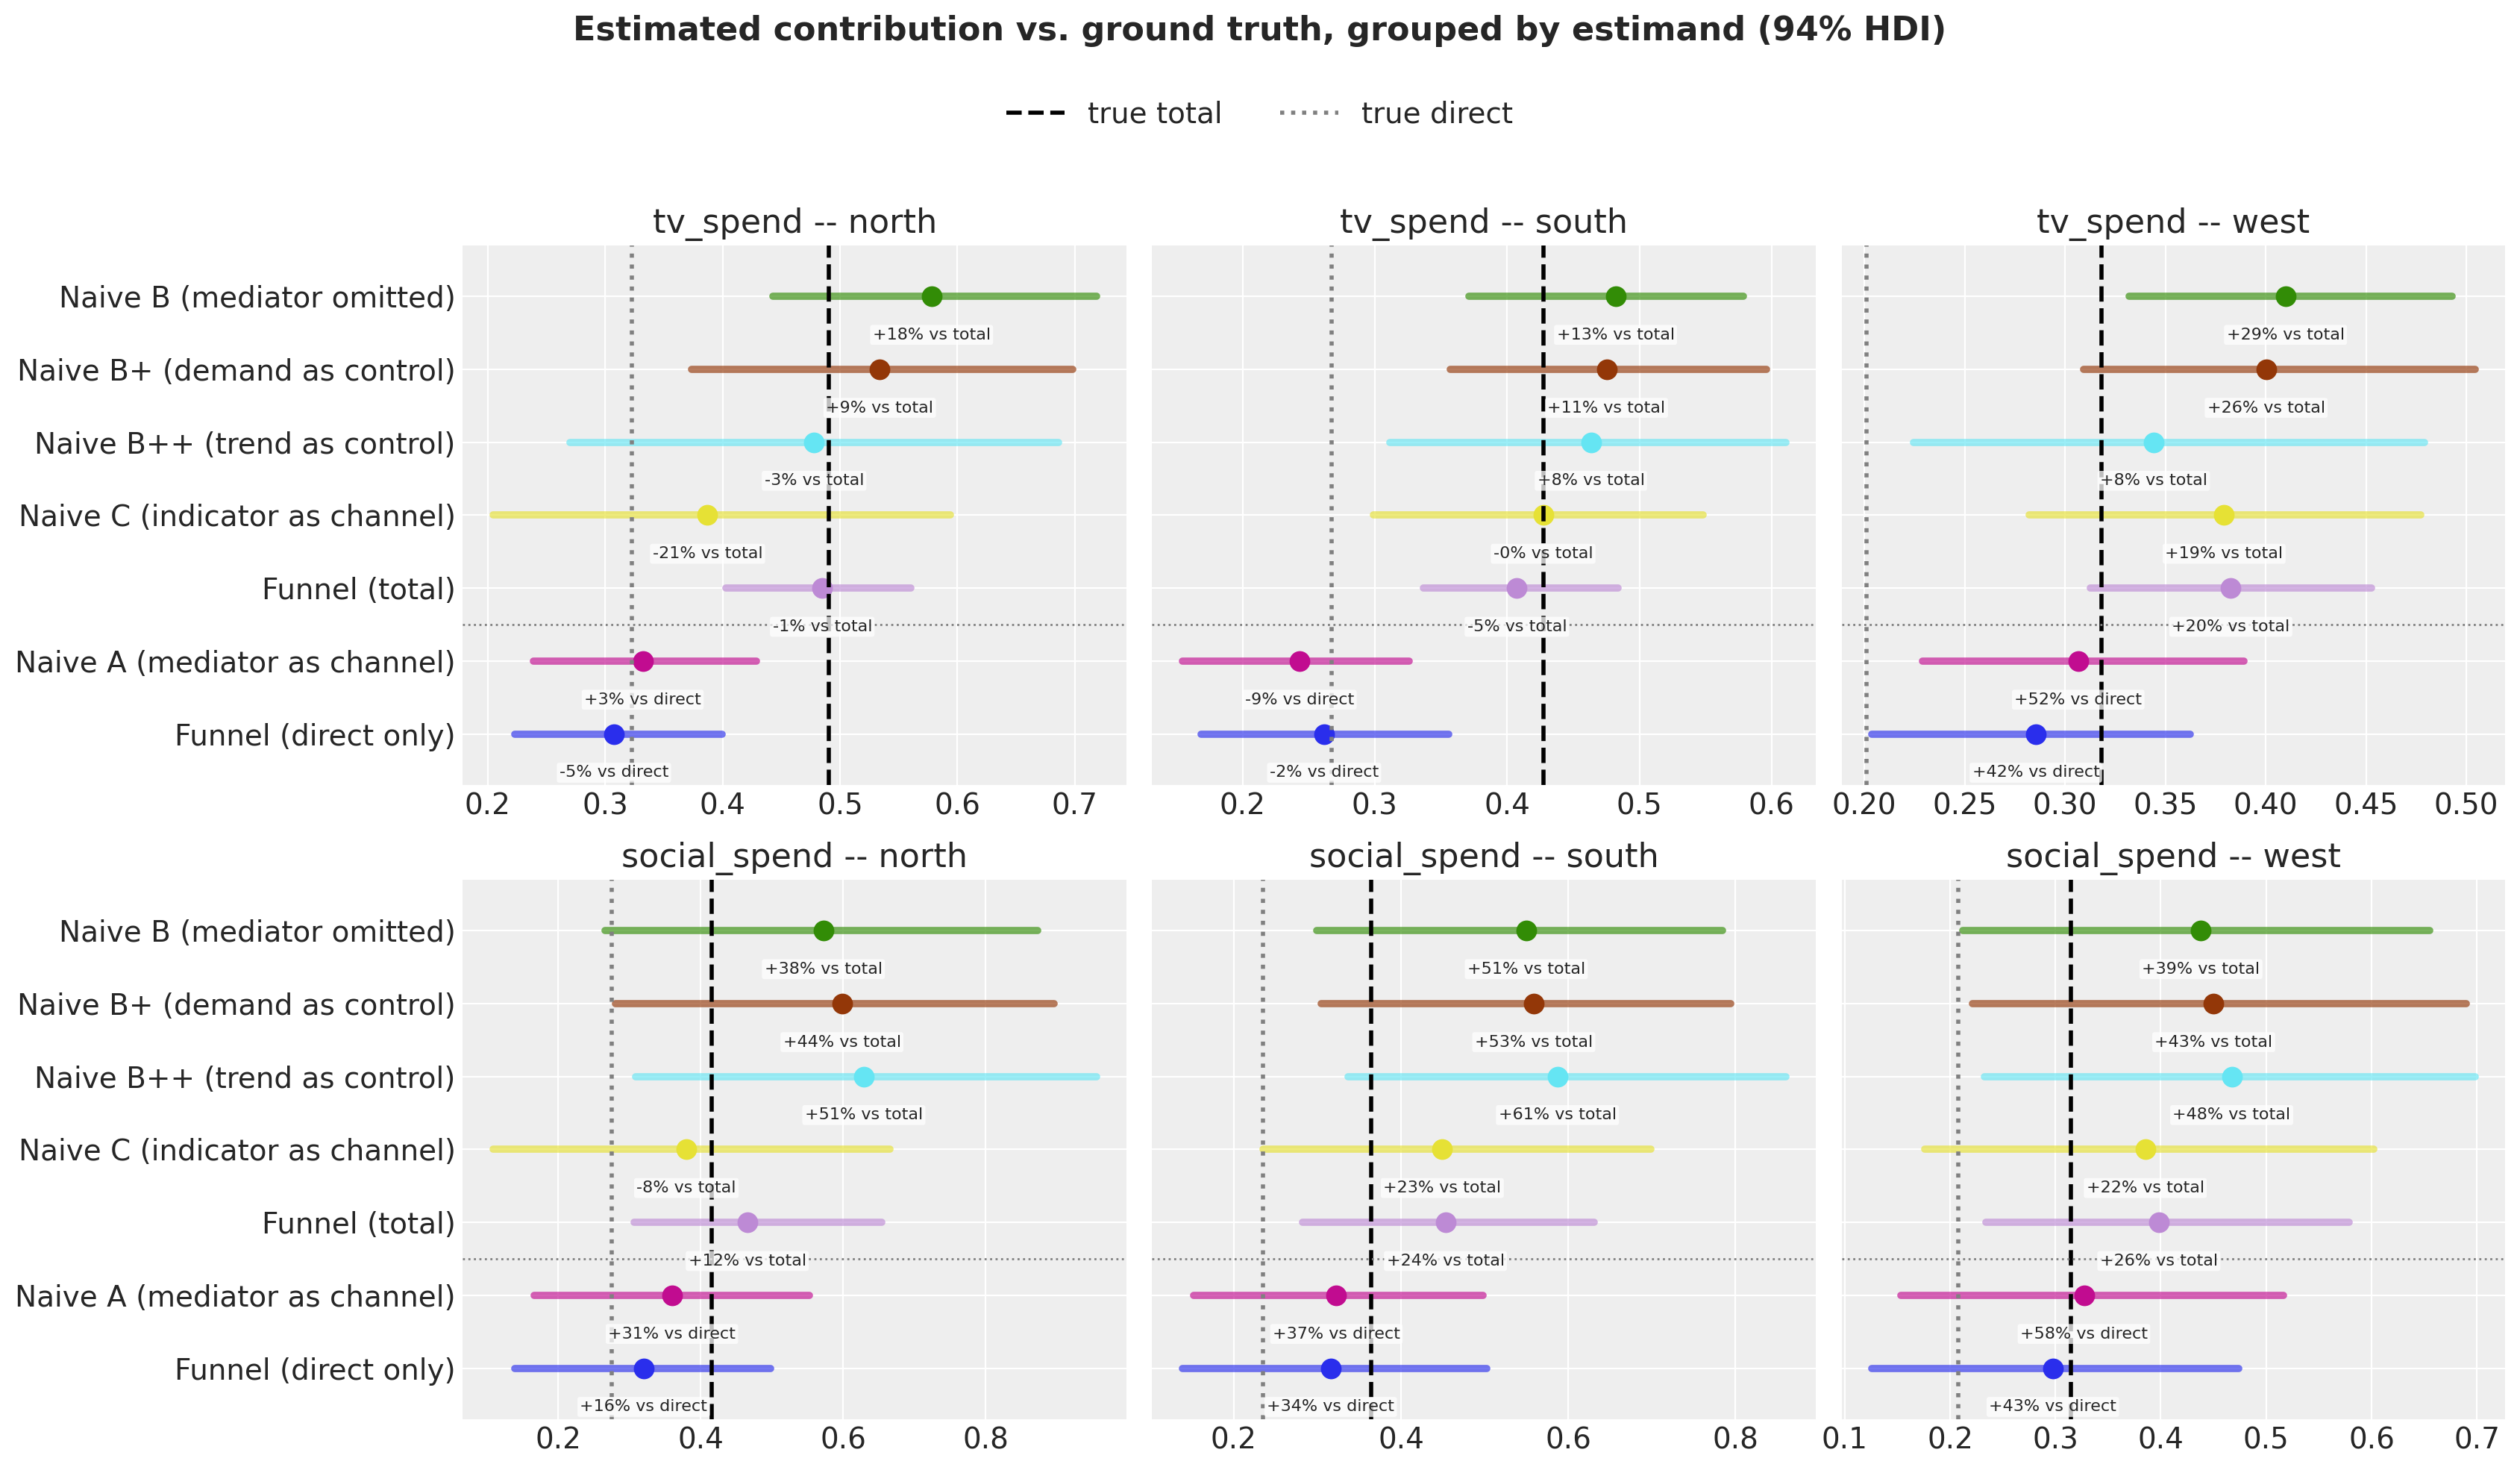

In [44]:
# Seven intervals plus two reference lines per panel is at the edge of
# legibility; the tables further below carry the same numbers in quotable form.
fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 10))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: est(channel).sel(geo=geo) for label, est in estimates.items()},
            reference={
                "total": (float(truth_mean.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(direct_truth_mean.sel(sel)), TRUE_STYLE["direct"]),
            },
            benchmarks=CONTRIBUTION_BENCHMARKS,
        )
        ax.axhline(N_TOTAL_ROWS - 0.5, color="gray", linestyle=":", lw=1)
        ax.set_title(f"{channel} -- {geo}")
        ax.tick_params(labelleft=col == 0)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "Estimated contribution vs. ground truth, grouped by estimand (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.9))

Each verdict from the d-separation table now has an empirical face -- and the
two channels put two different failure mechanisms on display.

**Naive B overstates TV, and the trend is why.** TV -- the channel whose
residual correlation with category demand survived the seasonal projection at
+0.56 to +0.61 -- comes out overstated in every geo (+13% to +29%). This is
textbook confounding: trending category demand, routed through the mediator
into the target, credited to the one regressor that also trends.

**Both candidate fixes do repair TV -- and the graph's ranking of them is
inverted.** `Naive B++` conditions on the trend itself, exactly where the
graph put one of the two forks, and its TV estimates land within a few points of
the truth (-3% to +8%). `Naive B+` conditions downstream on the category index --
the specification the graph nominated, because it blocks the noise fork too --
and recovers only part of the same correction (TV at +9% to +26%). So the
adjustment set with the *weaker* formal credential does the better empirical job
here: its linear control competes with the flexible response curves for the same
variance, and, as the arithmetic below shows, a trend the curves cannot mimic is
won more decisively than a category index they can. Graph validity ranks
specifications only up to functional form; it never promised more.

**Social is the twist: overstated by +38% to +51% in Naive B -- and both fixes
make it *worse* (+43% to +61%).** Social's backdoor is graphically open, exactly
like TV's -- $t \to U_2$ is in the graph, and the symmetry check above says the
verdicts are identical with social as the treatment -- but it is numerically
immaterial: its residual correlation with demand was at noise level
($|r| \le 0.16$) before any fix was applied. So its overstatement is not
confounding in any quantitative sense. It is the **omitted mediated path**: the
demand pool that upper-funnel spend fills is missing from every naive model, so
its contribution has to land somewhere -- and it lands disproportionately on
social. *Why* it prefers social is a claim about where the likelihood puts the
mass, so we price it in target units below rather than leave it as an assertion.
No adjustment set can address the misallocation, because no material backdoor is
involved: the model family simply cannot represent one shared saturating pool as
a sum of per-channel curves. D-separation speaks about which variables you need,
never about how they must enter -- and, being binary, it cannot tell you that
one open backdoor is worth 0.6 and the other 0.1.

So the graph's guess from the correlation table was half right. The bias the
graph could see *and* the measurement said was material -- TV's open
backdoor -- did land on TV, and adjustment removed it. The larger bias landed on
the channel whose backdoor was numerically empty, and adjustment could not touch
it.

**Naive C is a diluted Naive A with less predictable symptoms.** Branded search
is a near-perfect proxy for latent demand, so conditioning on it partially
blocks the mediated path -- but only partially, and the leftover lands
unevenly: TV understated by about a fifth in `north` (-21%), essentially exact in
`south` (-0.0%), yet overstated by a fifth in `west` (+19%); social understated
by nine points in `north` (-8.5%) and overstated by roughly a quarter in the two
smaller geos (+23%, +22%). All six cells wrong by a different amount, and with
no consistent sign. A model that is wrong differently in every cell is arguably
more dangerous than one that is wrong the same way everywhere.

**Naive A, read against its own estimand, is a different model.** Against the
total effect it understates TV badly -- the blocked indirect path. Against the
true *direct* effect (the dotted line, its annotation benchmark below the
separator) it covers five of six cells, though with a mean error near 32%: a
*rough* direct-effect estimator, not a clean one -- the d-separation analysis
said as much, since it conditions on the noisy observation $M$ rather than the
structural $M^{*}$. The lesson is not "Naive A is broken" but "Naive A answers
a question nobody asked it, and answers it only approximately".

A third contributor is not a mechanism at all but a property of this draw: the
pooled social-side tilt from the recovery table, which *every* model inherits,
the funnel model included. It is not a specification failure and no
specification choice removes it -- but it sits inside social's numbers above,
so the absolute-bias table below sizes it and reads the two real mechanisms net
of it.

None of these biases is a uniform shift you could correct with a fudge factor,
and the two mechanisms respond to *different* remedies -- one to a control
column, the other only to modelling the funnel. We quantify all of it below,
where a single number per model replaces eyeballing these intervals.

The claim that Naive B+'s control wins only part of the shared trend variance
deserves its arithmetic:

In [45]:
gamma_control = naive_bplus.idata.posterior["gamma_control"].sel(
    control="category_demand"
)
bplus_scale = naive_bplus.idata.constant_data["target_scale"]

# What *should* this coefficient be? In the true DGP a sustained +1 in category
# demand raises latent demand by gamma_g, hence M* by gamma_g (the geometric
# adstock is normalized, so a sustained shift passes through with total weight
# one), and the target by gamma_g times the slope of the true conversion curve
# at its operating point. LogisticSaturation is beta * tanh(lam * x / 2), so
# that slope is beta * (lam / 2) / cosh(lam * x / 2)^2, averaged pointwise
# over the adstocked M* series (the mean of the slope, not the slope at the
# mean, so the anchor carries no Jensen gap). Control columns enter unscaled
# while mu is on the scaled-target scale, so the posterior is multiplied by
# `target_scale` to land on the same original-scale units as the truth.
adstock_weights = np.power(true["adstock_lf_alpha"][None, :], np.arange(l_max)[:, None])
adstock_weights /= adstock_weights.sum(axis=0)
mstar = data["lf_spend_true"].transpose("date", "geo").to_numpy()
adstocked_mstar = np.stack(
    [
        np.convolve(mstar[:, g], adstock_weights[:, g])[: len(mstar)]
        for g in range(len(geos))
    ],
    axis=1,
)
lam_lf = float(true["sat_lf_lam"])
pointwise_slope = (
    true["sat_lf_beta"] * (lam_lf / 2) / np.cosh(lam_lf * adstocked_mstar / 2) ** 2
)
conversion_slope = pointwise_slope.mean(axis=0)
implied_true_slope = true["funnel_gamma"] * conversion_slope

gamma_scaled = gamma_control * bplus_scale
post_mean = gamma_scaled.mean(dim=["chain", "draw"]).to_series()
post_sd = gamma_scaled.std(dim=["chain", "draw"]).to_series()
implied = pd.Series(implied_true_slope, index=pd.Index(geos, name="geo"))

# The default control prior is Normal(0, 2) on the *scaled* target, so its sd in
# the original units the implied slope lives in is 2 * target_scale -- the only
# currency in which "the prior is wide relative to the truth" can be checked.
prior_sd = pd.Series(
    np.broadcast_to(2.0 * bplus_scale.to_numpy(), (len(geos),)),
    index=pd.Index(geos, name="geo"),
)

summary = pd.DataFrame(
    {
        "posterior mean (target scale)": post_mean,
        "implied true slope": implied,
        "posterior sd (target scale)": post_sd,
        "sd from implied": (post_mean - implied).abs() / post_sd,
        "sd from zero": post_mean.abs() / post_sd,
        "prior sd (target scale)": prior_sd,
        "prior sd / implied": prior_sd / implied,
    }
)
summary.style.format(
    {col: "{:.3f}" for col in summary.columns} | {"prior sd / implied": "{:.0f}x"}
)

,posterior mean (target scale),implied true slope,posterior sd (target scale),sd from implied,sd from zero,prior sd (target scale),prior sd / implied
geo,,,,,,,
north,0.093,0.114,0.063,0.320,1.477,4.311,38x
south,0.040,0.116,0.079,0.958,0.512,3.527,30x
west,0.084,0.098,0.119,0.121,0.704,2.747,28x


The arithmetic explains why `Naive B+` recovers only part of TV's correction.
The *correct* linear effect of a unit of category demand on the target is
small -- about a tenth of a unit, the implied-slope column -- because a unit of
demand converts through the saturating lower-funnel curve. The posterior means
sit below that implied slope in every geo, within about one posterior sd of it;
but they also sit within one and a half posterior sd of **zero**. That last
column is the honest one: at this sample size the diagnostic cannot
distinguish a control doing its full job from one doing half of it -- or, in
`south`, from one doing nothing. (This is also why we do not read the
posterior-to-prior shrinkage as strength here the way we did for $\lambda$. The
default $\mathrm{Normal}(0, 2)$ control prior lives on the *scaled* target,
so the comparison has to be made in one currency: in original units its sd is
$2 \cdot \texttt{target\_scale}$, tens of times wider than the implied slope --
the last column above. A posterior that has shrunk to a few percent of *that*
is still wide relative to the number it is trying to measure.)

The fit resolves what the coefficient alone cannot. The control and the
flexible TV response curve compete for the same trend variance; the posterior
splits it between them, and B+'s TV estimates land part of the way from Naive
B's toward Naive B++'s. The trend control in B++ wins the same contest more
decisively -- a curve has to *bend* to mimic a trend, while $t$ enters
linearly -- which is why the cheaper, only-conditionally-valid fix closes TV's
gap more fully than the one the graph nominated. Both observations say the same
thing: a formally valid control can be estimated about right and still be
under-deployed, because validity says nothing about how strongly the likelihood
will lean on a linear term when nonlinear alternatives can partially mimic it.
What neither control touches, as the tables below quantify, is the social
side -- where the backdoor was open on the graph but empty in the measurement,
so there was no material confounding for either of them to remove.

## ROAS, nationally and per geo

Budget decisions key off return on ad spend, so let us express the same comparison
that way. All estimates use the **same** definition -- contribution summed over
the observed weeks, divided by spend over those same weeks -- so that any difference
between them is structural rather than definitional.

One convention needs naming before any number is read. The standard rows below
divide by **upper-funnel spend alone**: they report return per upper-funnel
dollar, *treating the lower-funnel spend that upper-funnel activity induces as
free*. That is not an innocent choice here -- the coefficient on $D$ in the
$M^{*}$ equation is exactly one, so every unit of demand a channel creates is a
unit of incremental lower-funnel spend someone has to authorise, and with roughly
a third of each channel's effect travelling that path it is not a rounding issue
either. The funnel model is the only one that can *price* that induced spend, so
alongside `Funnel (total)` we also report a row that adds it to the denominator:
$\Delta y \,/\, (\text{channel spend} + \Delta M^{*})$.

One bookkeeping assumption underlies that row: all spend series are denominated
in the **same currency**, so upper-funnel dollars and induced lower-funnel
dollars can be added in one denominator. On real data that is automatic. In
this synthetic DGP the "exchange rate" between a TV unit and a lower-funnel
unit is set by each series' max-normalization -- exactly as arbitrary as it
sounds -- so read the induced-spend row as a demonstration of the *accounting*,
not of a meaningful price.

In [46]:
spend = data[channels].to_array("channel").sum("date")


def roas_from(contribution: xr.DataArray) -> xr.DataArray:
    """All-time ROAS: summed contribution over summed spend, per channel and geo."""
    return contribution.sel(channel=channels).sum(dim="date") / spend


def direct_roas(model: MMM) -> xr.DataArray:
    """Direct-path ROAS from a model's own channel contributions."""
    return roas_from(model.idata.posterior["channel_contribution_original_scale"])


# Denominator including each channel's induced lower-funnel spend. The denominator
# is itself a posterior quantity: the model estimates how much M* the channel moved.
denom_incl = spend + induced_spend_post.sum(dim="date")

roas = {
    "Naive B (mediator omitted)": direct_roas(naive_b),
    "Naive B+ (demand as control)": direct_roas(naive_bplus),
    "Naive B++ (trend as control)": direct_roas(naive_bpp),
    "Naive C (indicator as channel)": direct_roas(naive_c),
    "Funnel (total)": roas_from(total_post),
    "Funnel (total / all incremental spend)": (
        total_post.sel(channel=channels).sum(dim="date") / denom_incl
    ),
    "Naive A (mediator as channel)": direct_roas(naive_a),
    "Funnel (direct only)": roas_from(direct_post),
}
ROAS_BENCHMARKS = {
    "Funnel (total / all incremental spend)": "total incl. LF",
    "Naive A (mediator as channel)": "direct",
    "Funnel (direct only)": "direct",
}

true_total_roas = data["total_true"].sum("date") / spend
true_direct_roas = data["direct_true"].sum("date") / spend
true_denom_incl = spend + data["induced_spend_true"].sum("date")
true_incl_roas = data["total_true"].sum("date") / true_denom_incl

```{note}
`mmm.incrementality.contribution_over_spend(frequency="all_time")` computes the
same quantity, and the two columns below agree to every printed digit. That
agreement is **necessary, not lucky**: the built-in's `include_carryover=True`
option extends each evaluation window by `l_max` periods, but the extended mask is
intersected with the dates that exist -- and with `frequency="all_time"` the
window already ends at the last observation, so there is nothing to extend into.
The flag only bites when a window boundary falls *inside* the data, as the yearly
breakdown below shows. Separately, the built-in only sees `channel_contribution`,
so for the funnel model it returns the **direct** path and misses the mediated
one entirely -- that part is a genuine limitation to keep in mind.
```

In [47]:
builtin_direct = funnel.incrementality.contribution_over_spend(
    frequency="all_time"
).sel(channel=channels)

pd.DataFrame(
    {
        "manual (in-sample window)": roas["Funnel (direct only)"]
        .mean(dim=["chain", "draw"])
        .transpose("channel", "geo")
        .to_series(),
        "incrementality, all_time": builtin_direct.mean(dim=["chain", "draw"])
        .transpose("channel", "geo")
        .to_series(),
    }
).style.format("{:.4f}")

To see `include_carryover` actually doing something, ask for **yearly** windows.
Now 2021 and 2022 end mid-data, and the carryover option credits each year with
the adstock its spend leaves in flight during the next `l_max` weeks:

In [48]:
# A fresh Generator with the same named seed for both calls, so they subsample
# the same posterior draws and the difference column is not polluted by Monte
# Carlo noise.
yearly_with = funnel.incrementality.contribution_over_spend(
    frequency="yearly",
    num_samples=500,
    random_state=np.random.default_rng(SEED["yearly_incrementality"]),
)
yearly_without = funnel.incrementality.contribution_over_spend(
    frequency="yearly",
    include_carryover=False,
    num_samples=500,
    random_state=np.random.default_rng(SEED["yearly_incrementality"]),
)

yearly = pd.DataFrame(
    {
        "with carryover": yearly_with.mean(dim=["chain", "draw"])
        .sel(channel=channels)
        .to_series(),
        "without": yearly_without.mean(dim=["chain", "draw"])
        .sel(channel=channels)
        .to_series(),
    }
)
yearly["difference"] = yearly["with carryover"] - yearly["without"]
yearly.style.format("{:.4f}")

The interior years differ, as they should. Two footnotes stop this table from
being misread. The **final, partial year ends with the data**, so its two columns
are identical for exactly the reason the `all_time` columns were -- there are no
later dates to extend into. And with carryover on, the yearly windows **overlap**
(each year's carryout weeks lie inside the next year's window), so the yearly
figures deliberately do not aggregate back to the all-time number.

### Nationally

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/2844912860.py:42: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


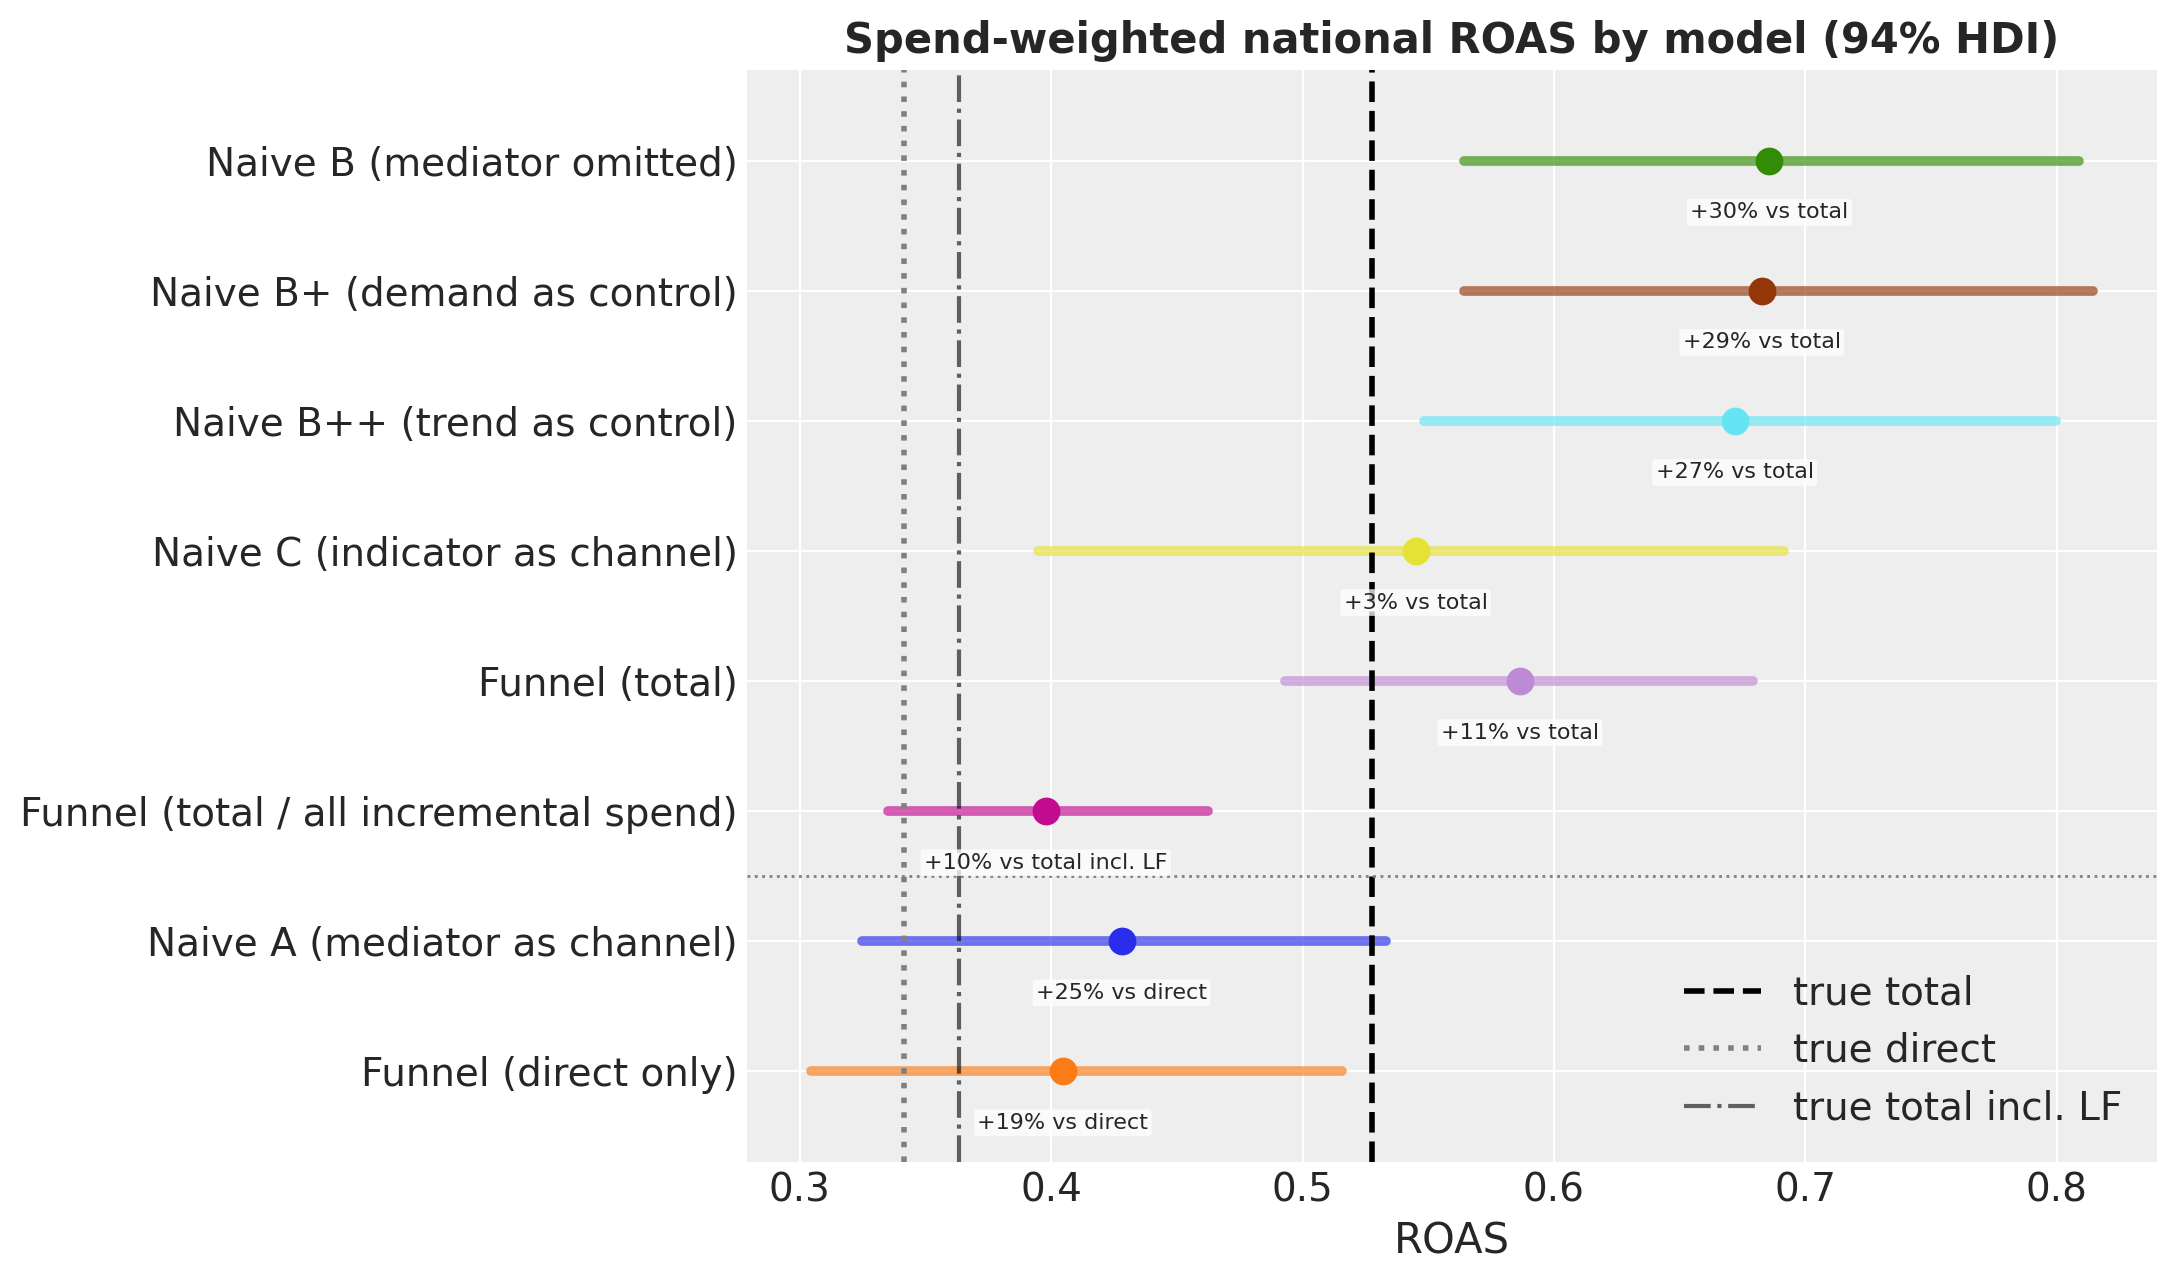

In [49]:
# National = total contribution over total spend; each row keeps its own
# denominator, so the induced-spend row is weighted by spend *plus* induced spend.
national = {
    label: (da * spend).sum("channel").sum("geo") / spend.sum()
    for label, da in roas.items()
    if label != "Funnel (total / all incremental spend)"
}
national["Funnel (total / all incremental spend)"] = (
    roas["Funnel (total / all incremental spend)"] * denom_incl
).sum(["channel", "geo"]) / denom_incl.sum(["channel", "geo"])
national = {label: national[label] for label in roas}  # restore row order

national_true_total = float((true_total_roas * spend).sum() / spend.sum())
national_true_direct = float((true_direct_roas * spend).sum() / spend.sum())
national_true_incl = float(
    (true_incl_roas * true_denom_incl).sum() / true_denom_incl.sum()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
forest_panel(
    ax,
    national,
    reference={
        "total": (national_true_total, TRUE_STYLE["total"]),
        "direct": (national_true_direct, TRUE_STYLE["direct"]),
        "total incl. LF": (
            national_true_incl,
            {"color": "black", "linestyle": "-.", "linewidth": 1.5, "alpha": 0.6},
        ),
    },
    benchmarks=ROAS_BENCHMARKS,
)
# Estimand separator: total-effect rows above, direct-effect rows below.
ax.axhline(len(national) - 2.5, color="gray", linestyle=":", lw=1)
ax.set_xlabel("ROAS")
ax.legend(loc="lower right")
ax.set_title(
    "Spend-weighted national ROAS by model (94% HDI)",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout()

The rows above the separator estimate a **total** effect. The first five are
annotated against the true total (dashed black); the sixth divides the same total
contribution by *all* the incremental money it took -- channel spend plus the
induced lower-funnel spend -- and is annotated against its own benchmark
(dash-dotted). The gap between the two funnel rows **is the price of the induced
spend**: the return per upper-funnel dollar and the return per *incremental*
dollar are different questions, and only a model that sees the funnel can answer
the second one at all.

Below the separator sit the two **direct**-effect rows, annotated against the
true direct ROAS (dotted grey) -- including `Naive A`, per the d-separation
analysis: this is the question it actually answers. Neither direct row sits
cleanly on the dotted line, and per cell their errors partly offset in the
national average -- the direct path inherits the same social-side inflation
visible in the recovery table. A correct decomposition is not a magic wand
against one dataset's noise; what it buys is the *right estimand* and honest
uncertainty around it.

Read as a budget input: the naive models disagree with the truth in different
directions, and nothing in the models themselves tells you which one you are
looking at.

### Per geo and channel

The national number averages over exactly the heterogeneity a geo panel exists to
expose, so it is worth breaking out. `contribution_over_spend` and our manual
version both return `(chain, draw, channel, geo)`, so no extra computation is
needed -- only a different view of it.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_97606/684534606.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


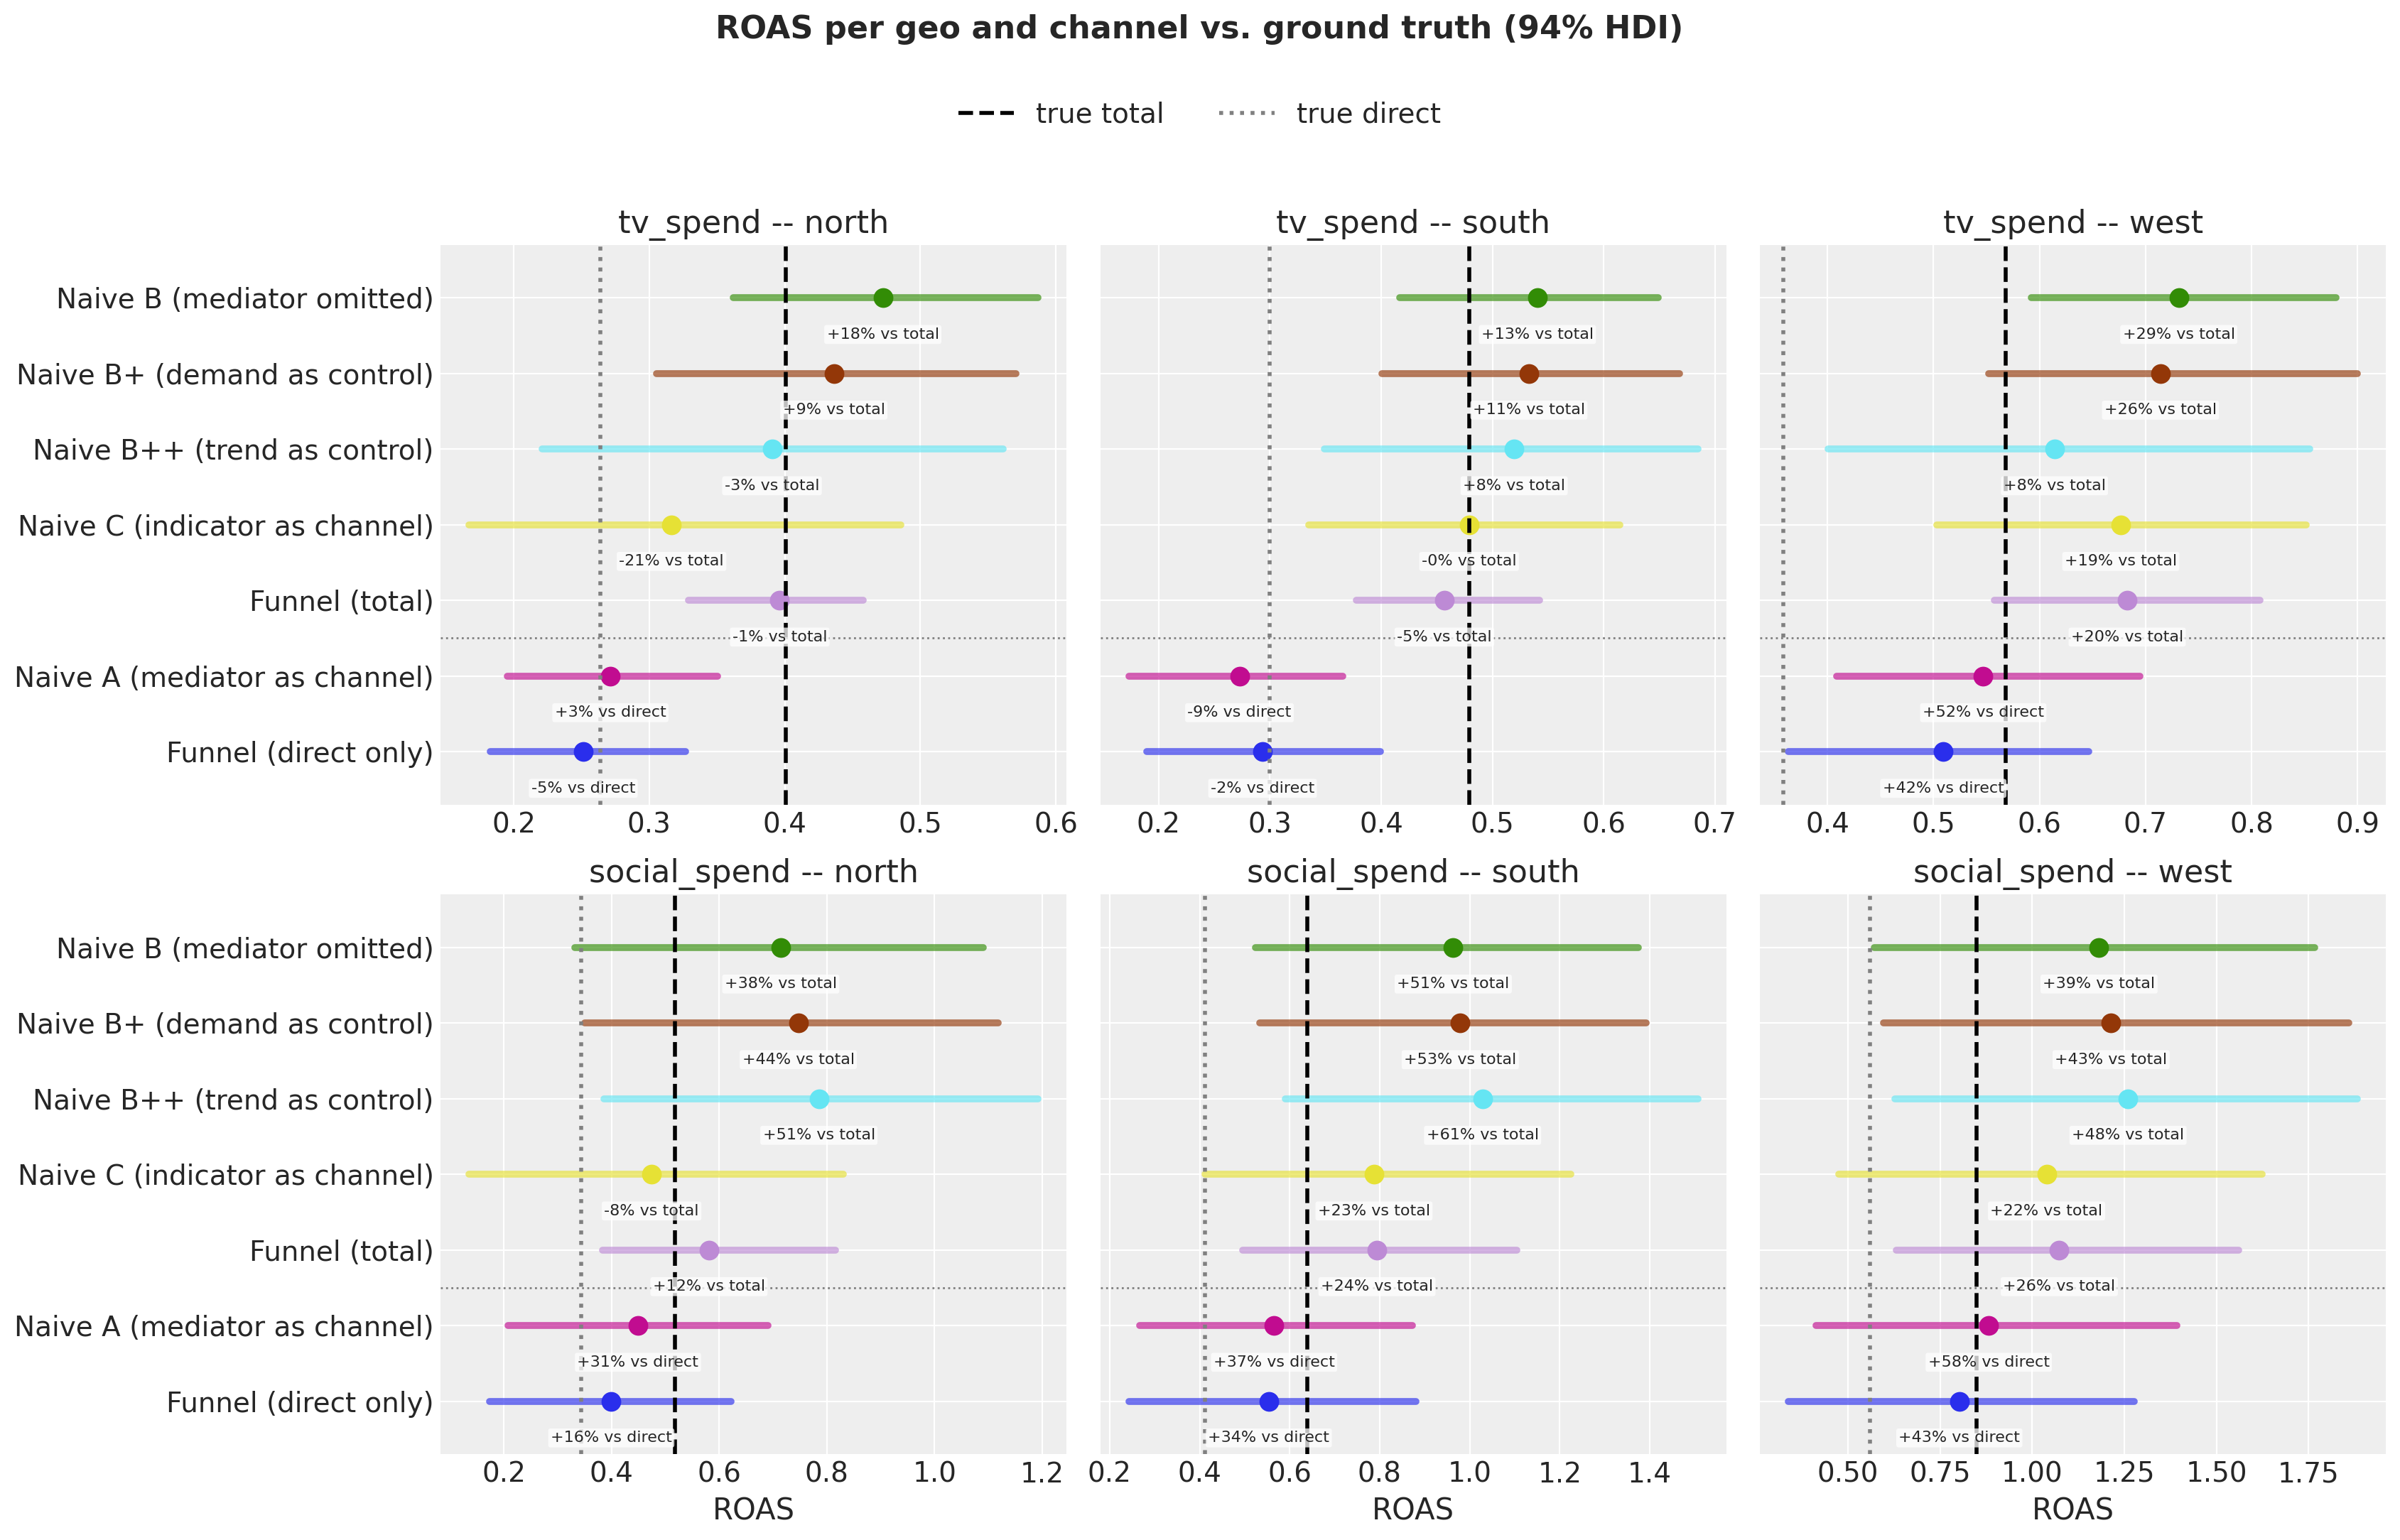

In [50]:
# The induced-spend row is national-only: per cell it would add yet another
# interval with its own benchmark line to eighteen already-busy panels.
geo_rows = {
    label: da
    for label, da in roas.items()
    if label != "Funnel (total / all incremental spend)"
}

fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 11))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: da.sel(sel) for label, da in geo_rows.items()},
            reference={
                "total": (float(true_total_roas.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(true_direct_roas.sel(sel)), TRUE_STYLE["direct"]),
            },
            benchmarks=ROAS_BENCHMARKS,
        )
        ax.axhline(len(geo_rows) - 2.5, color="gray", linestyle=":", lw=1)
        ax.set_title(f"{channel} -- {geo}")
        ax.tick_params(labelleft=col == 0)
        if row == len(channels) - 1:
            ax.set_xlabel("ROAS")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "ROAS per geo and channel vs. ground truth (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.9))

The same comparison as a table of levels, then as bias against the true total:

In [51]:
roas_summary = pd.DataFrame(
    {
        label: da.mean(dim=["chain", "draw"]).transpose("channel", "geo").to_series()
        for label, da in roas.items()
    }
)
roas_summary["true direct"] = true_direct_roas.transpose("channel", "geo").to_series()
roas_summary["true total"] = true_total_roas.transpose("channel", "geo").to_series()
roas_summary["true total incl. LF"] = true_incl_roas.transpose(
    "channel", "geo"
).to_series()
roas_summary.style.format("{:.3f}")

The bias table judges every column against the **true total**. For five of the
six that is their own estimand; `Naive A` is included on the same yardstick
deliberately, because "mediator as a channel" is how it gets used in practice --
its column shows the cost of *misreading* it as a total-effect estimate, and its
own estimand is scored separately below.

In [52]:
total_estimates = [
    "Naive A (mediator as channel)",
    "Naive B (mediator omitted)",
    "Naive B+ (demand as control)",
    "Naive B++ (trend as control)",
    "Naive C (indicator as channel)",
    "Funnel (total)",
]
bias = roas_summary[total_estimates].div(roas_summary["true total"], axis=0) - 1
bias.loc[("mean |error|", ""), :] = bias.abs().mean()
bias.style.background_gradient(
    cmap="RdBu_r", vmin=-0.5, vmax=0.5, subset=pd.IndexSlice[channels, :]
).format("{:+.1%}")

A percentage bias is a ratio, and the two channels do not share a
denominator. Before reading anything into the TV/social contrast, price the
same errors in **target units** -- estimated minus true *contribution*, which
is what a budget conversation would actually get wrong:

In [53]:
# (estimated - true) ROAS x spend: the contribution each column misreports.
spend_series = spend.transpose("channel", "geo").to_series()
true_contribution = (
    data["total_true"].sum("date").transpose("channel", "geo").to_series()
)

abs_bias = (
    roas_summary[total_estimates]
    .sub(roas_summary["true total"], axis=0)
    .mul(spend_series, axis=0)
)

by_channel = abs_bias.groupby(level="channel", sort=False).sum().loc[channels]
true_by_channel = (
    true_contribution.groupby(level="channel", sort=False).sum().loc[channels]
)

header = "".join(f"{channel:>16s}" for channel in channels)
print(f"{'summed over geos':38s}{header}")
print(
    f"{'true total contribution':38s}"
    + "".join(f"{true_by_channel[channel]:16.1f}" for channel in channels)
)
for label in total_estimates:
    print(
        f"{label:38s}"
        + "".join(f"{by_channel.loc[channel, label]:+16.1f}" for channel in channels)
    )

abs_bias.style.background_gradient(cmap="RdBu_r", vmin=-30, vmax=30).format("{:+.1f}")

summed over geos                              tv_spend    social_spend
true total contribution                          160.7           142.3
Naive A (mediator as channel)                    -46.1           -11.1
Naive B (mediator omitted)                       +30.4           +60.5
Naive B+ (demand as control)                     +22.5           +66.6
Naive B++ (trend as control)                      +6.4           +76.5
Naive C (indicator as channel)                    -5.5           +15.6
Funnel (total)                                    +5.0           +28.8


The denominators are not the story. In truth the two channels contribute
almost the same amount (161 against 142 -- social buys less spend but converts
it better), so a percentage comparison between them was close to fair already,
and the absolute table repeats the percentage table's verdict without the
escape hatch. `Naive B` misallocates about **twice** as much contribution onto
social as onto TV (+61 against +30); `Naive B++` -- the model that *fixes*
TV -- misallocates about **twelve times** as much (+77 against +6). The
likelihood really does prefer social; it is not an artifact of dividing by a
smaller number.

Two things follow that percentages could not show.

**A valid adjustment does not only remove bias, it moves some.** Going from
`Naive B` to `Naive B++` takes 24 units of contribution off TV and puts 16 back
onto social -- roughly two thirds of what the trend control removes from the
confounded channel reappears on the unconfounded one. With the mediated pool
still missing from the model, the contribution it represents has to be
attributed *somewhere*; closing the backdoor changes where, not whether.

**The funnel model sets the floor.** Its own social error is +29. That model
has the right structure, so its residual is the part of the social overshoot
that belongs to this draw -- the pooled social-side tilt from the recovery
table -- rather than to any conditioning choice. Read against that floor,
roughly half of `Naive B`'s +61 is tilt and half is omitted-mediator
misallocation; for `Naive B++` the split is about a third to two thirds. The
specification effect is the larger part in both, and it *grows* as the
adjustment sets become more valid -- which is the two-mechanism story stated in
units a budget owner would recognise.

A point estimate being off is one thing; being *confidently* off is worse. The
table below asks, for every geo and channel, whether each model's 94% HDI actually
contains the true total ROAS -- and how wide that interval had to be. One caveat
before reading it: these are six *correlated* cells from a *single* simulated
dataset, so treat the counts as a sanity check, not a calibration study -- actual
interval calibration needs replicate datasets, which is out of scope for a docs
example.

In [54]:
coverage_rows = []
for c in channels:
    for g in geos:
        truth = float(true_total_roas.sel(channel=c, geo=g))
        row = {}
        for label in total_estimates:
            lo, hi = hdi_bounds(roas[label].sel(channel=c, geo=g))
            row[(label, "covers")] = bool(float(lo) <= truth <= float(hi))
            row[(label, "width")] = float(hi) - float(lo)
        coverage_rows.append(row)

coverage = pd.DataFrame(
    coverage_rows,
    index=pd.MultiIndex.from_product([channels, geos], names=["channel", "geo"]),
)
coverage.columns = pd.MultiIndex.from_tuples(coverage.columns)

for label in total_estimates:
    n = int(coverage[(label, "covers")].sum())
    width = coverage[(label, "width")].mean()
    print(f"{label:32s} covers {n}/6   mean HDI width {width:.3f}")

# Naive A, scored against the quantity the d-separation analysis says it actually
# estimates -- the true *direct* ROAS:
label = "Naive A (mediator as channel)"
a_bias = (roas_summary[label] / roas_summary["true direct"] - 1).loc[channels]
a_covers = sum(
    bool(float(lo) <= float(true_direct_roas.sel(channel=c, geo=g)) <= float(hi))
    for c in channels
    for g in geos
    for lo, hi in [hdi_bounds(roas[label].sel(channel=c, geo=g))]
)
print(
    f"\n{label} vs its own estimand (true direct): "
    f"mean |error| {a_bias.abs().mean():.1%}, covers {a_covers}/6"
)

coverage.style.format({(m, "width"): "{:.3f}" for m in total_estimates}).map(
    lambda v: (
        f"background-color: {'#c8e6c9' if v else '#ffcdd2'}"
        if isinstance(v, bool)
        else ""
    )
)

Naive A (mediator as channel)    covers 4/6   mean HDI width 0.450
Naive B (mediator omitted)       covers 5/6   mean HDI width 0.592
Naive B+ (demand as control)     covers 6/6   mean HDI width 0.629
Naive B++ (trend as control)     covers 6/6   mean HDI width 0.685
Naive C (indicator as channel)   covers 6/6   mean HDI width 0.601
Funnel (total)                   covers 6/6   mean HDI width 0.419

Naive A (mediator as channel) vs its own estimand (true direct): mean |error| 31.7%, covers 5/6


Read the two tables together, because separately each one misleads.

**Naive A, misread as a total-effect model, is confidently wrong where it is
tightest.** Its two most precise cells (TV in the two larger geos, interval
widths 0.16-0.19) are exactly the ones that exclude the truth, understating by
32% and 43% -- a precise answer to a question nobody asked. Scored against its
*own* estimand, the direct effect, it covers 5 of 6 cells with a mean error of
about 32%: a *rough* direct-effect estimator, exactly as the d-separation
analysis predicted for conditioning on the noisy $M$ rather than the
structural $M^{*}$.

**Naive B carries both biases at once.** Its TV cells hold the open-backdoor
bias (+13% to +29%, and it loses coverage of TV in `west`), its social cells
hold the omitted-mediator bias (+38% to +51%), and its intervals -- about 40%
wider than the funnel model's -- still cover only 5 of 6.

**Both fixes repair exactly what the graph diagnosed as material, and nothing
else.** `Naive B++` brings TV to within -3%/+8%; `Naive B+`, the specification
the graph actually nominated, gets part of the way (+9% to +26%). Both cover 6
of 6 -- either adjustment restores coverage, and what separates them is how much
of TV's bias each removes, which turns on functional form rather than on
d-separation. But both leave social *worse* (+43% to +61% against B's +38% to
+51%): the confounding they removed was real and measured -- the
residual-correlation table sized it -- while social's backdoor, open on the graph
in exactly the same way, was worth $|r| \le 0.16$ and had nothing in it to
remove. What fails there is the **response surface**: one shared saturating pool
cannot be represented as a sum of per-channel curves under *any* conditioning
set. Adjustment fixes the materially confounded channel; nothing in the
adjustment vocabulary even addresses the mediation channel -- and in target units
the trade is explicit: `Naive B++` takes 24 units of contribution off TV and
hands 16 of them to social. Measuring both fixes -- watching them work where the
graph said they would and fail where no graph could help -- is what justifies the
heavier machinery in the funnel rows.

**Naive C posts the second-best mean error, which is the most misleading number
in the table.** Its errors range from -21% to +23% with no consistent sign, so
their average understates how wrong any individual cell can be -- and unlike
the funnel model it offers no decomposition, no induced-spend accounting, and
no warning about which cells to distrust.

**The funnel model pairs full coverage with intervals 30-39% narrower than any
other full-coverage model** (0.419 against 0.601-0.685) -- precise *and*
covering, the combination no naive specification achieves. Read that width gap
with the caveat stated when the models were introduced: the funnel model also
*sees* two likelihood series the others do not, and those series sharpen the
shared upper-funnel parameters directly, so part of the 30-39% is information
rather than structure. It also posts the smallest mean error (14.8%), though
with six correlated cells from one dataset we would not lean on a one-point gap
over Naive C. It is not uniformly best cell by cell: its weakest cells are
`social_spend` in `south` and `west` (+24%/+26%) and `tv_spend` in `west`
(+20%) -- and the recovery table said why in advance. The social cells inherit
the pooled social-side tilt (one error, three geos); the `west` cells inherit
the worst signal-to-noise in the panel (flat `y_sigma` against the smallest
`geo_size`), which is also where the single uncovered recovery cell lives
(`saturation_beta[west, tv_spend]`). *Within each channel*, the funnel model's
widest intervals sit on those cells -- the model telling you it knows less
there, which is the correct response. Across channels the ordering is about the
channel rather than the weakness: `social_spend` in `north` is one of its better
cells (+12%) on a wider interval than `tv_spend` in `west`, which is one of its
worst.

### The bias barely shows up in predictive fit

Here is the punchline, and it survives the move to a geo panel -- with one
refinement the table itself supplies. The six models span less than a point of
in-sample $R^2$ while their ROAS conclusions differ by tens of percent. But
look at the *structure* of the spread. The four mediator-blind models are
statistically identical (0.9782-0.9784, a spread of 0.0002): conditioning on
$C$ or $t$ buys essentially nothing in fit, even though one of those controls
demonstrably repairs TV's estimate. The two models that observe the mediator
sit a small but clear step higher (0.9857 and 0.9863). So fit does carry some
information -- it can tell you the mediator predicts the target. What it cannot
do is separate `Naive A` from the funnel model, 0.0006 apart in $R^2$ and tens
of percent apart in what they say TV is worth, because fit rewards the
mediator's predictive content and is indifferent to the causal story wrapped
around it. Two honesty notes: this is in-sample $R^2$, and the funnel model
carries two extra likelihood terms, so it is not a like-for-like
model-selection comparison in any case -- which is itself part of the point.

In [55]:
r2 = {}
for label, model in models.items():
    pp = (
        model.idata.posterior_predictive["y"]
        * model.idata.constant_data["target_scale"]
    )
    y_hat = pp.mean(dim=["chain", "draw"])
    y_true, y_hat = xr.align(data["y"], y_hat, join="exact")
    ss_res = float(((y_true - y_hat) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    r2[label] = 1 - ss_res / ss_tot

pd.Series(r2, name="in-sample $R^2$").to_frame().style.format("{:.4f}")

,in-sample $R^2$
Naive A,0.9857
Naive B,0.9782
Naive B+,0.9784
Naive B++,0.9784
Naive C,0.9784
Funnel,0.9863


### What the built-in decomposition shows -- and what it cannot

Everything causal in this notebook was post-processing. It is worth seeing what the
library's own decomposition reports for the same fitted model, because the gap is
the entire point.

`decomposition.contributions_over_time` and `decomposition.waterfall` recognise a
fixed set of components -- channels, baseline, controls, seasonality. A custom
`MuEffect` is none of those.

/Users/juanitorduz/Documents/pymc-marketing/pymc_marketing/mmm/plotting/decomposition.py:394: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


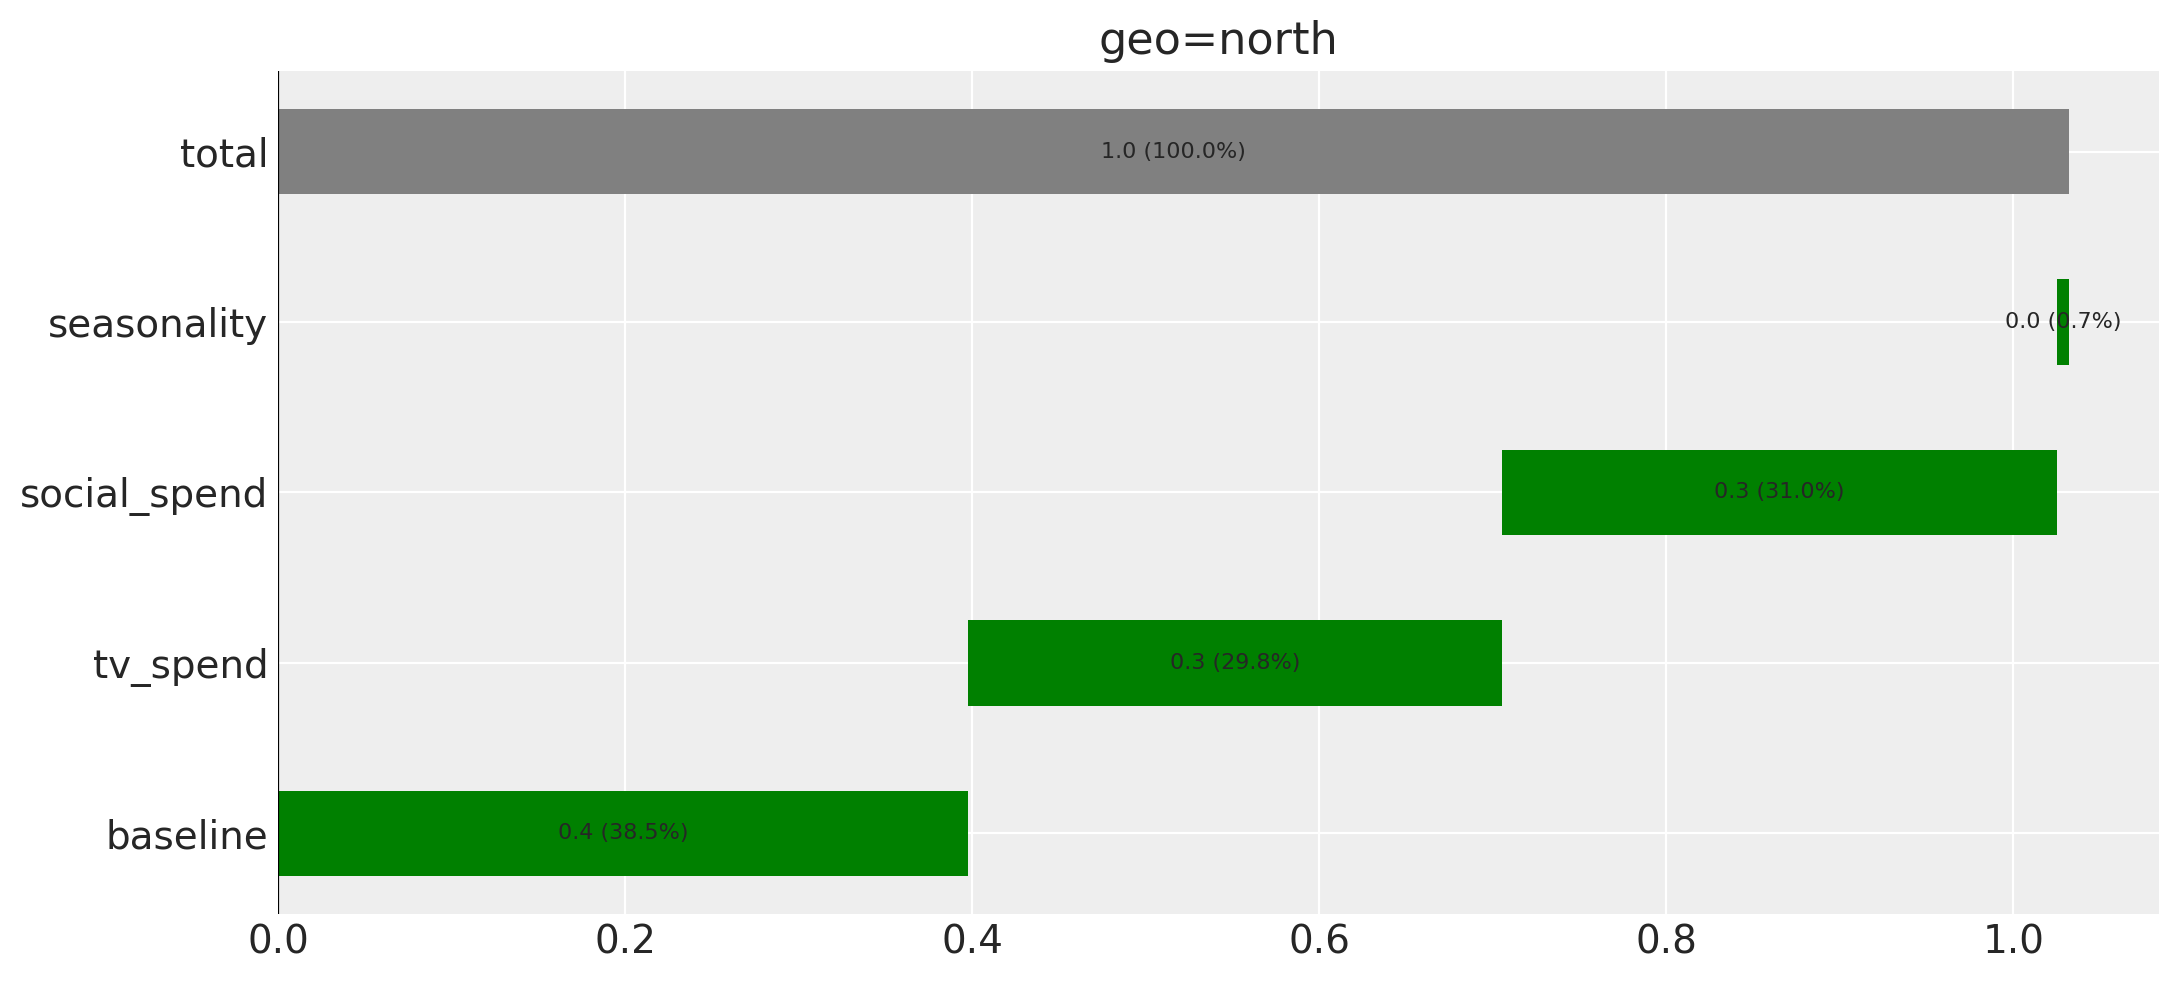

In [56]:
funnel.plot.decomposition.waterfall(dims={"geo": ["north"]}, figsize=(11, 5));

The `channels` bars are the **direct** paths only, and the mediated contribution is
not redistributed into the baseline either -- it is simply absent. The bars do not
add up to the target:

In [57]:
scale = funnel.idata.constant_data["target_scale"]
post = funnel.idata.posterior
components = {
    "intercept": post["intercept_contribution"] * scale,
    "channels (direct)": post["channel_contribution_original_scale"].sum("channel"),
    "seasonality": post["yearly_seasonality_contribution"] * scale,
}
waterfall_total = sum(float(da.sel(geo="north").mean()) for da in components.values())
mediated = float(
    post["funnel_effect_contribution_original_scale"].sel(geo="north").mean()
)
for name, da in components.items():
    print(f"{name:32s} {float(da.sel(geo='north').mean()):8.2f}")
print(f"{'sum of the waterfall bars':32s} {waterfall_total:8.2f}")
print(f"{'mediated, missing from the bars':32s} {mediated:8.2f}")
print(f"{'observed target mean':32s} {float(data['y'].sel(geo='north').mean()):8.2f}")

# How much of that mediated term is the channels' due? The joint indirect effect
# from the generative model -- north only, since every number above is north.
north = geos.index("north")
print(
    f"\n{'joint indirect effect (north)':32s} "
    f"{float(indirect_both[:, north].mean()):8.2f}"
)

# The rest of the mediated term, in the demand units M* is measured in: the four
# things that make up lower-funnel spend, only one of which media created.
mstar_parts = {
    "demand baseline": float(true["funnel_baseline"][north]),
    "category demand (gamma C)": float(
        true["funnel_gamma"][north] * category_demand[:, north].mean()
    ),
    "lf budget (lambda B)": float(
        true["funnel_lambda"][north] * lf_budget[:, north].mean()
    ),
}
mstar_mean = float(data["lf_spend_true"].sel(geo="north").mean())
mstar_parts["demand the channels created"] = mstar_mean - sum(mstar_parts.values())
print("\nmean structural lower-funnel spend M* (north), in demand units:")
for name, value in mstar_parts.items():
    print(f"{name:32s} {value:8.2f}   {value / mstar_mean:6.1%}")

intercept                            0.40
channels (direct)                    0.63
seasonality                          0.01
sum of the waterfall bars            1.03
mediated, missing from the bars      0.72
observed target mean                 1.75

joint indirect effect (north)        0.38

mean structural lower-funnel spend M* (north), in demand units:
demand baseline                      0.20    14.4%
category demand (gamma C)            0.19    14.0%
lf budget (lambda B)                 0.19    13.4%
demand the channels created          0.81    58.2%


More than forty percent of the target is unaccounted for. Be precise about
whose it is: the missing 0.72 is the *entire* mediated term, and lower-funnel
spend is built from **four** things -- the demand baseline, the category-demand
contribution $\gamma C$, the exogenous lower-funnel budget $\lambda B$, and the
demand the channels created. Only the last is media's due, and on the
generative model it is worth about 0.38 per week in `north` -- roughly half of
the missing mass, with the demand baseline, the category index and the budget
term splitting the rest (their shares of $M^{*}$ are printed above). A reader
taking these bars as an attribution would therefore be wrong twice over --
under-crediting both channels by their mediated contributions, and dropping the
demand baseline, the category index and the budget term altogether, which
between them are the other half of the missing mass.

This is a boundary to know rather than a bug to route around: the DAG lives in
your `create_effect` code, and only you can tell the library that a particular
additive term means "demand this channel created". Everything causal in this
notebook came from post-processing the posterior, not from a built-in.

## Caveats and extensions

- **The framework does not "see" the DAG.** The funnel structure lives in the
  `FunnelEffect` code. The built-in decomposition recognises a fixed set of
  components, and a custom `MuEffect` is not among them -- as the waterfall above
  shows, the mediated contribution is omitted from it entirely rather than
  reassigned. Anything causal has to come from post-processing, as it did here.
- **Pass a `Dataset`, not a `DataFrame`.** Extra columns in a DataFrame are
  dropped during conversion, so a `DataVarMuEffect` would not find its variables.
  Build the model from an `xarray.Dataset`; `fit` still takes the long frame for
  its bookkeeping.
- **Pooling choices are identification choices.** We pooled carryover and
  curvature across geos and left amplitudes free. Freeing everything per geo with
  ~130 weeks each will widen the posteriors considerably and can introduce
  divergences; hierarchical (partially pooled) priors are the natural next step.
- **Latent variables need an anchor.** Fixing at one the coefficient on $D$ in the
  lower-funnel spend equation is what gives $D$ a scale -- latent demand is
  expressed in units of the spend it induces. Leave that coefficient free as well
  as $\kappa$ and the model is unidentified. Which relationship you anchor to is a
  substantive choice, because it decides what "one unit of demand" means.
- **The two exclusion restrictions are not equally load-bearing.** The budget's
  ($B$ enters the spend equation but not the search equation) is genuinely
  identifying: it is what separates $\lambda B$ from $D$, it has a testable
  implication ($B \perp S$ on the raw data, which we verified both on the graph
  and empirically), and dropping it -- or giving the budget no independent
  variation -- merges $\lambda$ into the demand baseline. Category demand's
  ($C$ absent from the target equation) is a modelling convenience: $C$ is
  observed, so a $C \to Y$ path could be absorbed by adding it as a control
  column, exactly as `Naive B+` does.
- **Only one downstream variable is a cause.** Lower-funnel spend belongs in the
  target equation; branded search does not. Getting that backwards is not a
  modelling nicety, it is the difference between `Naive C` and the funnel model.
- **Graph verdicts are conditional on the graph, including the parts you almost
  did not draw.** The d-separation table split the market driver into three legs:
  a seasonal basis, a growth trend, and the drivers' shared noise. Only the first
  two are observed. That third leg is easy to leave out of a drawing -- it came
  from one `LKJCholeskyCov` line in the DGP -- and leaving it out certifies
  `Naive B++` as a valid total-effect estimator, which on the full graph it is
  not: a trend control blocks the fork it names and nothing else. A reader who
  believed the Fourier basis captured the *entire* driver would have gone
  further and scored `Naive B` as valid. On real data the analogous question --
  what is the market driver, which legs of it do your regressors span, and what
  is left over -- cannot be checked against a known truth, and a genuinely
  latent residue (taste shifts, competitor activity) puts even the trend fix out
  of reach. Controlling for a *measured* demand index helps exactly as far as
  the problem is confounding -- here it repaired the trend-confounded channel
  and did nothing for the bias that was never materially confounded. Making the
  index part of a correctly specified structural equation, as the funnel model
  does, is what addresses the rest.
- **The funnel model is handed the true functional form.** In this synthetic
  exercise the funnel model *is* the DGP: right response families, right
  pooling structure, right anchoring, right exclusion restrictions. That is
  the strongest possible version of the comparison, and it is also the point
  -- the notebook's thesis is that structure, not adjustment, is what
  separates the specifications, so the model given the correct structure
  should win, and by how much is worth knowing. On real data nobody hands you
  the functional form; the parameter-recovery and proxy-predictive checks
  above are the tools for arguing your structural equations are close enough,
  and misspecifying them would erode the funnel model's advantage exactly
  where the naive models lose theirs.
- **The funnel model's advantage mixes structure with information.** It observes
  two likelihood series and two inputs the naive models never see, so its
  narrower intervals are not attributable to structure alone. The clean way to
  separate the two is a specification that *sees* the extra series without
  *modelling* the system -- `Naive B++` with `lower_spend` and `search_volume`
  added as control columns -- which we leave as an exercise; note that
  conditioning on either one is conditioning on a descendant of the treatment,
  so it answers a different causal question, which is rather the point.
- **Distinguish a mediator from an organic path.** We route the entire mediated
  effect through lower-funnel spend. A model with *both* $M^{*} \to Y$ and a direct
  organic $D \to Y$ is more realistic still, but the two differ only by
  $\lambda B$ and would be weakly separated at this sample size -- a good reason to
  add such a path only with data (or priors) that can support it.
- **Per-channel indirect effects are not additive.** With a shared saturating
  mediator, leave-one-out attribution understates the joint effect -- here by about
  14%. Report the convention alongside the number; [Mediation Analysis and
  (In)Direct Effects with PyMC](https://juanitorduz.github.io/mediation/) works
  through the general decomposition, where the pieces that leave-one-out drops
  appear as explicit interaction and dependence terms.
- **Mind the scales.** The base `MMM` scales its channel and target data, but a
  `DataVarMuEffect` reads its variables **unscaled**. Here the data is generated
  in-model at roughly unit scale, so the `HalfNormal(1)` priors in the demand
  equation are sensible. On real data, scale those inputs (or the priors) yourself.
- **Budget optimization.** Funnel-aware optimization is out of scope, but not for
  the reason one might guess: `BudgetOptimizer` replaces `channel_data` with
  `do(...)`, a graph-level intervention that *does* propagate into a `MuEffect`
  subgraph. What stops it is the objective and the shapes. The default
  `response_variable="total_media_contribution_original_scale"` is built from
  `channel_contribution` alone, so the mediated term is not in the function being
  maximised; and the effect's own date-length `pm.Data` variables are not resized
  to the optimizer's `num_periods + l_max` window. Both would have to be
  addressed for the optimizer to price the funnel.

Natural extensions: hierarchical priors across geos, **censored** lower-funnel
spend for budget-capped channels, more than one latent demand pool (for example
separate branded and non-branded demand), and time-varying mediator baselines.

In [58]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Wed, 29 Jul 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
networkx      : 3.6.1
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

